In [ ]:
# EU AI governance text-mining artefact

## Purpose of the notebook

This Colab notebook develops an EU-focused NLP text-mining artefact for analysing selected European Union AI governance documents.

The artefact applies the same scoring logic, weighting rules and analytical parameters developed for the broader EU-US AI governance artefact, but the present notebook is restricted to the EU corpus.

The artefact maps EU AI governance documents across two main regulatory-orientation dimensions:

i) innovation versus safeguards;
ii) voluntary versus mandatory-binding orientation.

The notebook distinguishes between:

i) a core analytical corpus of sixteen EU documents; and
ii) two supplementary documents used only for document-level assessment.

The supplementary documents are included in individual document visualisations but excluded from aggregate corpus-level calculations, in order to avoid artificial distortion of the overall EU corpus scores.

SyntaxError: invalid character '–' (U+2013) (3586529586.py, line 7)

In [ ]:
# ============================================================
# Step 1: notebook setup
# EU AI governance text-mining artefact
# ============================================================

# Core libraries
import os
import re
import glob
import math
import zipfile
import warnings
from collections import Counter, defaultdict

# Data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt

# Optional but useful visualisation libraries
try:
    import seaborn as sns
except ImportError:
    sns = None

# File handling
from google.colab import files

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 120)

warnings.filterwarnings("ignore")

print("Step 1 completed: libraries imported and notebook setup ready.")

Step 1 completed: libraries imported and notebook setup ready.


In [ ]:
# ============================================================
# Step 2: create notebook folder structure
# EU-only AI governance artefact
# ============================================================

import os

# Main working folders
BASE_DIR = "/content/eu_ai_governance_artefact"
DATA_DIR = os.path.join(BASE_DIR, "data")
RAW_DIR = os.path.join(DATA_DIR, "raw_documents")
TEXT_DIR = os.path.join(DATA_DIR, "extracted_texts")
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")
FIGURES_DIR = os.path.join(OUTPUT_DIR, "figures")
TABLES_DIR = os.path.join(OUTPUT_DIR, "tables")

# Create folders
folders = [
    BASE_DIR,
    DATA_DIR,
    RAW_DIR,
    TEXT_DIR,
    OUTPUT_DIR,
    FIGURES_DIR,
    TABLES_DIR
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Step 2 completed: folder structure created.")
print(f"Base directory: {BASE_DIR}")
print(f"Raw documents folder: {RAW_DIR}")
print(f"Extracted texts folder: {TEXT_DIR}")
print(f"Figures folder: {FIGURES_DIR}")
print(f"Tables folder: {TABLES_DIR}")

Step 2 completed: folder structure created.
Base directory: /content/eu_ai_governance_artefact
Raw documents folder: /content/eu_ai_governance_artefact/data/raw_documents
Extracted texts folder: /content/eu_ai_governance_artefact/data/extracted_texts
Figures folder: /content/eu_ai_governance_artefact/outputs/figures
Tables folder: /content/eu_ai_governance_artefact/outputs/tables


In [ ]:
# ============================================================
# Step 3: verify uploaded documents
# ============================================================

import os
import pandas as pd

# List all files currently in the raw documents folder
uploaded_files = sorted(os.listdir(RAW_DIR))

print(f"Number of files found in raw documents folder: {len(uploaded_files)}")
print("\nFiles found:")

for file in uploaded_files:
    print("-", file)

# Create a simple file inventory table
df_uploaded_files = pd.DataFrame({
    "file_name": uploaded_files,
    "file_path": [os.path.join(RAW_DIR, f) for f in uploaded_files],
    "file_extension": [os.path.splitext(f)[1].lower() for f in uploaded_files]
})

display(df_uploaded_files)

Number of files found in raw documents folder: 0

Files found:


,file_name,file_path,file_extension


In [ ]:
# ============================================================
# Step 4: create provisional document metadata table
# ============================================================

# Create document IDs automatically from the uploaded file list
df_docs = df_uploaded_files.copy()

df_docs.insert(0, "doc_id", [f"EU_{i+1:02d}" for i in range(len(df_docs))])

# Create provisional short titles from filenames
df_docs["short_title"] = (
    df_docs["file_name"]
    .str.replace(".pdf", "", regex=False)
    .str.replace(".docx", "", regex=False)
    .str.replace(".txt", "", regex=False)
    .str.replace("_", " ")
    .str.replace("-", " ")
    .str.strip()
)

# Placeholder metadata to be refined manually
df_docs["year"] = ""
df_docs["document_type"] = ""
df_docs["corpus_group"] = "core_16"
df_docs["colour_group"] = "core"
df_docs["legal_force_category"] = ""

# Inclusion rules
df_docs["include_document_level"] = True
df_docs["include_aggregate_level"] = df_docs["corpus_group"].eq("core_16")

# Display table
display(df_docs)

# Save provisional metadata table
metadata_path = os.path.join(TABLES_DIR, "eu_document_metadata_provisional.csv")
df_docs.to_csv(metadata_path, index=False, encoding="utf-8-sig")

print("Step 4 completed: provisional document metadata table created.")
print(f"Metadata table saved to: {metadata_path}")

AttributeError: Can only use .str accessor with string values!

In [ ]:
# ============================================================
# Step 4A: print document order for metadata confirmation
# ============================================================

for _, row in df_docs[["doc_id", "file_name", "short_title"]].iterrows():
    print(f"{row['doc_id']} | {row['file_name']} | {row['short_title']}")

KeyError: "['short_title'] not in index"

In [ ]:
# ============================================================
# Step 5: final EU document metadata table
# ============================================================

# Metadata values based on the confirmed document order
metadata_updates = {
    "EU_01": {
        "short_title": "AI for Europe",
        "year": 2018,
        "document_type": "Communication",
        "corpus_group": "core_16",
        "colour_group": "core",
        "legal_force_category": "soft_policy"
    },
    "EU_02": {
        "short_title": "Coordinated Plan on AI 2018",
        "year": 2018,
        "document_type": "Coordinated plan",
        "corpus_group": "core_16",
        "colour_group": "core",
        "legal_force_category": "soft_policy"
    },
    "EU_03": {
        "short_title": "Ethics Guidelines for Trustworthy AI",
        "year": 2019,
        "document_type": "Guidelines",
        "corpus_group": "core_16",
        "colour_group": "core",
        "legal_force_category": "voluntary_guidance"
    },
    "EU_04": {
        "short_title": "White Paper on AI",
        "year": 2020,
        "document_type": "White paper",
        "corpus_group": "core_16",
        "colour_group": "core",
        "legal_force_category": "soft_policy"
    },
    "EU_05": {
        "short_title": "Fostering a European approach to AI",
        "year": 2021,
        "document_type": "Communication",
        "corpus_group": "core_16",
        "colour_group": "core",
        "legal_force_category": "soft_policy"
    },
    "EU_06": {
        "short_title": "Coordinated Plan on AI 2021 Review",
        "year": 2021,
        "document_type": "Coordinated plan",
        "corpus_group": "core_16",
        "colour_group": "core",
        "legal_force_category": "soft_policy"
    },
    "EU_07": {
        "short_title": "AI Act",
        "year": 2024,
        "document_type": "Regulation",
        "corpus_group": "core_16",
        "colour_group": "core",
        "legal_force_category": "binding_legislation"
    },
    "EU_08": {
        "short_title": "AI Pact",
        "year": 2024,
        "document_type": "Pact",
        "corpus_group": "core_16",
        "colour_group": "core",
        "legal_force_category": "voluntary_guidance"
    },
    "EU_09": {
        "short_title": "Apply AI Strategy",
        "year": 2025,
        "document_type": "Strategy",
        "corpus_group": "core_16",
        "colour_group": "core",
        "legal_force_category": "soft_policy"
    },
    "EU_10": {
        "short_title": "AI Continent Action Plan",
        "year": 2025,
        "document_type": "Action plan",
        "corpus_group": "core_16",
        "colour_group": "core",
        "legal_force_category": "soft_policy"
    },
    "EU_11": {
        "short_title": "Guidelines on prohibited AI practices",
        "year": 2025,
        "document_type": "Guidelines",
        "corpus_group": "core_16",
        "colour_group": "core",
        "legal_force_category": "interpretative_guidance"
    },
    "EU_12": {
        "short_title": "Digital Omnibus proposal",
        "year": 2025,
        "document_type": "Commission proposal",
        "corpus_group": "supplementary_2",
        "colour_group": "commission_proposal",
        "legal_force_category": "legislative_proposal"
    },
    "EU_13": {
        "short_title": "Code of Practice on AI-generated content",
        "year": 2025,
        "document_type": "Code of practice",
        "corpus_group": "core_16",
        "colour_group": "core",
        "legal_force_category": "voluntary_guidance"
    },
    "EU_14": {
        "short_title": "Guidelines on the definition of AI system",
        "year": 2025,
        "document_type": "Guidelines",
        "corpus_group": "core_16",
        "colour_group": "core",
        "legal_force_category": "interpretative_guidance"
    },
    "EU_15": {
        "short_title": "AI in Science Communication",
        "year": 2025,
        "document_type": "Communication",
        "corpus_group": "core_16",
        "colour_group": "core",
        "legal_force_category": "soft_policy"
    },
    "EU_16": {
        "short_title": "Guidelines on GPAI provider obligations",
        "year": 2025,
        "document_type": "Guidelines",
        "corpus_group": "core_16",
        "colour_group": "core",
        "legal_force_category": "interpretative_guidance"
    },
    "EU_17": {
        "short_title": "Council final draft Digital Omnibus",
        "year": 2026,
        "document_type": "Council draft",
        "corpus_group": "core_16",
        "colour_group": "core",
        "legal_force_category": "advanced_legislative_text"
    },
    "EU_18": {
        "short_title": "Unofficial consolidated Digital Omnibus text",
        "year": 2026,
        "document_type": "Unofficial consolidation",
        "corpus_group": "supplementary_2",
        "colour_group": "unofficial_consolidation",
        "legal_force_category": "unofficial_consolidation"
    }
}

# Apply metadata updates to df_docs
for doc_id, updates in metadata_updates.items():
    for column, value in updates.items():
        df_docs.loc[df_docs["doc_id"] == doc_id, column] = value

# Recalculate inclusion flags
df_docs["include_document_level"] = True
df_docs["include_aggregate_level"] = df_docs["corpus_group"].eq("core_16")

# Colour mapping for later plots
colour_map = {
    "core": "tab:blue",
    "commission_proposal": "tab:orange",
    "unofficial_consolidation": "tab:red"
}

df_docs["plot_colour"] = df_docs["colour_group"].map(colour_map)

# Save final metadata table
metadata_final_path = os.path.join(TABLES_DIR, "eu_document_metadata_final.csv")
df_docs.to_csv(metadata_final_path, index=False, encoding="utf-8-sig")

# Display final table
display(df_docs[[
    "doc_id",
    "short_title",
    "year",
    "document_type",
    "corpus_group",
    "include_document_level",
    "include_aggregate_level",
    "colour_group",
    "legal_force_category",
    "file_name"
]])

print("Step 5 completed: final EU document metadata table created.")
print(f"Total documents: {len(df_docs)}")
print(f"Documents used for document-level graphs: {df_docs['include_document_level'].sum()}")
print(f"Documents used for aggregate-level graphs: {df_docs['include_aggregate_level'].sum()}")
print(f"Supplementary documents excluded from aggregate-level graphs: {(~df_docs['include_aggregate_level']).sum()}")
print(f"Final metadata table saved to: {metadata_final_path}")

,doc_id,short_title,year,document_type,corpus_group,include_document_level,include_aggregate_level,colour_group,legal_force_category,file_name
0,EU_01,AI for Europe,2018,Communication,core_16,True,True,core,soft_policy,eu_01_2018_ai_for_europe.pdf
1,EU_02,Coordinated Plan on AI 2018,2018,Coordinated plan,core_16,True,True,core,soft_policy,eu_02_2018_coordinated_plan_ai.pdf
2,EU_03,Ethics Guidelines for Trustworthy AI,2019,Guidelines,core_16,True,True,core,voluntary_guidance,eu_03_2019_ethics_guidelines_trustworthy_ai.pdf
3,EU_04,White Paper on AI,2020,White paper,core_16,True,True,core,soft_policy,eu_04_2020_white_paper_ai.pdf
4,EU_05,Fostering a European approach to AI,2021,Communication,core_16,True,True,core,soft_policy,eu_05_2021_fostering_european_approach_ai_communication.pdf
5,EU_06,Coordinated Plan on AI 2021 Review,2021,Coordinated plan,core_16,True,True,core,soft_policy,eu_06_2021_coordinated_plan_ai_review.pdf
6,EU_07,AI Act,2024,Regulation,core_16,True,True,core,binding_legislation,eu_07_2024_ai_act.pdf
7,EU_08,AI Pact,2024,Pact,core_16,True,True,core,voluntary_guidance,eu_08_2024_ai_pact.pdf
8,EU_09,Apply AI Strategy,2025,Strategy,core_16,True,True,core,soft_policy,eu_09_2025_apply_ai_strategy.pdf
9,EU_10,AI Continent Action Plan,2025,Action plan,core_16,True,True,core,soft_policy,eu_10_2025_ai_continent_action_plan.pdf


Step 5 completed: final EU document metadata table created.
Total documents: 18
Documents used for document-level graphs: 18
Documents used for aggregate-level graphs: 16
Supplementary documents excluded from aggregate-level graphs: 2
Final metadata table saved to: /content/eu_ai_governance_artefact/outputs/tables/eu_document_metadata_final.csv


In [ ]:
# ============================================================
# Step 5A: add legal-force weights from the previous artefact
# ============================================================

# Previous artefact weighting logic:
# 1.5 = binding regulation / assumed adopted binding legislation
# 0.8 = policy communication / strategy / coordinated plan / white paper
# 0.7 = guidelines / soft-law interpretative material
# 0.6 = voluntary commitment / pact / code of practice

previous_artefact_weights = {
    "EU_01": 0.8,
    "EU_02": 0.8,
    "EU_03": 0.7,
    "EU_04": 0.8,
    "EU_05": 0.8,
    "EU_06": 0.8,
    "EU_07": 1.5,
    "EU_08": 0.6,
    "EU_09": 0.8,
    "EU_10": 0.8,
    "EU_11": 0.7,
    "EU_12": 1.5,
    "EU_13": 0.6,
    "EU_14": 0.7,
    "EU_15": 0.8,
    "EU_16": 0.7,
    "EU_17": 1.5,
    "EU_18": 1.5
}

df_docs["legal_force_weight"] = df_docs["doc_id"].map(previous_artefact_weights)

# Safety check: no document should have a missing weight
missing_weights = df_docs[df_docs["legal_force_weight"].isna()]

if len(missing_weights) > 0:
    print("Warning: some documents do not have a legal-force weight.")
    display(missing_weights[["doc_id", "file_name", "short_title"]])
else:
    print("Step 5A completed: previous artefact weights added successfully.")

# Display key metadata for verification
display(df_docs[[
    "doc_id",
    "short_title",
    "document_type",
    "corpus_group",
    "include_aggregate_level",
    "legal_force_weight"
]])

# Save updated metadata
metadata_weighted_path = os.path.join(TABLES_DIR, "eu_document_metadata_with_weights.csv")
df_docs.to_csv(metadata_weighted_path, index=False, encoding="utf-8-sig")

print(f"Weighted metadata table saved to: {metadata_weighted_path}")

Step 5A completed: previous artefact weights added successfully.


,doc_id,short_title,document_type,corpus_group,include_aggregate_level,legal_force_weight
0,EU_01,AI for Europe,Communication,core_16,True,0.8
1,EU_02,Coordinated Plan on AI 2018,Coordinated plan,core_16,True,0.8
2,EU_03,Ethics Guidelines for Trustworthy AI,Guidelines,core_16,True,0.7
3,EU_04,White Paper on AI,White paper,core_16,True,0.8
4,EU_05,Fostering a European approach to AI,Communication,core_16,True,0.8
5,EU_06,Coordinated Plan on AI 2021 Review,Coordinated plan,core_16,True,0.8
6,EU_07,AI Act,Regulation,core_16,True,1.5
7,EU_08,AI Pact,Pact,core_16,True,0.6
8,EU_09,Apply AI Strategy,Strategy,core_16,True,0.8
9,EU_10,AI Continent Action Plan,Action plan,core_16,True,0.8


Weighted metadata table saved to: /content/eu_ai_governance_artefact/outputs/tables/eu_document_metadata_with_weights.csv


In [ ]:
# ============================================================
# Step 6A: install PDF text extraction library
# ============================================================

!pip install pymupdf -q

print("Step 6A completed: PyMuPDF installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.7/25.7 MB 14.0 MB/s eta 0:00:00
Step 6A completed: PyMuPDF installed.


In [ ]:
# ============================================================
# Step 6B: extract text from uploaded PDF documents
# ============================================================

import fitz  # PyMuPDF
import os
import re

def clean_extracted_text(text):
    """
    Light cleaning of extracted PDF text.
    This does not perform NLP preprocessing yet.
    It only removes excessive spacing and page artefacts.
    """
    if text is None:
        return ""

    text = text.replace("\x00", " ")
    text = re.sub(r"\s+", " ", text)
    text = text.strip()

    return text


def extract_text_from_pdf(pdf_path):
    """
    Extract text from a PDF using PyMuPDF.
    """
    extracted_pages = []

    try:
        doc = fitz.open(pdf_path)

        for page_number, page in enumerate(doc, start=1):
            page_text = page.get_text("text")
            page_text = clean_extracted_text(page_text)

            if page_text:
                extracted_pages.append(page_text)

        doc.close()

        return "\n\n".join(extracted_pages)

    except Exception as e:
        print(f"Error extracting text from {pdf_path}: {e}")
        return ""


# Extract text for each document
extracted_texts = []
word_counts = []
text_file_paths = []

for _, row in df_docs.iterrows():
    file_path = row["file_path"]
    doc_id = row["doc_id"]

    if not os.path.exists(file_path):
        print(f"File not found for {doc_id}: {file_path}")
        text = ""
    elif row["file_extension"].lower() == ".pdf":
        text = extract_text_from_pdf(file_path)
    elif row["file_extension"].lower() == ".txt":
        with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
            text = f.read()
        text = clean_extracted_text(text)
    else:
        print(f"Unsupported file type for {doc_id}: {row['file_extension']}")
        text = ""

    # Save extracted text
    text_filename = f"{doc_id}_extracted_text.txt"
    text_path = os.path.join(TEXT_DIR, text_filename)

    with open(text_path, "w", encoding="utf-8") as f:
        f.write(text)

    # Store results
    extracted_texts.append(text)
    word_counts.append(len(text.split()))
    text_file_paths.append(text_path)

# Add extraction outputs to metadata table
df_docs["extracted_text"] = extracted_texts
df_docs["word_count"] = word_counts
df_docs["extracted_text_path"] = text_file_paths

# Save updated metadata table
metadata_extracted_path = os.path.join(TABLES_DIR, "eu_document_metadata_with_extracted_text.csv")
df_docs.drop(columns=["extracted_text"]).to_csv(metadata_extracted_path, index=False, encoding="utf-8-sig")

# Display extraction summary
display(df_docs[[
    "doc_id",
    "short_title",
    "file_name",
    "word_count",
    "corpus_group",
    "legal_force_weight"
]])

print("Step 6B completed: text extraction finished.")
print(f"Metadata without full text saved to: {metadata_extracted_path}")
print(f"Extracted text files saved in: {TEXT_DIR}")

,doc_id,short_title,file_name,word_count,corpus_group,legal_force_weight
0,EU_01,AI for Europe,eu_01_2018_ai_for_europe.pdf,9261,core_16,0.8
1,EU_02,Coordinated Plan on AI 2018,eu_02_2018_coordinated_plan_ai.pdf,4305,core_16,0.8
2,EU_03,Ethics Guidelines for Trustworthy AI,eu_03_2019_ethics_guidelines_trustworthy_ai.pdf,22974,core_16,0.7
3,EU_04,White Paper on AI,eu_04_2020_white_paper_ai.pdf,14020,core_16,0.8
4,EU_05,Fostering a European approach to AI,eu_05_2021_fostering_european_approach_ai_communication.pdf,4254,core_16,0.8
5,EU_06,Coordinated Plan on AI 2021 Review,eu_06_2021_coordinated_plan_ai_review.pdf,34224,core_16,0.8
6,EU_07,AI Act,eu_07_2024_ai_act.pdf,91421,core_16,1.5
7,EU_08,AI Pact,eu_08_2024_ai_pact.pdf,1108,core_16,0.6
8,EU_09,Apply AI Strategy,eu_09_2025_apply_ai_strategy.pdf,9920,core_16,0.8
9,EU_10,AI Continent Action Plan,eu_10_2025_ai_continent_action_plan.pdf,10399,core_16,0.8


Step 6B completed: text extraction finished.
Metadata without full text saved to: /content/eu_ai_governance_artefact/outputs/tables/eu_document_metadata_with_extracted_text.csv
Extracted text files saved in: /content/eu_ai_governance_artefact/data/extracted_texts


In [ ]:
# ============================================================
# Step 6C: extraction quality check
# ============================================================

# Basic extraction diagnostics
df_extraction_check = df_docs[[
    "doc_id",
    "short_title",
    "file_name",
    "word_count",
    "corpus_group",
    "include_aggregate_level"
]].copy()

# Flag possible extraction problems
df_extraction_check["extraction_status"] = np.where(
    df_extraction_check["word_count"] == 0,
    "problem: no text extracted",
    np.where(
        df_extraction_check["word_count"] < 500,
        "check: very short text",
        "ok"
    )
)

display(df_extraction_check)

print("Extraction quality summary:")
print(df_extraction_check["extraction_status"].value_counts())

,doc_id,short_title,file_name,word_count,corpus_group,include_aggregate_level,extraction_status
0,EU_01,AI for Europe,eu_01_2018_ai_for_europe.pdf,9261,core_16,True,ok
1,EU_02,Coordinated Plan on AI 2018,eu_02_2018_coordinated_plan_ai.pdf,4305,core_16,True,ok
2,EU_03,Ethics Guidelines for Trustworthy AI,eu_03_2019_ethics_guidelines_trustworthy_ai.pdf,22974,core_16,True,ok
3,EU_04,White Paper on AI,eu_04_2020_white_paper_ai.pdf,14020,core_16,True,ok
4,EU_05,Fostering a European approach to AI,eu_05_2021_fostering_european_approach_ai_communication.pdf,4254,core_16,True,ok
5,EU_06,Coordinated Plan on AI 2021 Review,eu_06_2021_coordinated_plan_ai_review.pdf,34224,core_16,True,ok
6,EU_07,AI Act,eu_07_2024_ai_act.pdf,91421,core_16,True,ok
7,EU_08,AI Pact,eu_08_2024_ai_pact.pdf,1108,core_16,True,ok
8,EU_09,Apply AI Strategy,eu_09_2025_apply_ai_strategy.pdf,9920,core_16,True,ok
9,EU_10,AI Continent Action Plan,eu_10_2025_ai_continent_action_plan.pdf,10399,core_16,True,ok


Extraction quality summary:
extraction_status
ok    18
Name: count, dtype: int64


In [ ]:
# ============================================================
# Step 7A – Load spaCy for tokenisation and lemmatisation
# Based on the original v1.3 artefact model
# ============================================================

!pip install spacy -q
!python -m spacy download en_core_web_sm -q

import spacy
import re
from collections import Counter

nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

print("Step 7A completed: spaCy loaded successfully.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 107.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Step 7A completed: spaCy loaded successfully.


In [ ]:
# ============================================================
# Step 7B – Tokenisation, lemmatisation and customised stop-word removal
# Reproduced from the original v1.3 artefact model
# ============================================================

generic_ai_terms = {
    "ai",
    "artificial",
    "intelligence",
    "artificial intelligence",
    "system",
    "systems",
    "model",
    "models",
    "technology",
    "technologies",
    "algorithm",
    "algorithms"
}

legal_signal_terms = {
    "shall",
    "must",
    "may",
    "should",
    "could",
    "required",
    "require",
    "requires",
    "requirement",
    "requirements"
}

noise_terms = {
    # EU / institutional artefacts
    "en", "com", "swd", "final", "european", "commission",
    "parliament", "council", "committee", "region", "brussels",
    "eu", "eur", "europe", "member", "state", "states",

    # US / Federal Register artefacts retained from original artefact model
    "secretary", "agency", "order", "section", "subsection",
    "director", "day", "date", "united", "government",
    "wednesday", "november", "october", "federal", "register",
    "vol", "document", "documents", "oct", "jkt", "po", "verdate",

    # numbering and structural markers
    "ii", "iii", "iv", "paragraph", "paragraphs",
    "page", "pages", "annex", "annexes",
    "article", "articles", "art",
    "recital", "recitals",
    "chapter", "chapters",
    "title", "titles",
    "point", "points",
    "subparagraph", "subparagraphs",
    "p", "pp",

    # generic low-value processing words
    "include", "relate", "appropriate", "use"
}


def preprocess_text(text):
    doc = nlp(text)
    processed_tokens = []

    for token in doc:
        lemma = token.lemma_.lower().strip()

        # Remove punctuation, spaces and numbers
        if token.is_punct or token.is_space or token.like_num:
            continue

        # Remove very short tokens
        if len(lemma) < 2:
            continue

        # Remove generic AI terms
        if lemma in generic_ai_terms:
            continue

        # Remove corpus-specific noise terms
        if lemma in noise_terms:
            continue

        # Remove technical artefacts
        if lemma.startswith("com(") or lemma.startswith("swd("):
            continue

        if "<" in lemma or ">" in lemma:
            continue

        if re.match(r"^\d{1,2}:\d{2}$", lemma):
            continue

        # Remove stop words, except legally meaningful modal words
        if token.is_stop and lemma not in legal_signal_terms:
            continue

        # Normalise spaCy lemma for data
        if lemma == "datum":
            lemma = "data"

        processed_tokens.append(lemma)

    return processed_tokens


print("Step 7B completed: original v1.3 preprocessing function loaded successfully.")

Step 7B completed: original v1.3 preprocessing function loaded successfully.


In [ ]:
# ============================================================
# Step 7C – v1.3 analytical vocabularies
# Reproduced from the original v1.3 artefact model
# ============================================================

# ------------------------------------------------------------
# 7.1 Rights- and citizen-oriented safeguards vocabulary
# ------------------------------------------------------------

rights_citizen_safeguards_terms = {
    "right", "rights",
    "privacy",
    "consumer",
    "protection",
    "protect",
    "discrimination",
    "bias",
    "fairness",
    "equity",
    "equal",
    "equality",
    "confidentiality",
    "anonymisation",
    "anonymization",
    "human",

    "trustworthy",
    "responsible",
    "reliable",
    "reliability",
    "robust",
    "robustness",
    "transparent",
    "transparency",
    "accountable",
    "accountability",
    "explainable",
    "explainability",
    "oversight",
    "supervision",
    "monitoring",
    "audit",
    "auditing",
    "assessment",
    "evaluation",
    "certification",
    "conformity",
    "compliance",
    "liability",
    "integrity",
    "safety",
    "safe",
    "harm",
    "risk"
}

rights_citizen_safeguards_phrases = {
    "fundamental rights",
    "human rights",
    "civil rights",
    "data protection",
    "personal data",
    "consumer protection",
    "privacy protection",
    "non-discrimination",
    "algorithmic discrimination",
    "algorithmic bias",
    "human oversight",
    "human control",
    "human agency",
    "fundamental rights impact assessment",
    "affected persons",
    "natural persons",
    "rights and freedoms",

    "trustworthy ai",
    "responsible ai",
    "risk management",
    "risk assessment",
    "risk mitigation",
    "risk-based approach",
    "high risk",
    "high-risk",
    "systemic risk",
    "conformity assessment",
    "impact assessment",
    "bias mitigation",
    "societal harms",
    "public safety",
    "transparency obligations",
    "accountability mechanisms",
    "risk management framework",
    "safe and secure",
    "safe, secure"
}


# ------------------------------------------------------------
# 7.2 Innovation vocabulary
# ------------------------------------------------------------

innovation_terms = {
    "innovation",
    "innovative",
    "innovate",
    "deployment",
    "deploy",
    "adoption",
    "uptake",
    "experimentation",
    "experiment",
    "sandbox",
    "prototype",
    "piloting",
    "pilot",
    "scale",
    "scaling",

    "competitiveness",
    "competitive",
    "competition",
    "growth",
    "investment",
    "invest",
    "entrepreneurship",
    "business",
    "industry",
    "industrial",
    "commercial",
    "productivity",
    "productive",
    "prosperity",
    "economic",
    "economy",

    "research",
    "science",
    "scientific",
    "skill",
    "skills",
    "education",
    "talent",
    "digital",
    "transformation",
    "modernisation",
    "modernization",

    "leadership",
    "advance",
    "advancement",
    "value",
    "efficiency",
    "excellence",
    "ecosystem"
}

innovation_phrases = {
    "market uptake",
    "digital transformation",
    "economic growth",
    "technological leadership",
    "innovation leadership",
    "industrial strategy",
    "industrial competitiveness",
    "value creation",
    "research and innovation",
    "business opportunities",
    "competitive advantage",
    "innovation ecosystem",
    "skills development",
    "talent development",
    "workforce development",
    "public sector innovation",
    "private sector innovation",
    "regulatory sandbox",
    "regulatory sandboxes",
    "testing environment",
    "real-world testing",
    "technology transfer",
    "scientific progress",
    "economic opportunity",
    "market development",
    "investment in ai",
    "digital economy",
    "productivity growth",
    "innovation capacity",
    "global leadership"
}


# ------------------------------------------------------------
# 7.3 Mandatory/control vocabulary
# ------------------------------------------------------------
# v1.3 logic:
# - no word-level weights;
# - broad legal-context terms excluded:
#   law, regulation, rule, rules, authority, authorities;
# - implementation/control terms retained:
#   monitoring, supervision, supervise, market surveillance,
#   ensure, ensures, ensuring, liability.
# ------------------------------------------------------------

mandatory_terms = {
    "shall",
    "must",
    "obliged",
    "obligation",
    "obligations",
    "mandatory",
    "binding",

    "required",
    "require",
    "requires",
    "requirement",
    "requirements",

    "prohibit",
    "prohibited",
    "prohibition",
    "ban",
    "banned",

    "comply",
    "compliance",
    "enforce",
    "enforcement",

    "penalty",
    "penalties",
    "sanction",
    "sanctions",
    "fine",
    "fines",

    "monitoring",
    "supervision",
    "supervise",
    "liability",
    "ensure",
    "ensures",
    "ensuring"
}

mandatory_phrases = {
    "legal obligation",
    "legal obligations",
    "binding obligation",
    "binding obligations",
    "binding requirement",
    "binding requirements",
    "mandatory requirement",
    "mandatory requirements",

    "shall ensure",
    "shall develop",
    "shall submit",
    "shall establish",
    "shall provide",
    "shall require",
    "shall implement",
    "shall take",

    "must comply",
    "required to",

    "compliance with",
    "enforcement action",
    "subject to",
    "in accordance with",
    "pursuant to",
    "regulatory requirement",
    "regulatory requirements",

    "market surveillance",
    "administrative fine",
    "administrative fines"
}


# ------------------------------------------------------------
# 7.4 Voluntary / soft-law vocabulary
# ------------------------------------------------------------

voluntary_terms = {
    "may",
    "should",
    "could",

    "encourage",
    "encourages",
    "encouraged",

    "recommend",
    "recommends",
    "recommendation",
    "recommendations",

    "guidance",
    "guideline",
    "guidelines",

    "framework",
    "frameworks",

    "principle",
    "principles",

    "practice",
    "practices",

    "voluntary",
    "optional",

    "support",
    "supports",
    "promote",
    "promotes",
    "facilitate",
    "facilitates",
    "enable",
    "enables",
    "foster",
    "fosters",

    "cooperation",
    "collaboration",
    "coordination",
    "partnership",

    "consultation",
    "stakeholder",
    "stakeholders"
}

voluntary_phrases = {
    "best practice",
    "best practices",

    "voluntary commitment",
    "voluntary commitments",
    "voluntary framework",

    "non mandatory",
    "non-mandatory",
    "not mandatory",

    "non binding",
    "non-binding",
    "not binding",

    "not required",
    "no obligation",
    "without obligation",

    "guidance document",
    "guidance documents",

    "code of conduct",
    "codes of conduct",

    "soft law",

    "should consider",
    "may include",
    "may consider",

    "encourage the",
    "encourages the",

    "public consultation",
    "stakeholder engagement",
    "stakeholder consultation",

    "public-private partnership",
    "international cooperation",
    "technical guidance",
    "voluntary guidelines",
    "common framework",
    "risk management framework"
}

print("Step 7C completed: original v1.3 analytical vocabularies loaded successfully.")
print("Rights/citizen terms:", len(rights_citizen_safeguards_terms))
print("Rights/citizen phrases:", len(rights_citizen_safeguards_phrases))
print("Innovation terms:", len(innovation_terms))
print("Innovation phrases:", len(innovation_phrases))
print("Mandatory terms:", len(mandatory_terms))
print("Mandatory phrases:", len(mandatory_phrases))
print("Voluntary terms:", len(voluntary_terms))
print("Voluntary phrases:", len(voluntary_phrases))

Step 7C completed: original v1.3 analytical vocabularies loaded successfully.
Rights/citizen terms: 44
Rights/citizen phrases: 36
Innovation terms: 49
Innovation phrases: 30
Mandatory terms: 34
Mandatory phrases: 28
Voluntary terms: 38
Voluntary phrases: 33


In [ ]:
# ============================================================
# Step 7D – Counting, phrase-priority and scoring functions
# Reproduced from the original v1.3 artefact model
# ============================================================

def count_phrases_in_text(clean_text, phrase_set):
    total = 0
    phrase_counts = {}

    for phrase in phrase_set:
        pattern = r"\b" + re.escape(phrase) + r"\b"
        count = len(re.findall(pattern, clean_text))

        if count > 0:
            phrase_counts[phrase] = count
            total += count

    return total, phrase_counts


def phrase_to_components(phrase):
    phrase = phrase.replace("-", " ")
    doc = nlp(phrase)
    components = []

    for token in doc:
        lemma = token.lemma_.lower().strip()

        if token.is_punct or token.is_space:
            continue

        if lemma in {"and", "or", "the", "of", "to", "in", "with"}:
            continue

        if lemma == "datum":
            lemma = "data"

        components.append(lemma)

    return components


def remove_phrase_components_from_tokens(tokens, phrase_details):
    tokens_copy = tokens.copy()

    for phrase, count in phrase_details.items():
        components = phrase_to_components(phrase)

        for _ in range(count):
            for word in components:
                if word in tokens_copy:
                    tokens_copy.remove(word)

    return tokens_copy


def count_terms(tokens, dictionary):
    counter = Counter(tokens)
    total = 0

    for term in dictionary:
        if " " not in term:
            total += counter[term]

    return total


def compute_axis_score(positive_count, negative_count):
    denominator = positive_count + negative_count

    if denominator == 0:
        return 0

    return ((positive_count - negative_count) / denominator) * 100


def compute_adjusted_y_score(mandatory_count, voluntary_count, legal_force_multiplier):
    adjusted_mandatory = mandatory_count * legal_force_multiplier
    denominator = adjusted_mandatory + voluntary_count

    if denominator == 0:
        return 0

    return ((adjusted_mandatory - voluntary_count) / denominator) * 100


print("Step 7D completed: original v1.3 counting and scoring functions loaded successfully.")

Step 7D completed: original v1.3 counting and scoring functions loaded successfully.


In [ ]:
# ============================================================
# Step 7E – Main document-analysis function for v1.3
# Reproduced from the original v1.3 artefact model
# ============================================================

def analyse_document_v1_3(tokens, clean_text, legal_force_multiplier=1.0):
    # 1. Count multi-word expressions first
    rights_phrase, rights_phrase_details = count_phrases_in_text(
        clean_text,
        rights_citizen_safeguards_phrases
    )

    innovation_phrase, innovation_phrase_details = count_phrases_in_text(
        clean_text,
        innovation_phrases
    )

    mandatory_phrase, mandatory_phrase_details = count_phrases_in_text(
        clean_text,
        mandatory_phrases
    )

    voluntary_phrase, voluntary_phrase_details = count_phrases_in_text(
        clean_text,
        voluntary_phrases
    )

    # 2. Remove phrase components to reduce double-counting
    all_phrase_details = {}
    for phrase_dict in [
        rights_phrase_details,
        innovation_phrase_details,
        mandatory_phrase_details,
        voluntary_phrase_details
    ]:
        all_phrase_details.update(phrase_dict)

    tokens_without_phrase_components = remove_phrase_components_from_tokens(
        tokens,
        all_phrase_details
    )

    # 3. Count single-word terms
    rights_single = count_terms(
        tokens_without_phrase_components,
        rights_citizen_safeguards_terms
    )

    innovation_single = count_terms(
        tokens_without_phrase_components,
        innovation_terms
    )

    mandatory_single = count_terms(
        tokens_without_phrase_components,
        mandatory_terms
    )

    voluntary_single = count_terms(
        tokens_without_phrase_components,
        voluntary_terms
    )

    # 4. Combine phrase and single-word counts
    rights_total = rights_single + rights_phrase
    innovation_total = innovation_single + innovation_phrase
    mandatory_total = mandatory_single + mandatory_phrase
    voluntary_total = voluntary_single + voluntary_phrase

    # 5. Compute X and Y scores
    x_score = compute_axis_score(
        positive_count=innovation_total,
        negative_count=rights_total
    )

    y_score_adjusted = compute_adjusted_y_score(
        mandatory_count=mandatory_total,
        voluntary_count=voluntary_total,
        legal_force_multiplier=legal_force_multiplier
    )

    # 6. Relative frequencies per 1,000 tokens
    if len(tokens) == 0:
        rights_per_1000 = 0
        innovation_per_1000 = 0
        mandatory_per_1000 = 0
        voluntary_per_1000 = 0
    else:
        rights_per_1000 = round((rights_total / len(tokens)) * 1000, 2)
        innovation_per_1000 = round((innovation_total / len(tokens)) * 1000, 2)
        mandatory_per_1000 = round((mandatory_total / len(tokens)) * 1000, 2)
        voluntary_per_1000 = round((voluntary_total / len(tokens)) * 1000, 2)

    return {
        "total_tokens": len(tokens),

        "rights_citizen_safeguards_single": rights_single,
        "rights_citizen_safeguards_phrases": rights_phrase,
        "rights_citizen_safeguards_total": rights_total,

        "innovation_single": innovation_single,
        "innovation_phrases": innovation_phrase,
        "innovation_total": innovation_total,

        "mandatory_single": mandatory_single,
        "mandatory_phrases": mandatory_phrase,
        "mandatory_total": mandatory_total,

        "voluntary_single": voluntary_single,
        "voluntary_phrases": voluntary_phrase,
        "voluntary_total": voluntary_total,

        "rights_citizen_safeguards_per_1000": rights_per_1000,
        "innovation_per_1000": innovation_per_1000,
        "mandatory_per_1000": mandatory_per_1000,
        "voluntary_per_1000": voluntary_per_1000,

        "x_score": round(x_score, 2),
        "y_score_adjusted": round(y_score_adjusted, 2),

        "rights_phrase_details": rights_phrase_details,
        "innovation_phrase_details": innovation_phrase_details,
        "mandatory_phrase_details": mandatory_phrase_details,
        "voluntary_phrase_details": voluntary_phrase_details
    }


print("Step 7E completed: original v1.3 document-analysis function loaded successfully.")

Step 7E completed: original v1.3 document-analysis function loaded successfully.


In [ ]:
# ============================================================
# Step 8 – Run v1.3 analysis on the EU-only corpus
# Based on the original v1.3 artefact model
# ============================================================

final_rows = []

for _, doc_info in df_docs.iterrows():
    print(f"Processing: {doc_info['doc_id']} - {doc_info['short_title']}")

    clean = doc_info["extracted_text"]
    tokens = preprocess_text(clean)

    result = analyse_document_v1_3(
        tokens,
        clean,
        legal_force_multiplier=doc_info["legal_force_weight"]
    )

    row = {
        "document_id": doc_info["doc_id"],
        "document": doc_info["short_title"],
        "file_name": doc_info["file_name"],
        "document_type": doc_info["document_type"],
        "year": doc_info["year"],
        "corpus_group": doc_info["corpus_group"],
        "colour_group": doc_info["colour_group"],
        "include_document_level": doc_info["include_document_level"],
        "include_aggregate_level": doc_info["include_aggregate_level"],
        "legal_force_multiplier": doc_info["legal_force_weight"],
        "plot_colour": doc_info["plot_colour"],
        **result
    }

    final_rows.append(row)

final_results_df = pd.DataFrame(final_rows)

# Save full results table
final_results_path = os.path.join(TABLES_DIR, "eu_only_v1_3_full_results.csv")
final_results_df.to_csv(final_results_path, index=False, encoding="utf-8-sig")

# Display main analytical results
display(final_results_df[
    [
        "document_id",
        "document",
        "document_type",
        "corpus_group",
        "include_aggregate_level",
        "legal_force_multiplier",
        "total_tokens",
        "rights_citizen_safeguards_total",
        "innovation_total",
        "mandatory_total",
        "voluntary_total",
        "rights_citizen_safeguards_per_1000",
        "innovation_per_1000",
        "mandatory_per_1000",
        "voluntary_per_1000",
        "x_score",
        "y_score_adjusted"
    ]
])

print("Step 8 completed: EU-only v1.3 analysis finished.")
print(f"Full results saved to: {final_results_path}")
print(f"Documents analysed: {len(final_results_df)}")
print(f"Core documents for aggregate-level graphs: {final_results_df['include_aggregate_level'].sum()}")
print(f"Supplementary documents for document-level graphs only: {(~final_results_df['include_aggregate_level']).sum()}")

Processing: EU_01 - AI for Europe
Processing: EU_02 - Coordinated Plan on AI 2018
Processing: EU_03 - Ethics Guidelines for Trustworthy AI
Processing: EU_04 - White Paper on AI
Processing: EU_05 - Fostering a European approach to AI
Processing: EU_06 - Coordinated Plan on AI 2021 Review
Processing: EU_07 - AI Act
Processing: EU_08 - AI Pact
Processing: EU_09 - Apply AI Strategy
Processing: EU_10 - AI Continent Action Plan
Processing: EU_11 - Guidelines on prohibited AI practices
Processing: EU_12 - Digital Omnibus proposal
Processing: EU_13 - Code of Practice on AI-generated content
Processing: EU_14 - Guidelines on the definition of AI system
Processing: EU_15 - AI in Science Communication
Processing: EU_16 - Guidelines on GPAI provider obligations
Processing: EU_17 - Council final draft Digital Omnibus
Processing: EU_18 - Unofficial consolidated Digital Omnibus text


,document_id,document,document_type,corpus_group,include_aggregate_level,legal_force_multiplier,total_tokens,rights_citizen_safeguards_total,innovation_total,mandatory_total,voluntary_total,rights_citizen_safeguards_per_1000,innovation_per_1000,mandatory_per_1000,voluntary_per_1000,x_score,y_score_adjusted
0,EU_01,AI for Europe,Communication,core_16,True,0.8,4346,145,374,56,201,33.36,86.06,12.89,46.25,44.12,-63.55
1,EU_02,Coordinated Plan on AI 2018,Coordinated plan,core_16,True,0.8,2006,41,141,29,89,20.44,70.29,14.46,44.37,54.95,-58.65
2,EU_03,Ethics Guidelines for Trustworthy AI,Guidelines,core_16,True,0.7,11048,879,237,326,586,79.56,21.45,29.51,53.04,-57.53,-43.94
3,EU_04,White Paper on AI,White paper,core_16,True,0.8,6842,467,270,237,340,68.25,39.46,34.64,49.69,-26.73,-28.40
4,EU_05,Fostering a European approach to AI,Communication,core_16,True,0.8,1995,100,120,44,88,50.13,60.15,22.06,44.11,9.09,-42.86
5,EU_06,Coordinated Plan on AI 2021 Review,Coordinated plan,core_16,True,0.8,16730,340,1134,152,792,20.32,67.78,9.09,47.34,53.87,-73.38
6,EU_07,AI Act,Regulation,core_16,True,1.5,40588,2407,499,2762,1428,59.30,12.29,68.05,35.18,-65.66,48.73
7,EU_08,AI Pact,Pact,core_16,True,0.6,521,24,7,14,17,46.07,13.44,26.87,32.63,-54.84,-33.86
8,EU_09,Apply AI Strategy,Strategy,core_16,True,0.8,5095,75,319,53,221,14.72,62.61,10.40,43.38,61.93,-67.81
9,EU_10,AI Continent Action Plan,Action plan,core_16,True,0.8,5264,63,466,77,192,11.97,88.53,14.63,36.47,76.18,-51.42


Step 8 completed: EU-only v1.3 analysis finished.
Full results saved to: /content/eu_ai_governance_artefact/outputs/tables/eu_only_v1_3_full_results.csv
Documents analysed: 18
Core documents for aggregate-level graphs: 16
Supplementary documents for document-level graphs only: 2


In [ ]:
# ============================================================
# Step 9 – Summary table and quadrant classification
# EU-only v1.3 artefact
# ============================================================

def classify_quadrant(x_score, y_score):
    """
    Classify each document into one of the four regulatory-orientation quadrants.

    X-axis:
    - negative = rights/citizen safeguards orientation
    - positive = innovation orientation

    Y-axis:
    - negative = voluntary / soft-law orientation
    - positive = mandatory-binding / control orientation
    """

    if x_score >= 0 and y_score >= 0:
        return "Innovation + mandatory-binding"
    elif x_score < 0 and y_score >= 0:
        return "Safeguards + mandatory-binding"
    elif x_score < 0 and y_score < 0:
        return "Safeguards + voluntary"
    else:
        return "Innovation + voluntary"


# Create a clean summary table
summary_df = final_results_df.copy()

summary_df["quadrant"] = summary_df.apply(
    lambda row: classify_quadrant(row["x_score"], row["y_score_adjusted"]),
    axis=1
)

# Add readable axis interpretation
summary_df["x_axis_orientation"] = summary_df["x_score"].apply(
    lambda x: "Innovation-oriented" if x >= 0 else "Rights/citizen safeguards-oriented"
)

summary_df["y_axis_orientation"] = summary_df["y_score_adjusted"].apply(
    lambda y: "Mandatory-binding/control-oriented" if y >= 0 else "Voluntary/soft-law-oriented"
)

# Select columns for a readable summary table
summary_columns = [
    "document_id",
    "document",
    "year",
    "document_type",
    "corpus_group",
    "include_aggregate_level",
    "legal_force_multiplier",
    "total_tokens",
    "rights_citizen_safeguards_total",
    "innovation_total",
    "mandatory_total",
    "voluntary_total",
    "rights_citizen_safeguards_per_1000",
    "innovation_per_1000",
    "mandatory_per_1000",
    "voluntary_per_1000",
    "x_score",
    "y_score_adjusted",
    "x_axis_orientation",
    "y_axis_orientation",
    "quadrant"
]

summary_df = summary_df[summary_columns]

# Save summary table
summary_path = os.path.join(TABLES_DIR, "eu_only_v1_3_summary_with_quadrants.csv")
summary_df.to_csv(summary_path, index=False, encoding="utf-8-sig")

# Display summary table
display(summary_df)

print("Step 9 completed: summary table and quadrant classification created.")
print(f"Summary table saved to: {summary_path}")

print("\nDocument-level quadrant distribution, using all 18 documents:")
display(summary_df["quadrant"].value_counts().reset_index().rename(
    columns={"index": "quadrant", "quadrant": "document_count"}
))

print("\nAggregate-level quadrant distribution, using core 16 documents only:")
core_16_summary_df = summary_df[summary_df["include_aggregate_level"] == True].copy()

display(core_16_summary_df["quadrant"].value_counts().reset_index().rename(
    columns={"index": "quadrant", "quadrant": "document_count"}
))

,document_id,document,year,document_type,corpus_group,include_aggregate_level,legal_force_multiplier,total_tokens,rights_citizen_safeguards_total,innovation_total,mandatory_total,voluntary_total,rights_citizen_safeguards_per_1000,innovation_per_1000,mandatory_per_1000,voluntary_per_1000,x_score,y_score_adjusted,x_axis_orientation,y_axis_orientation,quadrant
0,EU_01,AI for Europe,2018,Communication,core_16,True,0.8,4346,145,374,56,201,33.36,86.06,12.89,46.25,44.12,-63.55,Innovation-oriented,Voluntary/soft-law-oriented,Innovation + voluntary
1,EU_02,Coordinated Plan on AI 2018,2018,Coordinated plan,core_16,True,0.8,2006,41,141,29,89,20.44,70.29,14.46,44.37,54.95,-58.65,Innovation-oriented,Voluntary/soft-law-oriented,Innovation + voluntary
2,EU_03,Ethics Guidelines for Trustworthy AI,2019,Guidelines,core_16,True,0.7,11048,879,237,326,586,79.56,21.45,29.51,53.04,-57.53,-43.94,Rights/citizen safeguards-oriented,Voluntary/soft-law-oriented,Safeguards + voluntary
3,EU_04,White Paper on AI,2020,White paper,core_16,True,0.8,6842,467,270,237,340,68.25,39.46,34.64,49.69,-26.73,-28.40,Rights/citizen safeguards-oriented,Voluntary/soft-law-oriented,Safeguards + voluntary
4,EU_05,Fostering a European approach to AI,2021,Communication,core_16,True,0.8,1995,100,120,44,88,50.13,60.15,22.06,44.11,9.09,-42.86,Innovation-oriented,Voluntary/soft-law-oriented,Innovation + voluntary
5,EU_06,Coordinated Plan on AI 2021 Review,2021,Coordinated plan,core_16,True,0.8,16730,340,1134,152,792,20.32,67.78,9.09,47.34,53.87,-73.38,Innovation-oriented,Voluntary/soft-law-oriented,Innovation + voluntary
6,EU_07,AI Act,2024,Regulation,core_16,True,1.5,40588,2407,499,2762,1428,59.30,12.29,68.05,35.18,-65.66,48.73,Rights/citizen safeguards-oriented,Mandatory-binding/control-oriented,Safeguards + mandatory-binding
7,EU_08,AI Pact,2024,Pact,core_16,True,0.6,521,24,7,14,17,46.07,13.44,26.87,32.63,-54.84,-33.86,Rights/citizen safeguards-oriented,Voluntary/soft-law-oriented,Safeguards + voluntary
8,EU_09,Apply AI Strategy,2025,Strategy,core_16,True,0.8,5095,75,319,53,221,14.72,62.61,10.40,43.38,61.93,-67.81,Innovation-oriented,Voluntary/soft-law-oriented,Innovation + voluntary
9,EU_10,AI Continent Action Plan,2025,Action plan,core_16,True,0.8,5264,63,466,77,192,11.97,88.53,14.63,36.47,76.18,-51.42,Innovation-oriented,Voluntary/soft-law-oriented,Innovation + voluntary


Step 9 completed: summary table and quadrant classification created.
Summary table saved to: /content/eu_ai_governance_artefact/outputs/tables/eu_only_v1_3_summary_with_quadrants.csv

Document-level quadrant distribution, using all 18 documents:


,document_count,count
0,Innovation + voluntary,7
1,Safeguards + voluntary,6
2,Safeguards + mandatory-binding,5



Aggregate-level quadrant distribution, using core 16 documents only:


,document_count,count
0,Innovation + voluntary,7
1,Safeguards + voluntary,6
2,Safeguards + mandatory-binding,3


In [ ]:
# ============================================================
# Step 10 – EU-only regulatory spectrum graph
# Based strictly on the original v1.3 artefact graph logic
# Uses all 18 documents for individual document-level assessment
# ============================================================

import plotly.express as px
import os

# ------------------------------------------------------------
# 10.1 Prepare data for the regulatory spectrum graph
# ------------------------------------------------------------

# The regulatory spectrum is a document-level graph.
# Therefore, all 18 documents are included:
# - core 16 EU documents
# - EU_12 Commission Digital Omnibus proposal
# - EU_18 unofficial consolidated version

spectrum_df = final_results_df.copy()

# Recreate the graph grouping logic.
# This affects only visual colour distinction.
# It does not affect scoring, weighting or corpus inclusion rules.
spectrum_df["plot_group"] = spectrum_df["colour_group"].map({
    "core": "EU",
    "commission_proposal": "EU supplementary - Commission proposal",
    "unofficial_consolidation": "EU supplementary - unofficial consolidation"
})

# Safety fallback in case any document has a missing colour group
spectrum_df["plot_group"] = spectrum_df["plot_group"].fillna("EU")


# ------------------------------------------------------------
# 10.2 Create Plotly regulatory spectrum graph
# ------------------------------------------------------------

fig_full = px.scatter(
    spectrum_df,
    x="x_score",
    y="y_score_adjusted",

    # Colour distinguishes core and supplementary documents
    color="plot_group",

    # Shape distinguishes document types, as in the original artefact
    symbol="document_type",

    # Labels shown on the graph
    text="document_id",

    # Information displayed when hovering over each point
    hover_data=[
        "document",
        "document_type",
        "year",
        "legal_force_multiplier",
        "rights_citizen_safeguards_per_1000",
        "innovation_per_1000",
        "mandatory_per_1000",
        "voluntary_per_1000",
        "corpus_group",
        "include_aggregate_level"
    ],

    title="EU Corpus v1.3: Rights- and Citizen-Oriented Safeguards versus Innovation",

    labels={
        "x_score": "Rights- and citizen-oriented safeguards (-100) ↔ Innovation (+100)",
        "y_score_adjusted": "Voluntary (-100) ↔ Mandatory (+100)",
        "plot_group": "Document group",
        "document_type": "Document type"
    },

    # Colour rule agreed for this EU-only version
    color_discrete_map={
        "EU": "blue",
        "EU supplementary - Commission proposal": "green",
        "EU supplementary - unofficial consolidation": "orange"
    }
)


# ------------------------------------------------------------
# 10.3 Add quadrant axes and quadrant labels
# ------------------------------------------------------------

# Central dashed axes
fig_full.add_vline(x=0, line_dash="dash")
fig_full.add_hline(y=0, line_dash="dash")

# Quadrant labels, following the original artefact logic
fig_full.add_annotation(
    x=-65,
    y=75,
    text="Mandatory rights/citizen safeguards",
    showarrow=False
)

fig_full.add_annotation(
    x=65,
    y=75,
    text="Mandatory innovation",
    showarrow=False
)

fig_full.add_annotation(
    x=-65,
    y=-75,
    text="Voluntary rights/citizen safeguards",
    showarrow=False
)

fig_full.add_annotation(
    x=65,
    y=-75,
    text="Voluntary innovation",
    showarrow=False
)


# ------------------------------------------------------------
# 10.4 Layout and display settings
# ------------------------------------------------------------

fig_full.update_traces(
    textposition="top center"
)

fig_full.update_layout(
    xaxis=dict(range=[-100, 100]),
    yaxis=dict(range=[-100, 100]),
    width=1350,
    height=900
)


# ------------------------------------------------------------
# 10.5 Save graph outputs
# ------------------------------------------------------------

spectrum_html_path = os.path.join(
    FIGURES_DIR,
    "figure_01_eu_regulatory_spectrum_all_18.html"
)

fig_full.write_html(spectrum_html_path)

# Optional PNG export.
# If PNG export fails, the interactive HTML is still saved correctly.
try:
    spectrum_png_path = os.path.join(
        FIGURES_DIR,
        "figure_01_eu_regulatory_spectrum_all_18.png"
    )
    fig_full.write_image(spectrum_png_path, scale=2)
    print(f"PNG saved to: {spectrum_png_path}")

except Exception as e:
    print("PNG export skipped. Interactive HTML was saved successfully.")
    print("If you need PNG export, run: !pip install -U kaleido")
    print(e)


# ------------------------------------------------------------
# 10.6 Show graph
# ------------------------------------------------------------

fig_full.show()

print("Step 10 completed: EU-only regulatory spectrum graph created using the original v1.3 graph logic.")
print(f"Interactive HTML saved to: {spectrum_html_path}")

PNG export skipped. Interactive HTML was saved successfully.
If you need PNG export, run: !pip install -U kaleido

Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



Step 10 completed: EU-only regulatory spectrum graph created using the original v1.3 graph logic.
Interactive HTML saved to: /content/eu_ai_governance_artefact/outputs/figures/figure_01_eu_regulatory_spectrum_all_18.html


In [ ]:
# ============================================================
# Step 11 – Four-component vocabulary profile
# EU-only v1.3 artefact
# Uses all 18 documents for individual document-level assessment
# Based on the original artefact graph logic
# ============================================================

import plotly.express as px
import os

# ------------------------------------------------------------
# 11.1 Prepare four-component profile table
# ------------------------------------------------------------

four_component_full = final_results_df[
    [
        "document_id",
        "document",
        "document_type",
        "year",
        "corpus_group",
        "colour_group",
        "include_aggregate_level",
        "rights_citizen_safeguards_per_1000",
        "innovation_per_1000",
        "mandatory_per_1000",
        "voluntary_per_1000"
    ]
].copy()

# Recreate original-style jurisdiction and plot_group columns
# This is for visual and hover consistency only.
# It does not affect scoring or weighting.
four_component_full["jurisdiction"] = "EU"

four_component_full["plot_group"] = four_component_full["colour_group"].map({
    "core": "EU",
    "commission_proposal": "EU supplementary - Commission proposal",
    "unofficial_consolidation": "EU supplementary - unofficial consolidation"
})

four_component_full["plot_group"] = four_component_full["plot_group"].fillna("EU")


# ------------------------------------------------------------
# 11.2 Convert to long format for grouped bar chart
# ------------------------------------------------------------

four_component_long_full = four_component_full.melt(
    id_vars=[
        "document_id",
        "document",
        "jurisdiction",
        "plot_group",
        "document_type",
        "year",
        "corpus_group",
        "include_aggregate_level"
    ],
    value_vars=[
        "rights_citizen_safeguards_per_1000",
        "innovation_per_1000",
        "mandatory_per_1000",
        "voluntary_per_1000"
    ],
    var_name="component",
    value_name="frequency_per_1000_tokens"
)

component_labels = {
    "rights_citizen_safeguards_per_1000": "Rights/citizen safeguards",
    "innovation_per_1000": "Innovation",
    "mandatory_per_1000": "Mandatory/control",
    "voluntary_per_1000": "Voluntary/soft-law"
}

four_component_long_full["component"] = four_component_long_full["component"].map(component_labels)


# ------------------------------------------------------------
# 11.3 Save four-component table
# ------------------------------------------------------------

four_component_table_path = os.path.join(
    TABLES_DIR,
    "eu_only_v1_3_four_component_profile_all_18.csv"
)

four_component_long_full.to_csv(
    four_component_table_path,
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# 11.4 Create grouped bar chart
# ------------------------------------------------------------

fig_components_full = px.bar(
    four_component_long_full,
    x="document_id",
    y="frequency_per_1000_tokens",
    color="component",
    barmode="group",
    hover_data=[
        "document",
        "jurisdiction",
        "plot_group",
        "document_type",
        "year",
        "corpus_group",
        "include_aggregate_level"
    ],
    title="EU Corpus v1.3: Four-Component Vocabulary Profile",
    labels={
        "document_id": "Document ID",
        "frequency_per_1000_tokens": "Detected terms per 1,000 tokens",
        "component": "Analytical component"
    }
)

fig_components_full.update_layout(
    width=1500,
    height=750,
    xaxis=dict(tickangle=0)
)


# ------------------------------------------------------------
# 11.5 Save graph outputs
# ------------------------------------------------------------

four_component_html_path = os.path.join(
    FIGURES_DIR,
    "figure_02_four_component_vocabulary_profile_all_18.html"
)

fig_components_full.write_html(four_component_html_path)

try:
    four_component_png_path = os.path.join(
        FIGURES_DIR,
        "figure_02_four_component_vocabulary_profile_all_18.png"
    )
    fig_components_full.write_image(four_component_png_path, scale=2)
    print(f"PNG saved to: {four_component_png_path}")

except Exception as e:
    print("PNG export skipped. Interactive HTML was saved successfully.")
    print("If you need PNG export, run: !pip install -U kaleido")
    print(e)


# ------------------------------------------------------------
# 11.6 Show graph
# ------------------------------------------------------------

fig_components_full.show()

print("Step 11 completed: four-component vocabulary profile created for all 18 documents.")
print(f"Table saved to: {four_component_table_path}")
print(f"Interactive HTML saved to: {four_component_html_path}")

PNG export skipped. Interactive HTML was saved successfully.
If you need PNG export, run: !pip install -U kaleido

Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



Step 11 completed: four-component vocabulary profile created for all 18 documents.
Table saved to: /content/eu_ai_governance_artefact/outputs/tables/eu_only_v1_3_four_component_profile_all_18.csv
Interactive HTML saved to: /content/eu_ai_governance_artefact/outputs/figures/figure_02_four_component_vocabulary_profile_all_18.html


In [ ]:
# ============================================================
# Step 12 – Analytical vocabulary frequency table v1.3
# EU-only artefact
# Uses all 18 documents for individual document-level assessment
# Based on the original artefact logic
# ============================================================

import re
from collections import Counter
import pandas as pd
import os

analytical_rows = []

# ------------------------------------------------------------
# 12.1 Build term-level frequency table for each document
# ------------------------------------------------------------

for _, doc_info in df_docs.iterrows():

    print(f"Building vocabulary table for: {doc_info['doc_id']} - {doc_info['short_title']}")

    # Use the already extracted text from Step 6B
    # This avoids re-extracting the PDFs and keeps the notebook consistent.
    clean = doc_info["extracted_text"]

    # Apply the original v1.3 preprocessing function
    tokens = preprocess_text(clean)
    total_tokens = len(tokens)

    token_counter = Counter(tokens)

    # Recreate original-style metadata fields
    if doc_info["colour_group"] == "core":
        plot_group = "EU"
    elif doc_info["colour_group"] == "commission_proposal":
        plot_group = "EU supplementary - Commission proposal"
    elif doc_info["colour_group"] == "unofficial_consolidation":
        plot_group = "EU supplementary - unofficial consolidation"
    else:
        plot_group = "EU"

    base_info = {
        "document_id": doc_info["doc_id"],
        "document": doc_info["short_title"],
        "jurisdiction": "EU",
        "plot_group": plot_group,
        "document_type": doc_info["document_type"],
        "year": doc_info["year"],
        "corpus_group": doc_info["corpus_group"],
        "include_aggregate_level": doc_info["include_aggregate_level"],
        "legal_force_multiplier": doc_info["legal_force_weight"],
        "total_tokens": total_tokens
    }

    # Avoid division by zero in case of extraction problems
    if total_tokens == 0:
        continue

    # --------------------------------------------------------
    # Rights/citizen safeguards: single words
    # --------------------------------------------------------

    for term in rights_citizen_safeguards_terms:
        count = token_counter[term]

        if count > 0:
            analytical_rows.append({
                **base_info,
                "category": "rights_citizen_safeguards",
                "term": term,
                "term_type": "single_word",
                "absolute_frequency": count,
                "frequency_per_1000": round((count / total_tokens) * 1000, 3)
            })

    # --------------------------------------------------------
    # Rights/citizen safeguards: phrases
    # --------------------------------------------------------

    for phrase in rights_citizen_safeguards_phrases:
        pattern = r"\b" + re.escape(phrase) + r"\b"
        count = len(re.findall(pattern, clean))

        if count > 0:
            analytical_rows.append({
                **base_info,
                "category": "rights_citizen_safeguards",
                "term": phrase,
                "term_type": "multi_word_expression",
                "absolute_frequency": count,
                "frequency_per_1000": round((count / total_tokens) * 1000, 3)
            })

    # --------------------------------------------------------
    # Innovation: single words
    # --------------------------------------------------------

    for term in innovation_terms:
        count = token_counter[term]

        if count > 0:
            analytical_rows.append({
                **base_info,
                "category": "innovation",
                "term": term,
                "term_type": "single_word",
                "absolute_frequency": count,
                "frequency_per_1000": round((count / total_tokens) * 1000, 3)
            })

    # --------------------------------------------------------
    # Innovation: phrases
    # --------------------------------------------------------

    for phrase in innovation_phrases:
        pattern = r"\b" + re.escape(phrase) + r"\b"
        count = len(re.findall(pattern, clean))

        if count > 0:
            analytical_rows.append({
                **base_info,
                "category": "innovation",
                "term": phrase,
                "term_type": "multi_word_expression",
                "absolute_frequency": count,
                "frequency_per_1000": round((count / total_tokens) * 1000, 3)
            })

    # --------------------------------------------------------
    # Mandatory/control: single words
    # --------------------------------------------------------

    for term in mandatory_terms:
        count = token_counter[term]

        if count > 0:
            analytical_rows.append({
                **base_info,
                "category": "mandatory_control",
                "term": term,
                "term_type": "single_word",
                "absolute_frequency": count,
                "frequency_per_1000": round((count / total_tokens) * 1000, 3)
            })

    # --------------------------------------------------------
    # Mandatory/control: phrases
    # --------------------------------------------------------

    for phrase in mandatory_phrases:
        pattern = r"\b" + re.escape(phrase) + r"\b"
        count = len(re.findall(pattern, clean))

        if count > 0:
            analytical_rows.append({
                **base_info,
                "category": "mandatory_control",
                "term": phrase,
                "term_type": "multi_word_expression",
                "absolute_frequency": count,
                "frequency_per_1000": round((count / total_tokens) * 1000, 3)
            })

    # --------------------------------------------------------
    # Voluntary/soft-law: single words
    # --------------------------------------------------------

    for term in voluntary_terms:
        count = token_counter[term]

        if count > 0:
            analytical_rows.append({
                **base_info,
                "category": "voluntary_soft_law",
                "term": term,
                "term_type": "single_word",
                "absolute_frequency": count,
                "frequency_per_1000": round((count / total_tokens) * 1000, 3)
            })

    # --------------------------------------------------------
    # Voluntary/soft-law: phrases
    # --------------------------------------------------------

    for phrase in voluntary_phrases:
        pattern = r"\b" + re.escape(phrase) + r"\b"
        count = len(re.findall(pattern, clean))

        if count > 0:
            analytical_rows.append({
                **base_info,
                "category": "voluntary_soft_law",
                "term": phrase,
                "term_type": "multi_word_expression",
                "absolute_frequency": count,
                "frequency_per_1000": round((count / total_tokens) * 1000, 3)
            })


# ------------------------------------------------------------
# 12.2 Create, sort and save analytical vocabulary table
# ------------------------------------------------------------

analytical_vocabulary_df = pd.DataFrame(analytical_rows)

analytical_vocabulary_df = analytical_vocabulary_df.sort_values(
    by=["document_id", "category", "absolute_frequency"],
    ascending=[True, True, False]
)

analytical_vocabulary_path = os.path.join(
    TABLES_DIR,
    "eu_only_v1_3_analytical_vocabulary_frequency_table_all_18.csv"
)

analytical_vocabulary_df.to_csv(
    analytical_vocabulary_path,
    index=False,
    encoding="utf-8-sig"
)

display(analytical_vocabulary_df.head(30))

print("Step 12 completed: analytical vocabulary frequency table created for all 18 documents.")
print(f"Rows in analytical vocabulary table: {len(analytical_vocabulary_df)}")
print(f"Table saved to: {analytical_vocabulary_path}")

Building vocabulary table for: EU_01 - AI for Europe
Building vocabulary table for: EU_02 - Coordinated Plan on AI 2018
Building vocabulary table for: EU_03 - Ethics Guidelines for Trustworthy AI
Building vocabulary table for: EU_04 - White Paper on AI
Building vocabulary table for: EU_05 - Fostering a European approach to AI
Building vocabulary table for: EU_06 - Coordinated Plan on AI 2021 Review
Building vocabulary table for: EU_07 - AI Act
Building vocabulary table for: EU_08 - AI Pact
Building vocabulary table for: EU_09 - Apply AI Strategy
Building vocabulary table for: EU_10 - AI Continent Action Plan
Building vocabulary table for: EU_11 - Guidelines on prohibited AI practices
Building vocabulary table for: EU_12 - Digital Omnibus proposal
Building vocabulary table for: EU_13 - Code of Practice on AI-generated content
Building vocabulary table for: EU_14 - Guidelines on the definition of AI system
Building vocabulary table for: EU_15 - AI in Science Communication
Building vocabu

,document_id,document,jurisdiction,plot_group,document_type,year,corpus_group,include_aggregate_level,legal_force_multiplier,total_tokens,category,term,term_type,absolute_frequency,frequency_per_1000
60,EU_01,AI for Europe,EU,EU,Communication,2018,core_16,True,0.8,4346,innovation,research,single_word,45,10.354
68,EU_01,AI for Europe,EU,EU,Communication,2018,core_16,True,0.8,4346,innovation,investment,single_word,43,9.894
46,EU_01,AI for Europe,EU,EU,Communication,2018,core_16,True,0.8,4346,innovation,digital,single_word,35,8.053
35,EU_01,AI for Europe,EU,EU,Communication,2018,core_16,True,0.8,4346,innovation,innovation,single_word,31,7.133
33,EU_01,AI for Europe,EU,EU,Communication,2018,core_16,True,0.8,4346,innovation,business,single_word,22,5.062
55,EU_01,AI for Europe,EU,EU,Communication,2018,core_16,True,0.8,4346,innovation,industrial,single_word,18,4.142
66,EU_01,AI for Europe,EU,EU,Communication,2018,core_16,True,0.8,4346,innovation,skill,single_word,17,3.912
50,EU_01,AI for Europe,EU,EU,Communication,2018,core_16,True,0.8,4346,innovation,value,single_word,16,3.682
38,EU_01,AI for Europe,EU,EU,Communication,2018,core_16,True,0.8,4346,innovation,economic,single_word,14,3.221
52,EU_01,AI for Europe,EU,EU,Communication,2018,core_16,True,0.8,4346,innovation,education,single_word,12,2.761


Step 12 completed: analytical vocabulary frequency table created for all 18 documents.
Rows in analytical vocabulary table: 2128
Table saved to: /content/eu_ai_governance_artefact/outputs/tables/eu_only_v1_3_analytical_vocabulary_frequency_table_all_18.csv


In [ ]:
# ============================================================
# Step 12B – Top 20 analytical terms per document and category
# EU-only v1.3 artefact
# Uses all 18 documents for individual document-level assessment
# Based on the original artefact logic
# ============================================================

import os

top20_analytical_vocabulary_df = (
    analytical_vocabulary_df
    .groupby(["document_id", "category"], group_keys=False)
    .head(20)
    .reset_index(drop=True)
)

# Save table
top20_analytical_vocabulary_path = os.path.join(
    TABLES_DIR,
    "eu_only_v1_3_top20_analytical_terms_by_document_and_category_all_18.csv"
)

top20_analytical_vocabulary_df.to_csv(
    top20_analytical_vocabulary_path,
    index=False,
    encoding="utf-8-sig"
)

# Display key columns
display(
    top20_analytical_vocabulary_df[
        [
            "document_id",
            "document",
            "category",
            "term",
            "term_type",
            "absolute_frequency",
            "frequency_per_1000"
        ]
    ]
)

print("Step 12B completed: top 20 analytical terms per document and category created.")
print(f"Rows in top-20 table: {len(top20_analytical_vocabulary_df)}")
print(f"Table saved to: {top20_analytical_vocabulary_path}")

,document_id,document,category,term,term_type,absolute_frequency,frequency_per_1000
0,EU_01,AI for Europe,innovation,research,single_word,45,10.354
1,EU_01,AI for Europe,innovation,investment,single_word,43,9.894
2,EU_01,AI for Europe,innovation,digital,single_word,35,8.053
3,EU_01,AI for Europe,innovation,innovation,single_word,31,7.133
4,EU_01,AI for Europe,innovation,business,single_word,22,5.062
...,...,...,...,...,...,...,...
1312,EU_18,Unofficial consolidated Digital Omnibus text,voluntary_soft_law,recommendation,single_word,19,0.422
1313,EU_18,Unofficial consolidated Digital Omnibus text,voluntary_soft_law,guideline,single_word,19,0.422
1314,EU_18,Unofficial consolidated Digital Omnibus text,voluntary_soft_law,coordination,single_word,13,0.289
1315,EU_18,Unofficial consolidated Digital Omnibus text,voluntary_soft_law,consultation,single_word,11,0.244


Step 12B completed: top 20 analytical terms per document and category created.
Rows in top-20 table: 1317
Table saved to: /content/eu_ai_governance_artefact/outputs/tables/eu_only_v1_3_top20_analytical_terms_by_document_and_category_all_18.csv


In [ ]:
# ============================================================
# Step 13 – Heatmap of documents and four components
# EU-only v1.3 artefact
# Uses all 18 documents for individual document-level assessment
# ============================================================

import plotly.express as px
import os

# ------------------------------------------------------------
# 13.1 Prepare heatmap data
# ------------------------------------------------------------

heatmap_df = final_results_df[
    [
        "document_id",
        "document",
        "document_type",
        "year",
        "corpus_group",
        "colour_group",
        "include_aggregate_level",
        "rights_citizen_safeguards_per_1000",
        "innovation_per_1000",
        "mandatory_per_1000",
        "voluntary_per_1000"
    ]
].copy()

# Create a readable document label for the y-axis
heatmap_df["document_label"] = heatmap_df["document_id"] + " — " + heatmap_df["document"]

# Keep the order of documents as in the corpus
heatmap_df["document_label"] = pd.Categorical(
    heatmap_df["document_label"],
    categories=heatmap_df["document_label"].tolist(),
    ordered=True
)

# Rename columns for display
heatmap_components = {
    "rights_citizen_safeguards_per_1000": "Rights/citizen safeguards",
    "innovation_per_1000": "Innovation",
    "mandatory_per_1000": "Mandatory/control",
    "voluntary_per_1000": "Voluntary/soft-law"
}

heatmap_matrix = heatmap_df[
    [
        "document_label",
        "rights_citizen_safeguards_per_1000",
        "innovation_per_1000",
        "mandatory_per_1000",
        "voluntary_per_1000"
    ]
].copy()

heatmap_matrix = heatmap_matrix.rename(columns=heatmap_components)

heatmap_matrix = heatmap_matrix.set_index("document_label")


# ------------------------------------------------------------
# 13.2 Save heatmap table
# ------------------------------------------------------------

heatmap_table_path = os.path.join(
    TABLES_DIR,
    "eu_only_v1_3_heatmap_four_components_all_18.csv"
)

heatmap_matrix.to_csv(
    heatmap_table_path,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# 13.3 Create heatmap
# ------------------------------------------------------------

fig_heatmap = px.imshow(
    heatmap_matrix,
    text_auto=".1f",
    aspect="auto",
    color_continuous_scale="RdYlGn",
    title="EU Corpus v1.3: Heatmap of Four Analytical Components",
    labels={
        "x": "Analytical component",
        "y": "Document",
        "color": "Terms per 1,000 tokens"
    }
)

fig_heatmap.update_layout(
    width=1300,
    height=850,
    xaxis_title="Analytical component",
    yaxis_title="EU document"
)


# ------------------------------------------------------------
# 13.4 Save graph outputs
# ------------------------------------------------------------

heatmap_html_path = os.path.join(
    FIGURES_DIR,
    "figure_03_heatmap_four_components_all_18.html"
)

fig_heatmap.write_html(heatmap_html_path)

try:
    heatmap_png_path = os.path.join(
        FIGURES_DIR,
        "figure_03_heatmap_four_components_all_18.png"
    )
    fig_heatmap.write_image(heatmap_png_path, scale=2)
    print(f"PNG saved to: {heatmap_png_path}")

except Exception as e:
    print("PNG export skipped. Interactive HTML was saved successfully.")
    print("If you need PNG export, run: !pip install -U kaleido")
    print(e)


# ------------------------------------------------------------
# 13.5 Show graph
# ------------------------------------------------------------

fig_heatmap.show()

print("Step 13 completed: heatmap of four analytical components created for all 18 documents.")
print(f"Table saved to: {heatmap_table_path}")
print(f"Interactive HTML saved to: {heatmap_html_path}")

PNG export skipped. Interactive HTML was saved successfully.
If you need PNG export, run: !pip install -U kaleido

Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



Step 13 completed: heatmap of four analytical components created for all 18 documents.
Table saved to: /content/eu_ai_governance_artefact/outputs/tables/eu_only_v1_3_heatmap_four_components_all_18.csv
Interactive HTML saved to: /content/eu_ai_governance_artefact/outputs/figures/figure_03_heatmap_four_components_all_18.html


In [ ]:
# ============================================================
# Step 14 – Assign each document to a regulatory quadrant
# EU-only v1.3 artefact
# Uses all 18 documents for individual document-level assessment
# Based on the original artefact logic
# ============================================================

import os

# ------------------------------------------------------------
# 14.1 Define quadrant classification function
# ------------------------------------------------------------

def classify_quadrant_model_style(x, y):
    """
    Original artefact quadrant logic.

    X-axis:
    - x < 0  = rights/citizen safeguards orientation
    - x >= 0 = innovation orientation

    Y-axis:
    - y < 0  = voluntary / soft-law orientation
    - y >= 0 = mandatory / control orientation
    """
    if x < 0 and y >= 0:
        return "Mandatory rights/citizen safeguards"
    elif x >= 0 and y >= 0:
        return "Mandatory innovation"
    elif x < 0 and y < 0:
        return "Voluntary rights/citizen safeguards"
    else:
        return "Voluntary innovation"


# ------------------------------------------------------------
# 14.2 Create quadrant table for all 18 documents
# ------------------------------------------------------------

quadrant_df = final_results_df.copy()

# Recreate original-style plot_group column
quadrant_df["plot_group"] = quadrant_df["colour_group"].map({
    "core": "EU",
    "commission_proposal": "EU supplementary - Commission proposal",
    "unofficial_consolidation": "EU supplementary - unofficial consolidation"
})

quadrant_df["plot_group"] = quadrant_df["plot_group"].fillna("EU")

# Apply quadrant classification
quadrant_df["quadrant"] = quadrant_df.apply(
    lambda row: classify_quadrant_model_style(
        row["x_score"],
        row["y_score_adjusted"]
    ),
    axis=1
)


# ------------------------------------------------------------
# 14.3 Create and save readable quadrant table
# ------------------------------------------------------------

quadrant_table = quadrant_df[
    [
        "document_id",
        "document",
        "year",
        "document_type",
        "plot_group",
        "corpus_group",
        "include_aggregate_level",
        "legal_force_multiplier",
        "x_score",
        "y_score_adjusted",
        "quadrant"
    ]
].copy()

quadrant_table_path = os.path.join(
    TABLES_DIR,
    "eu_only_v1_3_document_quadrant_assignment_all_18.csv"
)

quadrant_table.to_csv(
    quadrant_table_path,
    index=False,
    encoding="utf-8-sig"
)

display(quadrant_table)

print("Step 14 completed: regulatory quadrant assigned to all 18 documents.")
print(f"Quadrant assignment table saved to: {quadrant_table_path}")

,document_id,document,year,document_type,plot_group,corpus_group,include_aggregate_level,legal_force_multiplier,x_score,y_score_adjusted,quadrant
0,EU_01,AI for Europe,2018,Communication,EU,core_16,True,0.8,44.12,-63.55,Voluntary innovation
1,EU_02,Coordinated Plan on AI 2018,2018,Coordinated plan,EU,core_16,True,0.8,54.95,-58.65,Voluntary innovation
2,EU_03,Ethics Guidelines for Trustworthy AI,2019,Guidelines,EU,core_16,True,0.7,-57.53,-43.94,Voluntary rights/citizen safeguards
3,EU_04,White Paper on AI,2020,White paper,EU,core_16,True,0.8,-26.73,-28.40,Voluntary rights/citizen safeguards
4,EU_05,Fostering a European approach to AI,2021,Communication,EU,core_16,True,0.8,9.09,-42.86,Voluntary innovation
5,EU_06,Coordinated Plan on AI 2021 Review,2021,Coordinated plan,EU,core_16,True,0.8,53.87,-73.38,Voluntary innovation
6,EU_07,AI Act,2024,Regulation,EU,core_16,True,1.5,-65.66,48.73,Mandatory rights/citizen safeguards
7,EU_08,AI Pact,2024,Pact,EU,core_16,True,0.6,-54.84,-33.86,Voluntary rights/citizen safeguards
8,EU_09,Apply AI Strategy,2025,Strategy,EU,core_16,True,0.8,61.93,-67.81,Voluntary innovation
9,EU_10,AI Continent Action Plan,2025,Action plan,EU,core_16,True,0.8,76.18,-51.42,Voluntary innovation


Step 14 completed: regulatory quadrant assigned to all 18 documents.
Quadrant assignment table saved to: /content/eu_ai_governance_artefact/outputs/tables/eu_only_v1_3_document_quadrant_assignment_all_18.csv


In [ ]:
# ============================================================
# Step 14B – Count documents by quadrant and group
# EU-only v1.3 artefact
# Uses all 18 documents for document-level quadrant summary
# Based on the original artefact logic
# ============================================================

import os

# ------------------------------------------------------------
# 14B.1 Count documents by plot group and quadrant
# ------------------------------------------------------------

quadrant_summary = (
    quadrant_df
    .groupby(["plot_group", "quadrant"])
    .size()
    .reset_index(name="document_count")
)

# Optional: order the quadrants according to the regulatory spectrum logic
quadrant_order = [
    "Mandatory rights/citizen safeguards",
    "Mandatory innovation",
    "Voluntary rights/citizen safeguards",
    "Voluntary innovation"
]

quadrant_summary["quadrant"] = pd.Categorical(
    quadrant_summary["quadrant"],
    categories=quadrant_order,
    ordered=True
)

quadrant_summary = quadrant_summary.sort_values(
    by=["plot_group", "quadrant"]
).reset_index(drop=True)

# ------------------------------------------------------------
# 14B.2 Save and display table
# ------------------------------------------------------------

quadrant_summary_path = os.path.join(
    TABLES_DIR,
    "eu_only_v1_3_quadrant_summary_by_group_all_18.csv"
)

quadrant_summary.to_csv(
    quadrant_summary_path,
    index=False,
    encoding="utf-8-sig"
)

display(quadrant_summary)

print("Step 14B completed: document counts by quadrant and group created.")
print(f"Table saved to: {quadrant_summary_path}")

,plot_group,quadrant,document_count
0,EU,Mandatory rights/citizen safeguards,3
1,EU,Voluntary rights/citizen safeguards,6
2,EU,Voluntary innovation,7
3,EU supplementary - Commission proposal,Mandatory rights/citizen safeguards,1
4,EU supplementary - unofficial consolidation,Mandatory rights/citizen safeguards,1


Step 14B completed: document counts by quadrant and group created.
Table saved to: /content/eu_ai_governance_artefact/outputs/tables/eu_only_v1_3_quadrant_summary_by_group_all_18.csv


In [ ]:
# ============================================================
# Step 14C – Quadrant distribution chart
# EU-only v1.3 artefact
# Uses all 18 documents, grouped by plot_group
# Based on the original artefact logic
# ============================================================

import plotly.express as px
import os

fig_quadrant = px.bar(
    quadrant_summary,
    x="quadrant",
    y="document_count",
    color="plot_group",
    barmode="group",
    text="document_count",
    title="EU Corpus v1.3: Distribution of Documents Across Regulatory Quadrants",
    labels={
        "quadrant": "Regulatory quadrant",
        "document_count": "Number of documents",
        "plot_group": "Document group"
    },
    color_discrete_map={
        "EU": "blue",
        "EU supplementary - Commission proposal": "green",
        "EU supplementary - unofficial consolidation": "orange"
    }
)

fig_quadrant.update_traces(
    textposition="outside"
)

fig_quadrant.update_layout(
    width=1300,
    height=750,
    xaxis_tickangle=-20
)

# Save interactive HTML
quadrant_chart_html_path = os.path.join(
    FIGURES_DIR,
    "figure_04_quadrant_distribution_by_group_all_18.html"
)

fig_quadrant.write_html(quadrant_chart_html_path)

# Optional PNG export
try:
    quadrant_chart_png_path = os.path.join(
        FIGURES_DIR,
        "figure_04_quadrant_distribution_by_group_all_18.png"
    )
    fig_quadrant.write_image(quadrant_chart_png_path, scale=2)
    print(f"PNG saved to: {quadrant_chart_png_path}")

except Exception as e:
    print("PNG export skipped. Interactive HTML was saved successfully.")
    print("If you need PNG export, run: !pip install -U kaleido")
    print(e)

fig_quadrant.show()

print("Step 14C completed: quadrant distribution chart created.")
print(f"Interactive HTML saved to: {quadrant_chart_html_path}")

PNG export skipped. Interactive HTML was saved successfully.
If you need PNG export, run: !pip install -U kaleido

Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



Step 14C completed: quadrant distribution chart created.
Interactive HTML saved to: /content/eu_ai_governance_artefact/outputs/figures/figure_04_quadrant_distribution_by_group_all_18.html


In [ ]:
# ============================================================
# Step 15 – Top determining terms per document
# EU-only v1.3 artefact
# Uses all 18 documents for individual document-level explainability
# Based on the original analytical vocabulary logic
# ============================================================

import os
import plotly.express as px

# ------------------------------------------------------------
# 15.1 Create output folder for document-level term charts
# ------------------------------------------------------------

TOP_TERMS_DIR = os.path.join(
    FIGURES_DIR,
    "top_determining_terms_by_document"
)

os.makedirs(TOP_TERMS_DIR, exist_ok=True)


# ------------------------------------------------------------
# 15.2 Select top terms per document and category
# ------------------------------------------------------------

# Number of top terms to show per category and document
TOP_N_TERMS = 10

top_terms_df = (
    analytical_vocabulary_df
    .sort_values(
        by=["document_id", "category", "absolute_frequency"],
        ascending=[True, True, False]
    )
    .groupby(["document_id", "category"], group_keys=False)
    .head(TOP_N_TERMS)
    .reset_index(drop=True)
)

# Create readable category labels
category_labels = {
    "rights_citizen_safeguards": "Rights/citizen safeguards",
    "innovation": "Innovation",
    "mandatory_control": "Mandatory/control",
    "voluntary_soft_law": "Voluntary/soft-law"
}

top_terms_df["category_label"] = top_terms_df["category"].map(category_labels)

# Save complete top-terms table
top_terms_table_path = os.path.join(
    TABLES_DIR,
    "eu_only_v1_3_top_determining_terms_per_document_all_18.csv"
)

top_terms_df.to_csv(
    top_terms_table_path,
    index=False,
    encoding="utf-8-sig"
)

display(
    top_terms_df[
        [
            "document_id",
            "document",
            "category_label",
            "term",
            "term_type",
            "absolute_frequency",
            "frequency_per_1000"
        ]
    ]
)

print(f"Top determining terms table saved to: {top_terms_table_path}")


# ------------------------------------------------------------
# 15.3 Generate one interactive bar chart per document
# ------------------------------------------------------------

for document_id in top_terms_df["document_id"].unique():

    doc_terms = top_terms_df[
        top_terms_df["document_id"] == document_id
    ].copy()

    if doc_terms.empty:
        continue

    document_title = doc_terms["document"].iloc[0]

    # Sort for clearer display
    doc_terms = doc_terms.sort_values(
        by=["category_label", "absolute_frequency"],
        ascending=[True, True]
    )

    fig_terms = px.bar(
        doc_terms,
        x="absolute_frequency",
        y="term",
        color="category_label",
        orientation="h",
        facet_col="category_label",
        facet_col_wrap=2,
        hover_data=[
            "document",
            "document_type",
            "term_type",
            "frequency_per_1000",
            "total_tokens"
        ],
        title=f"{document_id}: Top determining analytical terms — {document_title}",
        labels={
            "absolute_frequency": "Absolute frequency",
            "term": "Detected term",
            "category_label": "Analytical category"
        }
    )

    fig_terms.update_layout(
        width=1500,
        height=900,
        showlegend=False
    )

    fig_terms.update_yaxes(
        matches=None,
        showticklabels=True
    )

    fig_terms.update_xaxes(
        title="Absolute frequency"
    )

    # Save HTML chart
    safe_document_id = document_id.replace("/", "_").replace(" ", "_")

    terms_html_path = os.path.join(
        TOP_TERMS_DIR,
        f"{safe_document_id}_top_determining_terms.html"
    )

    fig_terms.write_html(terms_html_path)

    # Optional PNG export
    try:
        terms_png_path = os.path.join(
            TOP_TERMS_DIR,
            f"{safe_document_id}_top_determining_terms.png"
        )
        fig_terms.write_image(terms_png_path, scale=2)

    except Exception:
        pass

print("Step 15 completed: top determining terms charts created for all 18 documents.")
print(f"Charts saved in: {TOP_TERMS_DIR}")

,document_id,document,category_label,term,term_type,absolute_frequency,frequency_per_1000
0,EU_01,AI for Europe,Innovation,research,single_word,45,10.354
1,EU_01,AI for Europe,Innovation,investment,single_word,43,9.894
2,EU_01,AI for Europe,Innovation,digital,single_word,35,8.053
3,EU_01,AI for Europe,Innovation,innovation,single_word,31,7.133
4,EU_01,AI for Europe,Innovation,business,single_word,22,5.062
...,...,...,...,...,...,...,...
704,EU_18,Unofficial consolidated Digital Omnibus text,Voluntary/soft-law,cooperation,single_word,50,1.111
705,EU_18,Unofficial consolidated Digital Omnibus text,Voluntary/soft-law,framework,single_word,49,1.089
706,EU_18,Unofficial consolidated Digital Omnibus text,Voluntary/soft-law,could,single_word,41,0.911
707,EU_18,Unofficial consolidated Digital Omnibus text,Voluntary/soft-law,enable,single_word,40,0.889


Top determining terms table saved to: /content/eu_ai_governance_artefact/outputs/tables/eu_only_v1_3_top_determining_terms_per_document_all_18.csv
Step 15 completed: top determining terms charts created for all 18 documents.
Charts saved in: /content/eu_ai_governance_artefact/outputs/figures/top_determining_terms_by_document


In [ ]:
# ============================================================
# Step 16 – Create aggregate corpus dataframe
# EU-only v1.3 artefact
# Aggregate-level analysis uses core 16 documents only
# EU_12 and EU_18 are excluded from aggregate calculations
# ============================================================

import os
import pandas as pd

# ------------------------------------------------------------
# 16.1 Select core analytical corpus only
# ------------------------------------------------------------

aggregate_df = final_results_df[
    final_results_df["include_aggregate_level"] == True
].copy()

# Recreate model-style plot_group column
aggregate_df["plot_group"] = "EU"

# Safety check
print("Step 16: aggregate corpus created.")
print(f"Documents in full document-level corpus: {len(final_results_df)}")
print(f"Documents in aggregate corpus: {len(aggregate_df)}")

display(
    aggregate_df[
        [
            "document_id",
            "document",
            "year",
            "document_type",
            "corpus_group",
            "include_aggregate_level",
            "legal_force_multiplier",
            "x_score",
            "y_score_adjusted"
        ]
    ]
)

# ------------------------------------------------------------
# 16.2 Save aggregate corpus table
# ------------------------------------------------------------

aggregate_df_path = os.path.join(
    TABLES_DIR,
    "eu_only_v1_3_aggregate_corpus_core_16.csv"
)

aggregate_df.to_csv(
    aggregate_df_path,
    index=False,
    encoding="utf-8-sig"
)

print(f"Aggregate corpus table saved to: {aggregate_df_path}")

Step 16: aggregate corpus created.
Documents in full document-level corpus: 18
Documents in aggregate corpus: 16


,document_id,document,year,document_type,corpus_group,include_aggregate_level,legal_force_multiplier,x_score,y_score_adjusted
0,EU_01,AI for Europe,2018,Communication,core_16,True,0.8,44.12,-63.55
1,EU_02,Coordinated Plan on AI 2018,2018,Coordinated plan,core_16,True,0.8,54.95,-58.65
2,EU_03,Ethics Guidelines for Trustworthy AI,2019,Guidelines,core_16,True,0.7,-57.53,-43.94
3,EU_04,White Paper on AI,2020,White paper,core_16,True,0.8,-26.73,-28.40
4,EU_05,Fostering a European approach to AI,2021,Communication,core_16,True,0.8,9.09,-42.86
5,EU_06,Coordinated Plan on AI 2021 Review,2021,Coordinated plan,core_16,True,0.8,53.87,-73.38
6,EU_07,AI Act,2024,Regulation,core_16,True,1.5,-65.66,48.73
7,EU_08,AI Pact,2024,Pact,core_16,True,0.6,-54.84,-33.86
8,EU_09,Apply AI Strategy,2025,Strategy,core_16,True,0.8,61.93,-67.81
9,EU_10,AI Continent Action Plan,2025,Action plan,core_16,True,0.8,76.18,-51.42


Aggregate corpus table saved to: /content/eu_ai_governance_artefact/outputs/tables/eu_only_v1_3_aggregate_corpus_core_16.csv


In [ ]:
# ============================================================
# Step 17 – Documents per quadrant
# EU-only v1.3 artefact
# Aggregate-level graph using core 16 documents only
# ============================================================

import plotly.express as px
import os

# ------------------------------------------------------------
# 17.1 Assign quadrants to aggregate corpus
# ------------------------------------------------------------

aggregate_quadrant_df = aggregate_df.copy()

aggregate_quadrant_df["quadrant"] = aggregate_quadrant_df.apply(
    lambda row: classify_quadrant_model_style(
        row["x_score"],
        row["y_score_adjusted"]
    ),
    axis=1
)

# ------------------------------------------------------------
# 17.2 Count documents by quadrant
# ------------------------------------------------------------

quadrant_order = [
    "Mandatory rights/citizen safeguards",
    "Mandatory innovation",
    "Voluntary rights/citizen safeguards",
    "Voluntary innovation"
]

aggregate_quadrant_summary = (
    aggregate_quadrant_df
    .groupby("quadrant")
    .size()
    .reset_index(name="document_count")
)

aggregate_quadrant_summary["quadrant"] = pd.Categorical(
    aggregate_quadrant_summary["quadrant"],
    categories=quadrant_order,
    ordered=True
)

aggregate_quadrant_summary = (
    aggregate_quadrant_summary
    .sort_values("quadrant")
    .reset_index(drop=True)
)

# Add missing quadrants with zero count
aggregate_quadrant_summary = (
    aggregate_quadrant_summary
    .set_index("quadrant")
    .reindex(quadrant_order, fill_value=0)
    .reset_index()
)

display(aggregate_quadrant_summary)

# Save table
aggregate_quadrant_summary_path = os.path.join(
    TABLES_DIR,
    "eu_only_v1_3_documents_per_quadrant_core_16.csv"
)

aggregate_quadrant_summary.to_csv(
    aggregate_quadrant_summary_path,
    index=False,
    encoding="utf-8-sig"
)

# ------------------------------------------------------------
# 17.3 Create quadrant distribution chart
# ------------------------------------------------------------

fig_aggregate_quadrants = px.bar(
    aggregate_quadrant_summary,
    x="quadrant",
    y="document_count",
    text="document_count",
    title="EU Corpus v1.3: Distribution of Core Documents Across Regulatory Quadrants",
    labels={
        "quadrant": "Regulatory quadrant",
        "document_count": "Number of documents"
    }
)

fig_aggregate_quadrants.update_traces(
    textposition="outside"
)

fig_aggregate_quadrants.update_layout(
    width=1200,
    height=700,
    xaxis_tickangle=-20,
    yaxis=dict(
        tickmode="linear",
        dtick=1,
        range=[0, max(aggregate_quadrant_summary["document_count"]) + 1]
    )
)

# ------------------------------------------------------------
# 17.4 Save graph outputs
# ------------------------------------------------------------

aggregate_quadrant_html_path = os.path.join(
    FIGURES_DIR,
    "figure_05_documents_per_quadrant_core_16.html"
)

fig_aggregate_quadrants.write_html(aggregate_quadrant_html_path)

try:
    aggregate_quadrant_png_path = os.path.join(
        FIGURES_DIR,
        "figure_05_documents_per_quadrant_core_16.png"
    )
    fig_aggregate_quadrants.write_image(aggregate_quadrant_png_path, scale=2)
    print(f"PNG saved to: {aggregate_quadrant_png_path}")

except Exception as e:
    print("PNG export skipped. Interactive HTML was saved successfully.")
    print("If you need PNG export, run: !pip install -U kaleido")
    print(e)

fig_aggregate_quadrants.show()

print("Step 17 completed: documents-per-quadrant graph created using core 16 documents only.")
print(f"Table saved to: {aggregate_quadrant_summary_path}")
print(f"Interactive HTML saved to: {aggregate_quadrant_html_path}")

,quadrant,document_count
0,Mandatory rights/citizen safeguards,3
1,Mandatory innovation,0
2,Voluntary rights/citizen safeguards,6
3,Voluntary innovation,7


PNG export skipped. Interactive HTML was saved successfully.
If you need PNG export, run: !pip install -U kaleido

Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



Step 17 completed: documents-per-quadrant graph created using core 16 documents only.
Table saved to: /content/eu_ai_governance_artefact/outputs/tables/eu_only_v1_3_documents_per_quadrant_core_16.csv
Interactive HTML saved to: /content/eu_ai_governance_artefact/outputs/figures/figure_05_documents_per_quadrant_core_16.html


In [ ]:
# ============================================================
# Step 18 – Aggregate four-component term totals
# EU-only v1.3 artefact
# Aggregate-level graph using core 16 documents only
# EU_12 and EU_18 are excluded
# ============================================================

import plotly.express as px
import os
import pandas as pd

# ------------------------------------------------------------
# 18.1 Calculate aggregate totals for the core 16 documents
# ------------------------------------------------------------

aggregate_component_totals = pd.DataFrame({
    "component": [
        "Rights/citizen safeguards",
        "Innovation",
        "Mandatory/control",
        "Voluntary/soft-law"
    ],
    "absolute_frequency": [
        aggregate_df["rights_citizen_safeguards_total"].sum(),
        aggregate_df["innovation_total"].sum(),
        aggregate_df["mandatory_total"].sum(),
        aggregate_df["voluntary_total"].sum()
    ]
})

# Calculate percentage share of total detected analytical vocabulary
total_detected_terms = aggregate_component_totals["absolute_frequency"].sum()

aggregate_component_totals["percentage_share"] = (
    aggregate_component_totals["absolute_frequency"] / total_detected_terms * 100
).round(2)

display(aggregate_component_totals)

# ------------------------------------------------------------
# 18.2 Save aggregate totals table
# ------------------------------------------------------------

aggregate_component_totals_path = os.path.join(
    TABLES_DIR,
    "eu_only_v1_3_aggregate_four_component_totals_core_16.csv"
)

aggregate_component_totals.to_csv(
    aggregate_component_totals_path,
    index=False,
    encoding="utf-8-sig"
)

# ------------------------------------------------------------
# 18.3 Create aggregate bar chart
# ------------------------------------------------------------

fig_aggregate_components = px.bar(
    aggregate_component_totals,
    x="component",
    y="absolute_frequency",
    text="absolute_frequency",
    hover_data=["percentage_share"],
    title="EU Corpus v1.3: Aggregate Four-Component Vocabulary Totals — Core Corpus Only",
    labels={
        "component": "Analytical component",
        "absolute_frequency": "Total detected terms",
        "percentage_share": "Share of detected analytical vocabulary (%)"
    }
)

fig_aggregate_components.update_traces(
    textposition="outside"
)

fig_aggregate_components.update_layout(
    width=1200,
    height=700,
    xaxis_tickangle=-15
)

# ------------------------------------------------------------
# 18.4 Save graph outputs
# ------------------------------------------------------------

aggregate_components_html_path = os.path.join(
    FIGURES_DIR,
    "figure_06_aggregate_four_component_totals_core_16.html"
)

fig_aggregate_components.write_html(aggregate_components_html_path)

try:
    aggregate_components_png_path = os.path.join(
        FIGURES_DIR,
        "figure_06_aggregate_four_component_totals_core_16.png"
    )
    fig_aggregate_components.write_image(aggregate_components_png_path, scale=2)
    print(f"PNG saved to: {aggregate_components_png_path}")

except Exception as e:
    print("PNG export skipped. Interactive HTML was saved successfully.")
    print("If you need PNG export, run: !pip install -U kaleido")
    print(e)

fig_aggregate_components.show()

print("Step 18 completed: aggregate four-component vocabulary totals created using core 16 documents only.")
print(f"Table saved to: {aggregate_component_totals_path}")
print(f"Interactive HTML saved to: {aggregate_components_html_path}")

,component,absolute_frequency,percentage_share
0,Rights/citizen safeguards,7372,29.93
1,Innovation,4746,19.27
2,Mandatory/control,6592,26.76
3,Voluntary/soft-law,5920,24.04


PNG export skipped. Interactive HTML was saved successfully.
If you need PNG export, run: !pip install -U kaleido

Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



Step 18 completed: aggregate four-component vocabulary totals created using core 16 documents only.
Table saved to: /content/eu_ai_governance_artefact/outputs/tables/eu_only_v1_3_aggregate_four_component_totals_core_16.csv
Interactive HTML saved to: /content/eu_ai_governance_artefact/outputs/figures/figure_06_aggregate_four_component_totals_core_16.html


In [ ]:
# ============================================================
# Replacement Step 19A – Violin plot for rights/citizen safeguards versus innovation
# EU-only v1.3 artefact
# Aggregate-level graph using core 16 documents only
# EU_12 and EU_18 are excluded
# ============================================================

import plotly.express as px
import os

# ------------------------------------------------------------
# 19A.1 Prepare data
# ------------------------------------------------------------

violin_x_df = aggregate_df[
    [
        "document_id",
        "document",
        "document_type",
        "year",
        "x_score"
    ]
].copy()

violin_x_df["axis"] = "Rights/citizen safeguards ↔ Innovation"

# Save table
violin_x_table_path = os.path.join(
    TABLES_DIR,
    "eu_only_v1_3_violin_rights_innovation_core_16.csv"
)

violin_x_df.to_csv(
    violin_x_table_path,
    index=False,
    encoding="utf-8-sig"
)

display(violin_x_df)

# ------------------------------------------------------------
# 19A.2 Create violin plot
# ------------------------------------------------------------

fig_violin_x = px.violin(
    violin_x_df,
    x="axis",
    y="x_score",
    box=True,
    points="all",
    hover_data=[
        "document_id",
        "document",
        "document_type",
        "year"
    ],
    title="EU Corpus v1.3: Distribution of Rights/Citizen Safeguards–Innovation Scores — Core Corpus Only",
    labels={
        "axis": "Analytical axis",
        "x_score": "Rights/citizen safeguards (-100) ↔ Innovation (+100)"
    }
)

fig_violin_x.add_hline(
    y=0,
    line_dash="dash",
    line_color="black"
)

fig_violin_x.update_layout(
    width=900,
    height=750,
    showlegend=False
)

# ------------------------------------------------------------
# 19A.3 Save graph
# ------------------------------------------------------------

violin_x_html_path = os.path.join(
    FIGURES_DIR,
    "figure_07a_violin_rights_innovation_core_16.html"
)

fig_violin_x.write_html(violin_x_html_path)

try:
    violin_x_png_path = os.path.join(
        FIGURES_DIR,
        "figure_07a_violin_rights_innovation_core_16.png"
    )
    fig_violin_x.write_image(violin_x_png_path, scale=2)
    print(f"PNG saved to: {violin_x_png_path}")

except Exception as e:
    print("PNG export skipped. Interactive HTML was saved successfully.")
    print("If you need PNG export, run: !pip install -U kaleido")
    print(e)

fig_violin_x.show()

print("Replacement Step 19A completed: violin plot for rights/citizen safeguards versus innovation created.")
print(f"Table saved to: {violin_x_table_path}")
print(f"Interactive HTML saved to: {violin_x_html_path}")

,document_id,document,document_type,year,x_score,axis
0,EU_01,AI for Europe,Communication,2018,44.12,Rights/citizen safeguards ↔ Innovation
1,EU_02,Coordinated Plan on AI 2018,Coordinated plan,2018,54.95,Rights/citizen safeguards ↔ Innovation
2,EU_03,Ethics Guidelines for Trustworthy AI,Guidelines,2019,-57.53,Rights/citizen safeguards ↔ Innovation
3,EU_04,White Paper on AI,White paper,2020,-26.73,Rights/citizen safeguards ↔ Innovation
4,EU_05,Fostering a European approach to AI,Communication,2021,9.09,Rights/citizen safeguards ↔ Innovation
5,EU_06,Coordinated Plan on AI 2021 Review,Coordinated plan,2021,53.87,Rights/citizen safeguards ↔ Innovation
6,EU_07,AI Act,Regulation,2024,-65.66,Rights/citizen safeguards ↔ Innovation
7,EU_08,AI Pact,Pact,2024,-54.84,Rights/citizen safeguards ↔ Innovation
8,EU_09,Apply AI Strategy,Strategy,2025,61.93,Rights/citizen safeguards ↔ Innovation
9,EU_10,AI Continent Action Plan,Action plan,2025,76.18,Rights/citizen safeguards ↔ Innovation


PNG export skipped. Interactive HTML was saved successfully.
If you need PNG export, run: !pip install -U kaleido

Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



Replacement Step 19A completed: violin plot for rights/citizen safeguards versus innovation created.
Table saved to: /content/eu_ai_governance_artefact/outputs/tables/eu_only_v1_3_violin_rights_innovation_core_16.csv
Interactive HTML saved to: /content/eu_ai_governance_artefact/outputs/figures/figure_07a_violin_rights_innovation_core_16.html


In [ ]:
# ============================================================
# Replacement Step 19B – Violin plot for voluntary versus mandatory/control
# EU-only v1.3 artefact
# Aggregate-level graph using core 16 documents only
# EU_12 and EU_18 are excluded
# Red colour version
# ============================================================

import plotly.express as px
import os

# ------------------------------------------------------------
# 19B.1 Prepare data
# ------------------------------------------------------------

violin_y_df = aggregate_df[
    [
        "document_id",
        "document",
        "document_type",
        "year",
        "y_score_adjusted"
    ]
].copy()

violin_y_df["axis"] = "Voluntary/soft-law ↔ Mandatory/control"

# Save table
violin_y_table_path = os.path.join(
    TABLES_DIR,
    "eu_only_v1_3_violin_voluntary_mandatory_core_16.csv"
)

violin_y_df.to_csv(
    violin_y_table_path,
    index=False,
    encoding="utf-8-sig"
)

display(violin_y_df)

# ------------------------------------------------------------
# 19B.2 Create violin plot
# ------------------------------------------------------------

fig_violin_y = px.violin(
    violin_y_df,
    x="axis",
    y="y_score_adjusted",
    color="axis",
    color_discrete_map={
        "Voluntary/soft-law ↔ Mandatory/control": "red"
    },
    box=True,
    points="all",
    hover_data=[
        "document_id",
        "document",
        "document_type",
        "year"
    ],
    title="EU Corpus v1.3: Distribution of Voluntary–Mandatory Scores — Core Corpus Only",
    labels={
        "axis": "Analytical axis",
        "y_score_adjusted": "Voluntary/soft-law (-100) ↔ Mandatory/control (+100)"
    }
)

fig_violin_y.add_hline(
    y=0,
    line_dash="dash",
    line_color="black"
)

fig_violin_y.update_layout(
    width=900,
    height=750,
    showlegend=False
)

# ------------------------------------------------------------
# 19B.3 Save graph
# ------------------------------------------------------------

violin_y_html_path = os.path.join(
    FIGURES_DIR,
    "figure_07b_violin_voluntary_mandatory_core_16.html"
)

fig_violin_y.write_html(violin_y_html_path)

try:
    violin_y_png_path = os.path.join(
        FIGURES_DIR,
        "figure_07b_violin_voluntary_mandatory_core_16.png"
    )
    fig_violin_y.write_image(violin_y_png_path, scale=2)
    print(f"PNG saved to: {violin_y_png_path}")

except Exception as e:
    print("PNG export skipped. Interactive HTML was saved successfully.")
    print("If you need PNG export, run: !pip install -U kaleido")
    print(e)

fig_violin_y.show()

print("Replacement Step 19B completed: red violin plot for voluntary versus mandatory/control created.")
print(f"Table saved to: {violin_y_table_path}")
print(f"Interactive HTML saved to: {violin_y_html_path}")

,document_id,document,document_type,year,y_score_adjusted,axis
0,EU_01,AI for Europe,Communication,2018,-63.55,Voluntary/soft-law ↔ Mandatory/control
1,EU_02,Coordinated Plan on AI 2018,Coordinated plan,2018,-58.65,Voluntary/soft-law ↔ Mandatory/control
2,EU_03,Ethics Guidelines for Trustworthy AI,Guidelines,2019,-43.94,Voluntary/soft-law ↔ Mandatory/control
3,EU_04,White Paper on AI,White paper,2020,-28.40,Voluntary/soft-law ↔ Mandatory/control
4,EU_05,Fostering a European approach to AI,Communication,2021,-42.86,Voluntary/soft-law ↔ Mandatory/control
5,EU_06,Coordinated Plan on AI 2021 Review,Coordinated plan,2021,-73.38,Voluntary/soft-law ↔ Mandatory/control
6,EU_07,AI Act,Regulation,2024,48.73,Voluntary/soft-law ↔ Mandatory/control
7,EU_08,AI Pact,Pact,2024,-33.86,Voluntary/soft-law ↔ Mandatory/control
8,EU_09,Apply AI Strategy,Strategy,2025,-67.81,Voluntary/soft-law ↔ Mandatory/control
9,EU_10,AI Continent Action Plan,Action plan,2025,-51.42,Voluntary/soft-law ↔ Mandatory/control


PNG export skipped. Interactive HTML was saved successfully.
If you need PNG export, run: !pip install -U kaleido

Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



Replacement Step 19B completed: red violin plot for voluntary versus mandatory/control created.
Table saved to: /content/eu_ai_governance_artefact/outputs/tables/eu_only_v1_3_violin_voluntary_mandatory_core_16.csv
Interactive HTML saved to: /content/eu_ai_governance_artefact/outputs/figures/figure_07b_violin_voluntary_mandatory_core_16.html


In [ ]:
# ============================================================
# Replacement Step 20 – Aggregate two-axis boxplot
# EU-only v1.3 artefact
# Core 16 documents only
# EU_12 and EU_18 are excluded
# ============================================================

import plotly.express as px
import os
import pandas as pd

# ------------------------------------------------------------
# 20.1 Prepare data
# ------------------------------------------------------------

# aggregate_df contains only the core 16 documents.
# It excludes EU_12 and EU_18 and includes EU_17.

boxplot_axis_df = aggregate_df[
    [
        "document_id",
        "document",
        "document_type",
        "year",
        "x_score",
        "y_score_adjusted"
    ]
].copy()

# Convert the two final regulatory axes into long format
boxplot_long_df = pd.melt(
    boxplot_axis_df,
    id_vars=[
        "document_id",
        "document",
        "document_type",
        "year"
    ],
    value_vars=[
        "x_score",
        "y_score_adjusted"
    ],
    var_name="axis_variable",
    value_name="score"
)

# Rename axes for graph readability
axis_label_map = {
    "x_score": "Rights/citizen safeguards ↔ Innovation",
    "y_score_adjusted": "Voluntary/soft-law ↔ Mandatory/control"
}

boxplot_long_df["axis"] = boxplot_long_df["axis_variable"].map(axis_label_map)

# Colour logic
colour_map = {
    "Rights/citizen safeguards ↔ Innovation": "blue",
    "Voluntary/soft-law ↔ Mandatory/control": "red"
}

# Save underlying table
boxplot_table_path = os.path.join(
    TABLES_DIR,
    "eu_only_v1_3_aggregate_two_axis_boxplot_core_16.csv"
)

boxplot_long_df.to_csv(
    boxplot_table_path,
    index=False,
    encoding="utf-8-sig"
)

display(boxplot_long_df)

# ------------------------------------------------------------
# 20.2 Create aggregate two-axis boxplot
# ------------------------------------------------------------

fig_boxplot_axes = px.box(
    boxplot_long_df,
    x="axis",
    y="score",
    color="axis",
    color_discrete_map=colour_map,
    points="all",
    hover_data=[
        "document_id",
        "document",
        "document_type",
        "year",
        "axis_variable"
    ],
    title="EU Corpus v1.3: Aggregate Distribution of Regulatory Axis Scores — Core Corpus Only",
    labels={
        "axis": "Regulatory axis",
        "score": "Axis score (-100 to +100)"
    }
)

# Add zero line
fig_boxplot_axes.add_hline(
    y=0,
    line_dash="dash",
    line_color="black"
)

# ------------------------------------------------------------
# 20.3 Layout
# ------------------------------------------------------------

fig_boxplot_axes.update_layout(
    width=1100,
    height=750,
    showlegend=False,
    yaxis=dict(range=[-100, 100])
)

fig_boxplot_axes.add_annotation(
    x=0,
    y=-105,
    text="Negative values = rights/citizen safeguards",
    showarrow=False,
    font=dict(size=11)
)

fig_boxplot_axes.add_annotation(
    x=1,
    y=-105,
    text="Negative values = voluntary/soft-law",
    showarrow=False,
    font=dict(size=11)
)

fig_boxplot_axes.add_annotation(
    x=0,
    y=105,
    text="Positive values = innovation",
    showarrow=False,
    font=dict(size=11)
)

fig_boxplot_axes.add_annotation(
    x=1,
    y=105,
    text="Positive values = mandatory/control",
    showarrow=False,
    font=dict(size=11)
)

# ------------------------------------------------------------
# 20.4 Save graph outputs
# ------------------------------------------------------------

boxplot_html_path = os.path.join(
    FIGURES_DIR,
    "figure_08_aggregate_two_axis_boxplot_core_16.html"
)

fig_boxplot_axes.write_html(boxplot_html_path)

try:
    boxplot_png_path = os.path.join(
        FIGURES_DIR,
        "figure_08_aggregate_two_axis_boxplot_core_16.png"
    )
    fig_boxplot_axes.write_image(boxplot_png_path, scale=2)
    print(f"PNG saved to: {boxplot_png_path}")

except Exception as e:
    print("PNG export skipped. Interactive HTML was saved successfully.")
    print("If you need PNG export, run: !pip install -U kaleido")
    print(e)

fig_boxplot_axes.show()

print("Replacement Step 20 completed: aggregate two-axis boxplot created using core 16 documents only.")
print(f"Table saved to: {boxplot_table_path}")
print(f"Interactive HTML saved to: {boxplot_html_path}")

,document_id,document,document_type,year,axis_variable,score,axis
0,EU_01,AI for Europe,Communication,2018,x_score,44.12,Rights/citizen safeguards ↔ Innovation
1,EU_02,Coordinated Plan on AI 2018,Coordinated plan,2018,x_score,54.95,Rights/citizen safeguards ↔ Innovation
2,EU_03,Ethics Guidelines for Trustworthy AI,Guidelines,2019,x_score,-57.53,Rights/citizen safeguards ↔ Innovation
3,EU_04,White Paper on AI,White paper,2020,x_score,-26.73,Rights/citizen safeguards ↔ Innovation
4,EU_05,Fostering a European approach to AI,Communication,2021,x_score,9.09,Rights/citizen safeguards ↔ Innovation
5,EU_06,Coordinated Plan on AI 2021 Review,Coordinated plan,2021,x_score,53.87,Rights/citizen safeguards ↔ Innovation
6,EU_07,AI Act,Regulation,2024,x_score,-65.66,Rights/citizen safeguards ↔ Innovation
7,EU_08,AI Pact,Pact,2024,x_score,-54.84,Rights/citizen safeguards ↔ Innovation
8,EU_09,Apply AI Strategy,Strategy,2025,x_score,61.93,Rights/citizen safeguards ↔ Innovation
9,EU_10,AI Continent Action Plan,Action plan,2025,x_score,76.18,Rights/citizen safeguards ↔ Innovation


PNG export skipped. Interactive HTML was saved successfully.
If you need PNG export, run: !pip install -U kaleido

Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



Replacement Step 20 completed: aggregate two-axis boxplot created using core 16 documents only.
Table saved to: /content/eu_ai_governance_artefact/outputs/tables/eu_only_v1_3_aggregate_two_axis_boxplot_core_16.csv
Interactive HTML saved to: /content/eu_ai_governance_artefact/outputs/figures/figure_08_aggregate_two_axis_boxplot_core_16.html


In [ ]:
# ============================================================
# Step 21 – Average regulatory position with error bars
# EU-only v1.3 artefact
# Aggregate-level graph using core 16 documents only
# Based on the original model artefact graph style
# ============================================================

import plotly.graph_objects as go
import os
import pandas as pd

# ------------------------------------------------------------
# 21.1 Prepare aggregate group data
# ------------------------------------------------------------

# Aggregate-level rule:
# use core 16 documents only.
# EU_12 and EU_18 are excluded.

average_group_df = aggregate_df.copy()
average_group_df["plot_group"] = "EU core corpus"

# Calculate mean and standard deviation for X and Y
average_position_df = (
    average_group_df
    .groupby("plot_group")
    .agg(
        mean_x=("x_score", "mean"),
        mean_y=("y_score_adjusted", "mean"),
        std_x=("x_score", "std"),
        std_y=("y_score_adjusted", "std"),
        document_count=("document_id", "count")
    )
    .reset_index()
)

# Save table
average_position_path = os.path.join(
    TABLES_DIR,
    "eu_only_v1_3_average_regulatory_position_core_16.csv"
)

average_position_df.to_csv(
    average_position_path,
    index=False,
    encoding="utf-8-sig"
)

display(average_position_df)


# ------------------------------------------------------------
# 21.2 Create average regulatory position graph
# ------------------------------------------------------------

fig_average = go.Figure()

fig_average.add_trace(
    go.Scatter(
        x=average_position_df["mean_x"],
        y=average_position_df["mean_y"],
        mode="markers+text",
        text=average_position_df["plot_group"],
        textposition="top center",
        marker=dict(
            size=26,
            color="blue",
            line=dict(width=1.5, color="white")
        ),
        error_x=dict(
            type="data",
            array=average_position_df["std_x"],
            visible=True,
            color="blue",
            thickness=2
        ),
        error_y=dict(
            type="data",
            array=average_position_df["std_y"],
            visible=True,
            color="blue",
            thickness=2
        ),
        name="EU core corpus",
        hovertemplate=(
            "<b>%{text}</b><br>"
            "Mean X score: %{x:.2f}<br>"
            "Mean Y score: %{y:.2f}<br>"
            "Documents: " + str(int(average_position_df["document_count"].iloc[0])) +
            "<extra></extra>"
        )
    )
)

# ------------------------------------------------------------
# 21.3 Add quadrant axes and labels
# ------------------------------------------------------------

fig_average.add_vline(x=0, line_dash="dash")
fig_average.add_hline(y=0, line_dash="dash")

fig_average.add_annotation(
    x=-65,
    y=75,
    text="Mandatory rights/citizen safeguards",
    showarrow=False
)

fig_average.add_annotation(
    x=65,
    y=75,
    text="Mandatory innovation",
    showarrow=False
)

fig_average.add_annotation(
    x=-65,
    y=-75,
    text="Voluntary rights/citizen safeguards",
    showarrow=False
)

fig_average.add_annotation(
    x=65,
    y=-75,
    text="Voluntary innovation",
    showarrow=False
)

# ------------------------------------------------------------
# 21.4 Layout
# ------------------------------------------------------------

fig_average.update_layout(
    title="EU Corpus v1.3: Average Regulatory Position — Core Corpus Only",
    xaxis_title="Rights- and citizen-oriented safeguards (-100) ↔ Innovation (+100)",
    yaxis_title="Voluntary (-100) ↔ Mandatory (+100)",
    xaxis=dict(range=[-100, 100]),
    yaxis=dict(range=[-100, 100]),
    width=1300,
    height=850,
    showlegend=True
)

# ------------------------------------------------------------
# 21.5 Save graph outputs
# ------------------------------------------------------------

average_position_html_path = os.path.join(
    FIGURES_DIR,
    "figure_09_average_regulatory_position_core_16.html"
)

fig_average.write_html(average_position_html_path)

try:
    average_position_png_path = os.path.join(
        FIGURES_DIR,
        "figure_09_average_regulatory_position_core_16.png"
    )
    fig_average.write_image(average_position_png_path, scale=2)
    print(f"PNG saved to: {average_position_png_path}")

except Exception as e:
    print("PNG export skipped. Interactive HTML was saved successfully.")
    print("If you need PNG export, run: !pip install -U kaleido")
    print(e)

fig_average.show()

print("Step 21 completed: model-style average regulatory position graph created.")
print(f"Table saved to: {average_position_path}")
print(f"Interactive HTML saved to: {average_position_html_path}")

,plot_group,mean_x,mean_y,std_x,std_y,document_count
0,EU core corpus,-7.14875,-31.353125,59.322545,40.882501,16


PNG export skipped. Interactive HTML was saved successfully.
If you need PNG export, run: !pip install -U kaleido

Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



Step 21 completed: model-style average regulatory position graph created.
Table saved to: /content/eu_ai_governance_artefact/outputs/tables/eu_only_v1_3_average_regulatory_position_core_16.csv
Interactive HTML saved to: /content/eu_ai_governance_artefact/outputs/figures/figure_09_average_regulatory_position_core_16.html


In [ ]:
# ============================================================
# Step 22 – Aggregate top driver terms
# EU-only v1.3 artefact
# Aggregate-level output using core 16 documents only
# EU_12 and EU_18 are excluded
# ============================================================

import plotly.express as px
import os
import pandas as pd

# ------------------------------------------------------------
# 22.1 Filter analytical vocabulary to core 16 documents only
# ------------------------------------------------------------

aggregate_vocabulary_df = analytical_vocabulary_df[
    analytical_vocabulary_df["include_aggregate_level"] == True
].copy()

print("Documents included in aggregate top driver terms:")
display(
    aggregate_vocabulary_df[
        ["document_id", "document", "include_aggregate_level"]
    ].drop_duplicates().sort_values("document_id")
)

# ------------------------------------------------------------
# 22.2 Aggregate term frequencies across the core corpus
# ------------------------------------------------------------

aggregate_driver_terms = (
    aggregate_vocabulary_df
    .groupby(["category", "term", "term_type"], as_index=False)
    .agg(
        total_absolute_frequency=("absolute_frequency", "sum"),
        average_frequency_per_1000=("frequency_per_1000", "mean"),
        documents_detected=("document_id", "nunique")
    )
)

# Readable category labels
category_labels = {
    "rights_citizen_safeguards": "Rights/citizen safeguards",
    "innovation": "Innovation",
    "mandatory_control": "Mandatory/control",
    "voluntary_soft_law": "Voluntary/soft-law"
}

aggregate_driver_terms["category_label"] = aggregate_driver_terms["category"].map(category_labels)

# ------------------------------------------------------------
# 22.3 Select top N terms per category
# ------------------------------------------------------------

TOP_N_DRIVER_TERMS = 6

top_driver_terms = (
    aggregate_driver_terms
    .sort_values(
        by=["category", "total_absolute_frequency"],
        ascending=[True, False]
    )
    .groupby("category", group_keys=False)
    .head(TOP_N_DRIVER_TERMS)
    .reset_index(drop=True)
)

# Sort for graph readability
category_order = [
    "Rights/citizen safeguards",
    "Innovation",
    "Mandatory/control",
    "Voluntary/soft-law"
]

top_driver_terms["category_label"] = pd.Categorical(
    top_driver_terms["category_label"],
    categories=category_order,
    ordered=True
)

top_driver_terms = top_driver_terms.sort_values(
    by=["category_label", "total_absolute_frequency"],
    ascending=[True, True]
)

# ------------------------------------------------------------
# 22.4 Save table
# ------------------------------------------------------------

top_driver_terms_path = os.path.join(
    TABLES_DIR,
    "eu_only_v1_3_aggregate_top_driver_terms_core_16.csv"
)

top_driver_terms.to_csv(
    top_driver_terms_path,
    index=False,
    encoding="utf-8-sig"
)

display(
    top_driver_terms[
        [
            "category_label",
            "term",
            "term_type",
            "total_absolute_frequency",
            "average_frequency_per_1000",
            "documents_detected"
        ]
    ]
)

# ------------------------------------------------------------
# 22.5 Create horizontal bar chart
# ------------------------------------------------------------

fig_top_driver_terms = px.bar(
    top_driver_terms,
    x="total_absolute_frequency",
    y="term",
    color="category_label",
    orientation="h",
    facet_row="category_label",
    hover_data=[
        "term_type",
        "average_frequency_per_1000",
        "documents_detected"
    ],
    title="EU Corpus v1.3: Aggregate Top Driver Terms — Core Corpus Only",
    labels={
        "total_absolute_frequency": "Total detected frequency",
        "term": "Detected term",
        "category_label": "Analytical component",
        "average_frequency_per_1000": "Average frequency per 1,000 tokens",
        "documents_detected": "Documents in which term appears"
    }
)

fig_top_driver_terms.update_layout(
    width=1200,
    height=950,
    showlegend=False
)

fig_top_driver_terms.update_yaxes(
    matches=None,
    showticklabels=True
)

fig_top_driver_terms.update_xaxes(
    title="Total detected frequency"
)

# Clean facet labels
fig_top_driver_terms.for_each_annotation(
    lambda a: a.update(text=a.text.replace("category_label=", ""))
)

# ------------------------------------------------------------
# 22.6 Save graph outputs
# ------------------------------------------------------------

top_driver_terms_html_path = os.path.join(
    FIGURES_DIR,
    "figure_10_aggregate_top_driver_terms_core_16.html"
)

fig_top_driver_terms.write_html(top_driver_terms_html_path)

try:
    top_driver_terms_png_path = os.path.join(
        FIGURES_DIR,
        "figure_10_aggregate_top_driver_terms_core_16.png"
    )
    fig_top_driver_terms.write_image(top_driver_terms_png_path, scale=2)
    print(f"PNG saved to: {top_driver_terms_png_path}")

except Exception as e:
    print("PNG export skipped. Interactive HTML was saved successfully.")
    print("If you need PNG export, run: !pip install -U kaleido")
    print(e)

fig_top_driver_terms.show()

print("Step 22 completed: aggregate top driver terms table and graph created using core 16 documents only.")
print(f"Table saved to: {top_driver_terms_path}")
print(f"Interactive HTML saved to: {top_driver_terms_html_path}")

Documents included in aggregate top driver terms:


,document_id,document,include_aggregate_level
60,EU_01,AI for Europe,True
156,EU_02,Coordinated Plan on AI 2018,True
264,EU_03,Ethics Guidelines for Trustworthy AI,True
400,EU_04,White Paper on AI,True
524,EU_05,Fostering a European approach to AI,True
655,EU_06,Coordinated Plan on AI 2021 Review,True
832,EU_07,AI Act,True
949,EU_08,AI Pact,True
1007,EU_09,Apply AI Strategy,True
1123,EU_10,AI Continent Action Plan,True


,category_label,term,term_type,total_absolute_frequency,average_frequency_per_1000,documents_detected
17,Rights/citizen safeguards,safety,single_word,452,3.087063,16
16,Rights/citizen safeguards,human,single_word,507,3.880688,16
15,Rights/citizen safeguards,assessment,single_word,624,2.968923,13
14,Rights/citizen safeguards,right,single_word,642,3.876800,15
13,Rights/citizen safeguards,high-risk,multi_word_expression,652,3.929727,11
12,Rights/citizen safeguards,risk,single_word,1772,9.570187,16
5,Innovation,scientific,single_word,202,2.200714,14
4,Innovation,investment,single_word,206,3.252000,12
3,Innovation,science,single_word,217,5.394000,8
2,Innovation,innovation,single_word,312,3.056200,15


PNG export skipped. Interactive HTML was saved successfully.
If you need PNG export, run: !pip install -U kaleido

Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



Step 22 completed: aggregate top driver terms table and graph created using core 16 documents only.
Table saved to: /content/eu_ai_governance_artefact/outputs/tables/eu_only_v1_3_aggregate_top_driver_terms_core_16.csv
Interactive HTML saved to: /content/eu_ai_governance_artefact/outputs/figures/figure_10_aggregate_top_driver_terms_core_16.html


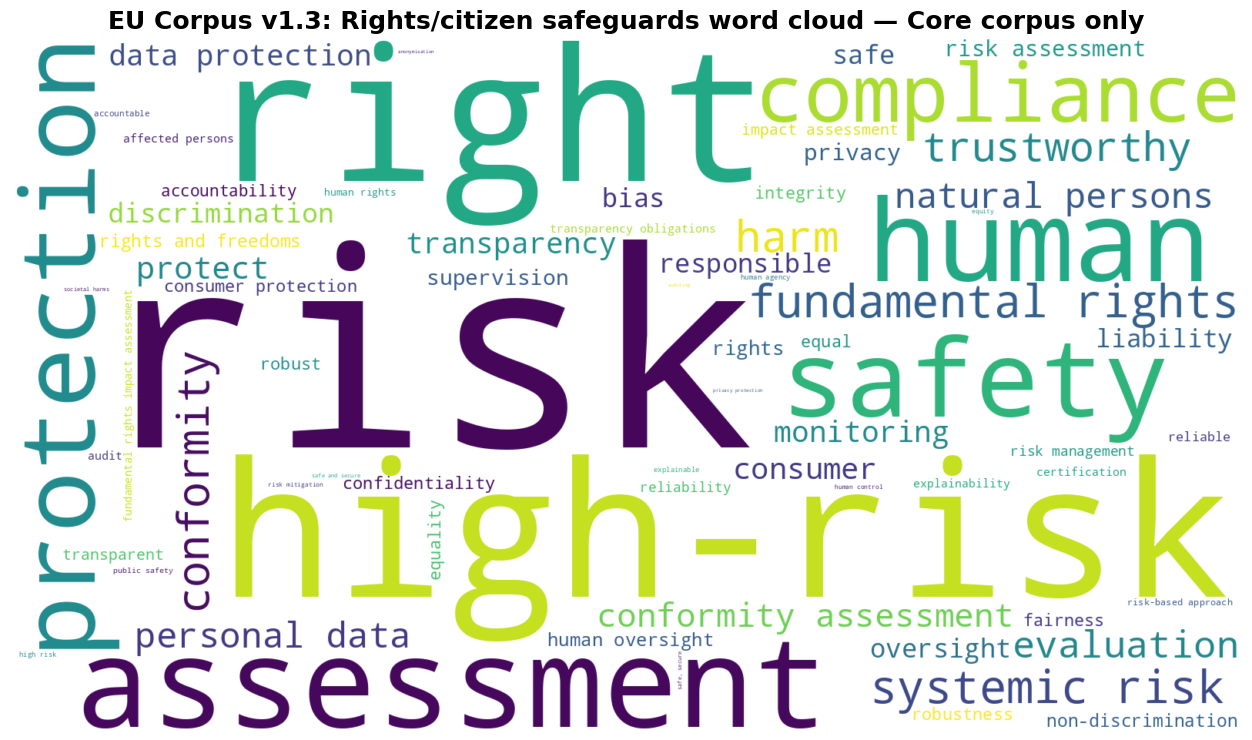

Saved word cloud for Rights/citizen safeguards: /content/eu_ai_governance_artefact/outputs/figures/wordclouds_core_16/wordcloud_rights_citizen_safeguards_core_16.png


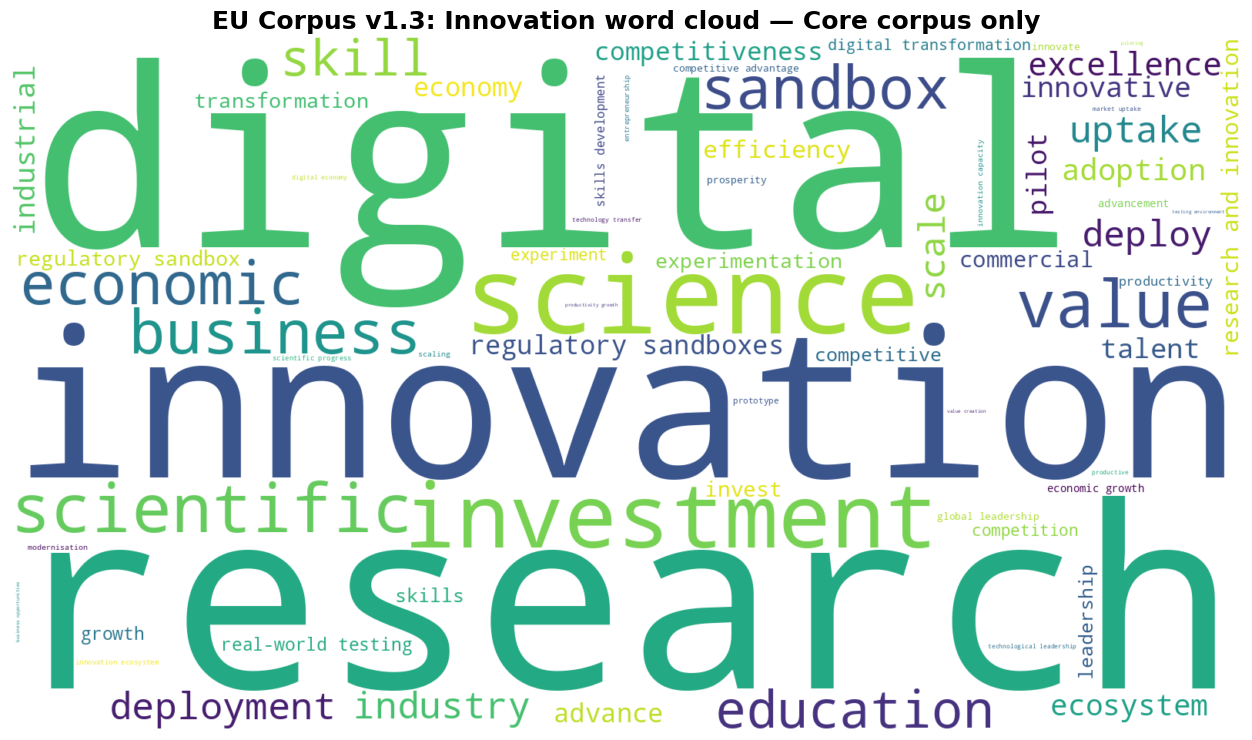

Saved word cloud for Innovation: /content/eu_ai_governance_artefact/outputs/figures/wordclouds_core_16/wordcloud_innovation_core_16.png


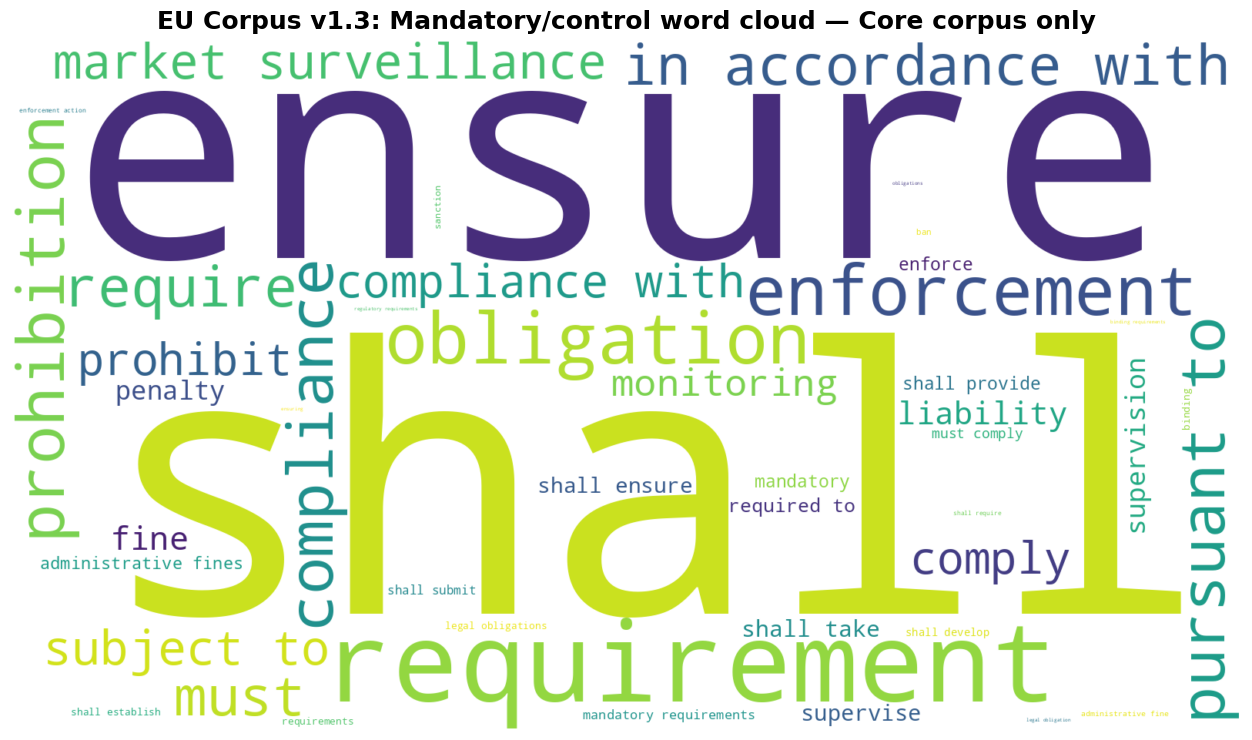

Saved word cloud for Mandatory/control: /content/eu_ai_governance_artefact/outputs/figures/wordclouds_core_16/wordcloud_mandatory_control_core_16.png


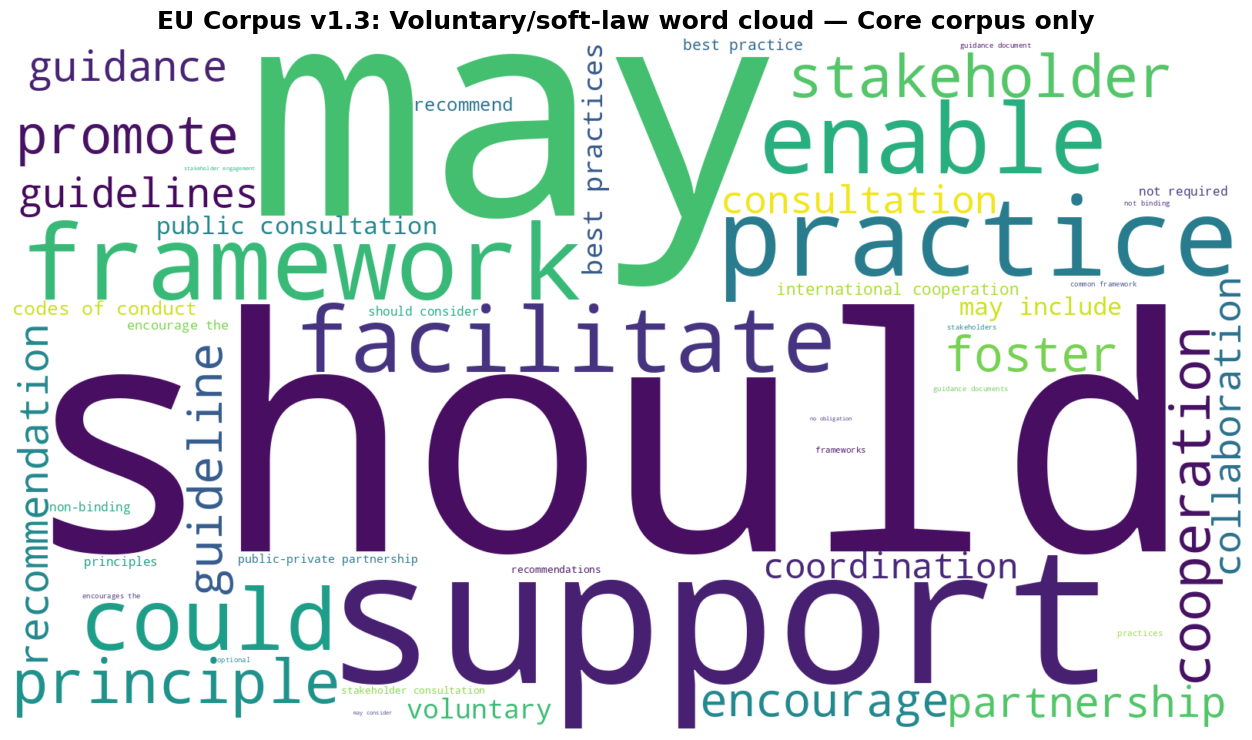

Saved word cloud for Voluntary/soft-law: /content/eu_ai_governance_artefact/outputs/figures/wordclouds_core_16/wordcloud_voluntary_soft_law_core_16.png
Step 23 completed: word clouds created using core 16 documents only.
Word cloud frequency table saved to: /content/eu_ai_governance_artefact/outputs/tables/eu_only_v1_3_wordcloud_term_frequencies_core_16.csv
Word clouds saved in: /content/eu_ai_governance_artefact/outputs/figures/wordclouds_core_16


In [ ]:
# ============================================================
# Step 23 – Word clouds by analytical component
# EU-only v1.3 artefact
# Aggregate-level output using core 16 documents only
# EU_12 and EU_18 are excluded
# ============================================================

import os
import matplotlib.pyplot as plt

# Install wordcloud if needed
!pip install wordcloud -q

from wordcloud import WordCloud

# ------------------------------------------------------------
# 23.1 Prepare aggregate vocabulary data
# ------------------------------------------------------------

# Use aggregate_vocabulary_df from Step 22.
# It already includes only core 16 documents.

if "aggregate_vocabulary_df" not in globals():
    aggregate_vocabulary_df = analytical_vocabulary_df[
        analytical_vocabulary_df["include_aggregate_level"] == True
    ].copy()

# Aggregate term frequencies by category and term
wordcloud_terms_df = (
    aggregate_vocabulary_df
    .groupby(["category", "term"], as_index=False)
    .agg(total_frequency=("absolute_frequency", "sum"))
)

category_labels = {
    "rights_citizen_safeguards": "Rights/citizen safeguards",
    "innovation": "Innovation",
    "mandatory_control": "Mandatory/control",
    "voluntary_soft_law": "Voluntary/soft-law"
}

# Output folder
WORDCLOUD_DIR = os.path.join(
    FIGURES_DIR,
    "wordclouds_core_16"
)

os.makedirs(WORDCLOUD_DIR, exist_ok=True)

# ------------------------------------------------------------
# 23.2 Generate one word cloud per analytical component
# ------------------------------------------------------------

for category, readable_label in category_labels.items():

    category_df = wordcloud_terms_df[
        wordcloud_terms_df["category"] == category
    ].copy()

    if category_df.empty:
        print(f"No terms found for category: {readable_label}")
        continue

    frequencies = dict(
        zip(
            category_df["term"],
            category_df["total_frequency"]
        )
    )

    wordcloud = WordCloud(
        width=1600,
        height=900,
        background_color="white",
        collocations=False,
        max_words=80
    ).generate_from_frequencies(frequencies)

    plt.figure(figsize=(16, 9))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(
        f"EU Corpus v1.3: {readable_label} word cloud — Core corpus only",
        fontsize=18,
        fontweight="bold"
    )

    safe_label = (
        readable_label
        .lower()
        .replace("/", "_")
        .replace(" ", "_")
        .replace("-", "_")
    )

    wordcloud_path = os.path.join(
        WORDCLOUD_DIR,
        f"wordcloud_{safe_label}_core_16.png"
    )

    plt.savefig(
        wordcloud_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"Saved word cloud for {readable_label}: {wordcloud_path}")

# ------------------------------------------------------------
# 23.3 Save underlying word cloud frequency table
# ------------------------------------------------------------

wordcloud_table_path = os.path.join(
    TABLES_DIR,
    "eu_only_v1_3_wordcloud_term_frequencies_core_16.csv"
)

wordcloud_terms_df.to_csv(
    wordcloud_table_path,
    index=False,
    encoding="utf-8-sig"
)

print("Step 23 completed: word clouds created using core 16 documents only.")
print(f"Word cloud frequency table saved to: {wordcloud_table_path}")
print(f"Word clouds saved in: {WORDCLOUD_DIR}")

Documents included in aggregate word cloud:


,document_id,document,include_aggregate_level
60,EU_01,AI for Europe,True
156,EU_02,Coordinated Plan on AI 2018,True
264,EU_03,Ethics Guidelines for Trustworthy AI,True
400,EU_04,White Paper on AI,True
524,EU_05,Fostering a European approach to AI,True
655,EU_06,Coordinated Plan on AI 2021 Review,True
832,EU_07,AI Act,True
949,EU_08,AI Pact,True
1007,EU_09,Apply AI Strategy,True
1123,EU_10,AI Continent Action Plan,True


,term,total_frequency
178,risk,1772
204,should,1192
196,shall,1147
117,may,983
61,ensure,748
29,compliance,720
90,high-risk,652
175,right,642
217,support,637
9,assessment,624


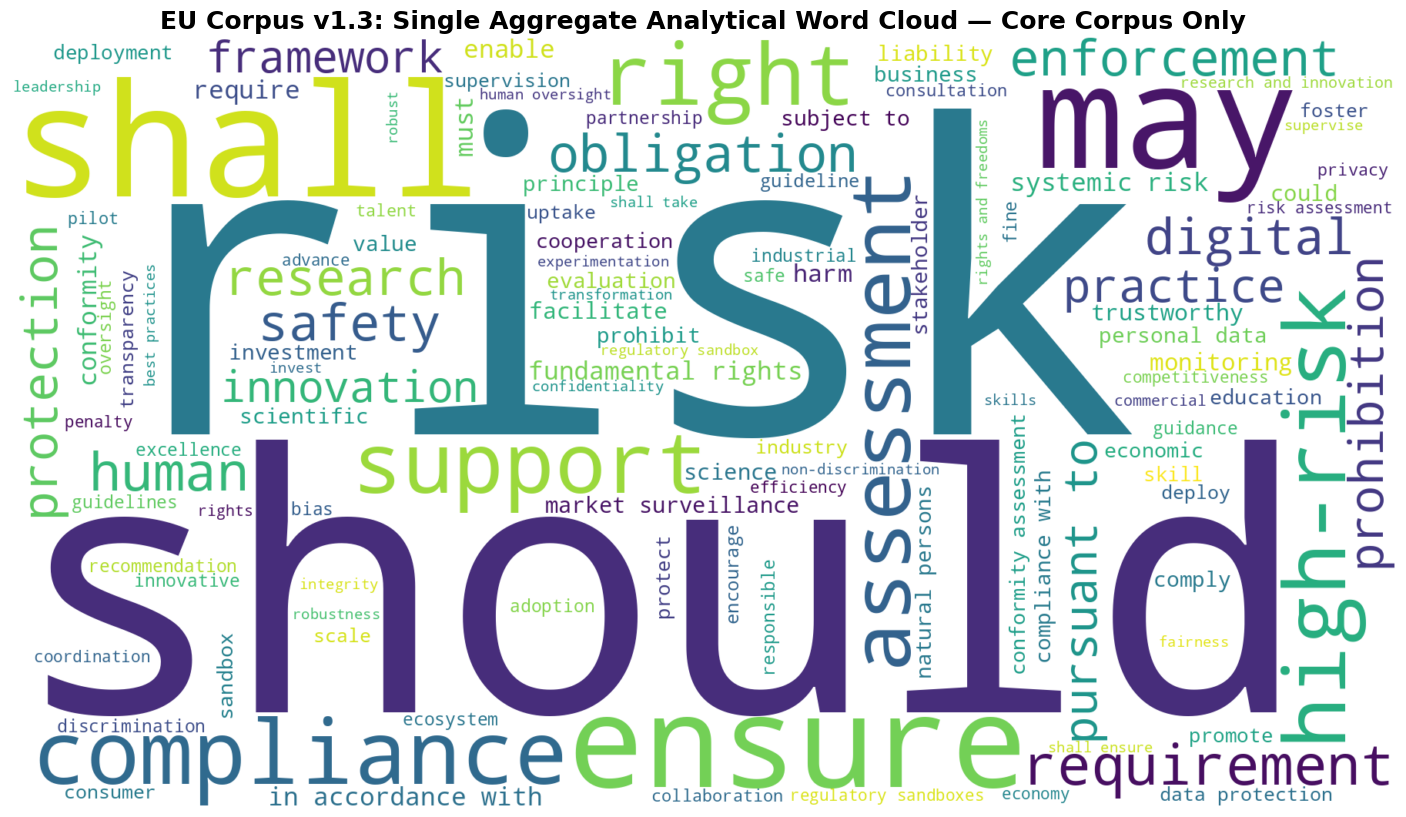

Step 23 completed: single aggregate word cloud created using core 16 documents only.
Word cloud table saved to: /content/eu_ai_governance_artefact/outputs/tables/eu_only_v1_3_single_aggregate_wordcloud_terms_core_16.csv
Word cloud figure saved to: /content/eu_ai_governance_artefact/outputs/figures/figure_11_single_aggregate_wordcloud_core_16.png


In [ ]:
# ============================================================
# Step 23 – Single aggregate word cloud
# EU-only v1.3 artefact
# Aggregate-level output using core 16 documents only
# EU_12 and EU_18 are excluded
# ============================================================

import os
import matplotlib.pyplot as plt

# Install wordcloud if needed
!pip install wordcloud -q

from wordcloud import WordCloud

# ------------------------------------------------------------
# 23.1 Filter analytical vocabulary to core 16 documents only
# ------------------------------------------------------------

aggregate_vocabulary_df = analytical_vocabulary_df[
    analytical_vocabulary_df["include_aggregate_level"] == True
].copy()

print("Documents included in aggregate word cloud:")
display(
    aggregate_vocabulary_df[
        ["document_id", "document", "include_aggregate_level"]
    ].drop_duplicates().sort_values("document_id")
)

# ------------------------------------------------------------
# 23.2 Aggregate all analytical terms across all four categories
# ------------------------------------------------------------

aggregate_wordcloud_terms = (
    aggregate_vocabulary_df
    .groupby(["term"], as_index=False)
    .agg(total_frequency=("absolute_frequency", "sum"))
    .sort_values("total_frequency", ascending=False)
)

# Save underlying word cloud frequency table
aggregate_wordcloud_table_path = os.path.join(
    TABLES_DIR,
    "eu_only_v1_3_single_aggregate_wordcloud_terms_core_16.csv"
)

aggregate_wordcloud_terms.to_csv(
    aggregate_wordcloud_table_path,
    index=False,
    encoding="utf-8-sig"
)

display(aggregate_wordcloud_terms.head(40))

# ------------------------------------------------------------
# 23.3 Generate one aggregate word cloud
# ------------------------------------------------------------

frequencies = dict(
    zip(
        aggregate_wordcloud_terms["term"],
        aggregate_wordcloud_terms["total_frequency"]
    )
)

wordcloud = WordCloud(
    width=1800,
    height=1000,
    background_color="white",
    collocations=False,
    max_words=120
).generate_from_frequencies(frequencies)

plt.figure(figsize=(18, 10))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title(
    "EU Corpus v1.3: Single Aggregate Analytical Word Cloud — Core Corpus Only",
    fontsize=18,
    fontweight="bold"
)

# ------------------------------------------------------------
# 23.4 Save figure
# ------------------------------------------------------------

aggregate_wordcloud_path = os.path.join(
    FIGURES_DIR,
    "figure_11_single_aggregate_wordcloud_core_16.png"
)

plt.savefig(
    aggregate_wordcloud_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Step 23 completed: single aggregate word cloud created using core 16 documents only.")
print(f"Word cloud table saved to: {aggregate_wordcloud_table_path}")
print(f"Word cloud figure saved to: {aggregate_wordcloud_path}")

In [ ]:
# ============================================================
# Step 25 – Document-type comparison chart
# EU-only v1.3 artefact
# Aggregate-level graph using core 16 documents only
# EU_12 and EU_18 are excluded
# Based on the original model artefact logic
# ============================================================

import plotly.graph_objects as go
import os
import pandas as pd

# ------------------------------------------------------------
# 25.1 Build document-type summary table
# ------------------------------------------------------------

# Aggregate-level rule:
# use aggregate_df, which contains only the core 16 documents.

document_type_summary = (
    aggregate_df
    .groupby("document_type")
    .agg(
        mean_x_score=("x_score", "mean"),
        mean_y_score=("y_score_adjusted", "mean"),
        document_count=("document_id", "count")
    )
    .reset_index()
)

document_type_summary["mean_x_score"] = document_type_summary["mean_x_score"].round(2)
document_type_summary["mean_y_score"] = document_type_summary["mean_y_score"].round(2)

# Sort by mean_x_score for visual readability
document_type_summary = document_type_summary.sort_values(
    by="mean_x_score",
    ascending=True
).reset_index(drop=True)

display(document_type_summary)

# Save table
document_type_summary_path = os.path.join(
    TABLES_DIR,
    "eu_only_v1_3_document_type_comparison_core_16.csv"
)

document_type_summary.to_csv(
    document_type_summary_path,
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# 25.2 Create horizontal comparison chart
# ------------------------------------------------------------

fig_doc_type = go.Figure()

# X-axis / regulatory orientation:
# negative = rights/citizen safeguards
# positive = innovation
fig_doc_type.add_trace(
    go.Bar(
        y=document_type_summary["document_type"],
        x=document_type_summary["mean_x_score"],
        orientation="h",
        name="Mean X score: safeguards ↔ innovation",
        marker_color="blue",
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Mean X score: %{x:.2f}<br>"
            "Negative = rights/citizen safeguards<br>"
            "Positive = innovation<extra></extra>"
        )
    )
)

# Y-axis / force orientation:
# negative = voluntary
# positive = mandatory-binding
fig_doc_type.add_trace(
    go.Bar(
        y=document_type_summary["document_type"],
        x=document_type_summary["mean_y_score"],
        orientation="h",
        name="Mean Y score: voluntary ↔ mandatory",
        marker_color="red",
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Mean Y score: %{x:.2f}<br>"
            "Negative = voluntary / soft-law<br>"
            "Positive = mandatory / control<extra></extra>"
        )
    )
)

# ------------------------------------------------------------
# 25.3 Add document counts as annotations
# ------------------------------------------------------------

for _, row in document_type_summary.iterrows():
    max_position = max(row["mean_x_score"], row["mean_y_score"], 0)
    min_position = min(row["mean_x_score"], row["mean_y_score"], 0)

    # Place count label just outside the rightmost positive bar,
    # or close to zero if both values are negative.
    label_x = max_position + 5 if max_position >= 0 else 5

    fig_doc_type.add_annotation(
        x=label_x,
        y=row["document_type"],
        text=f"n={row['document_count']}",
        showarrow=False,
        font=dict(size=11)
    )


# ------------------------------------------------------------
# 25.4 Layout
# ------------------------------------------------------------

fig_doc_type.add_vline(
    x=0,
    line_dash="dash",
    line_color="black"
)

fig_doc_type.update_layout(
    title="EU Corpus v1.3: Average Regulatory Scores by Document Type — Core Corpus Only",
    xaxis_title="Average score",
    yaxis_title="Document type",
    barmode="overlay",
    width=1350,
    height=850,
    legend_title="Score dimension",
    xaxis=dict(range=[-100, 100]),
)

# Optional explanatory subtitle as annotation
fig_doc_type.add_annotation(
    x=0,
    y=1.08,
    xref="paper",
    yref="paper",
    text="Blue: safeguards (-) to innovation (+); Red: voluntary (-) to mandatory/control (+)",
    showarrow=False,
    font=dict(size=12)
)


# ------------------------------------------------------------
# 25.5 Save graph outputs
# ------------------------------------------------------------

document_type_chart_html_path = os.path.join(
    FIGURES_DIR,
    "figure_12_document_type_comparison_core_16.html"
)

fig_doc_type.write_html(document_type_chart_html_path)

try:
    document_type_chart_png_path = os.path.join(
        FIGURES_DIR,
        "figure_12_document_type_comparison_core_16.png"
    )
    fig_doc_type.write_image(document_type_chart_png_path, scale=2)
    print(f"PNG saved to: {document_type_chart_png_path}")

except Exception as e:
    print("PNG export skipped. Interactive HTML was saved successfully.")
    print("If you need PNG export, run: !pip install -U kaleido")
    print(e)

fig_doc_type.show()

print("Step 25 completed: document-type comparison chart created using core 16 documents only.")
print(f"Table saved to: {document_type_summary_path}")
print(f"Interactive HTML saved to: {document_type_chart_html_path}")

,document_type,mean_x_score,mean_y_score,document_count
0,Code of practice,-79.62,-8.76,1
1,Regulation,-65.66,48.73,1
2,Council draft,-64.27,61.04,1
3,Pact,-54.84,-33.86,1
4,Guidelines,-51.17,-27.96,4
5,White paper,-26.73,-28.40,1
6,Communication,44.83,-59.10,3
7,Coordinated plan,54.41,-66.02,2
8,Strategy,61.93,-67.81,1
9,Action plan,76.18,-51.42,1


PNG export skipped. Interactive HTML was saved successfully.
If you need PNG export, run: !pip install -U kaleido

Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



Step 25 completed: document-type comparison chart created using core 16 documents only.
Table saved to: /content/eu_ai_governance_artefact/outputs/tables/eu_only_v1_3_document_type_comparison_core_16.csv
Interactive HTML saved to: /content/eu_ai_governance_artefact/outputs/figures/figure_12_document_type_comparison_core_16.html


In [ ]:
# ============================================================
# Step 26A – Slope / trend graph for rights-citizen safeguards versus innovation
# EU-only v1.3 artefact
# Core 16 documents only
# EU_12 and EU_18 are excluded
# ============================================================

import plotly.graph_objects as go
import os
import pandas as pd

# ------------------------------------------------------------
# 26A.1 Prepare data
# ------------------------------------------------------------

# aggregate_df contains only the core 16 documents.
# It excludes EU_12 and EU_18 and includes EU_17.

slope_x_df = aggregate_df[
    [
        "document_id",
        "document",
        "document_type",
        "year",
        "x_score"
    ]
].copy()

slope_x_df = slope_x_df.sort_values(
    by=["year", "document_id"]
).reset_index(drop=True)

# Create a readable x-axis label combining year and document ID
slope_x_df["year_document"] = (
    slope_x_df["year"].astype(str) + " | " + slope_x_df["document_id"]
)

# Save table
slope_x_table_path = os.path.join(
    TABLES_DIR,
    "eu_only_v1_3_slope_rights_innovation_core_16.csv"
)

slope_x_df.to_csv(
    slope_x_table_path,
    index=False,
    encoding="utf-8-sig"
)

display(slope_x_df)

# ------------------------------------------------------------
# 26A.2 Create slope / trend graph
# ------------------------------------------------------------

fig_slope_x = go.Figure()

fig_slope_x.add_trace(
    go.Scatter(
        x=slope_x_df["year_document"],
        y=slope_x_df["x_score"],
        mode="lines+markers+text",
        text=slope_x_df["document_id"],
        textposition="top center",
        line=dict(
            color="blue",
            width=3
        ),
        marker=dict(
            color="blue",
            size=11
        ),
        name="Rights/citizen safeguards ↔ Innovation",
        hovertemplate=(
            "<b>%{text}</b><br>"
            "Document: %{customdata[0]}<br>"
            "Document type: %{customdata[1]}<br>"
            "Year: %{customdata[2]}<br>"
            "X score: %{y:.2f}<br>"
            "<extra></extra>"
        ),
        customdata=slope_x_df[
            [
                "document",
                "document_type",
                "year"
            ]
        ]
    )
)

# Zero line
fig_slope_x.add_hline(
    y=0,
    line_dash="dash",
    line_color="black"
)

# ------------------------------------------------------------
# 26A.3 Add interpretation zones
# ------------------------------------------------------------

fig_slope_x.add_annotation(
    x=0,
    y=90,
    xref="paper",
    yref="y",
    text="Innovation-oriented zone",
    showarrow=False,
    font=dict(size=12)
)

fig_slope_x.add_annotation(
    x=0,
    y=-90,
    xref="paper",
    yref="y",
    text="Rights/citizen safeguards-oriented zone",
    showarrow=False,
    font=dict(size=12)
)

# ------------------------------------------------------------
# 26A.4 Layout
# ------------------------------------------------------------

fig_slope_x.update_layout(
    title="EU Corpus v1.3: Slope Graph of Rights/Citizen Safeguards–Innovation Scores — Core Corpus Only",
    xaxis_title="Document sequence by year",
    yaxis_title="Rights/citizen safeguards (-100) ↔ Innovation (+100)",
    yaxis=dict(range=[-100, 100]),
    width=1400,
    height=800,
    showlegend=False
)

fig_slope_x.update_xaxes(
    tickangle=45
)

# ------------------------------------------------------------
# 26A.5 Save graph outputs
# ------------------------------------------------------------

slope_x_html_path = os.path.join(
    FIGURES_DIR,
    "figure_13a_slope_rights_innovation_core_16.html"
)

fig_slope_x.write_html(slope_x_html_path)

try:
    slope_x_png_path = os.path.join(
        FIGURES_DIR,
        "figure_13a_slope_rights_innovation_core_16.png"
    )
    fig_slope_x.write_image(slope_x_png_path, scale=2)
    print(f"PNG saved to: {slope_x_png_path}")

except Exception as e:
    print("PNG export skipped. Interactive HTML was saved successfully.")
    print("If you need PNG export, run: !pip install -U kaleido")
    print(e)

fig_slope_x.show()

print("Step 26A completed: slope graph for rights/citizen safeguards versus innovation created.")
print(f"Table saved to: {slope_x_table_path}")
print(f"Interactive HTML saved to: {slope_x_html_path}")

,document_id,document,document_type,year,x_score,year_document
0,EU_01,AI for Europe,Communication,2018,44.12,2018 | EU_01
1,EU_02,Coordinated Plan on AI 2018,Coordinated plan,2018,54.95,2018 | EU_02
2,EU_03,Ethics Guidelines for Trustworthy AI,Guidelines,2019,-57.53,2019 | EU_03
3,EU_04,White Paper on AI,White paper,2020,-26.73,2020 | EU_04
4,EU_05,Fostering a European approach to AI,Communication,2021,9.09,2021 | EU_05
5,EU_06,Coordinated Plan on AI 2021 Review,Coordinated plan,2021,53.87,2021 | EU_06
6,EU_07,AI Act,Regulation,2024,-65.66,2024 | EU_07
7,EU_08,AI Pact,Pact,2024,-54.84,2024 | EU_08
8,EU_09,Apply AI Strategy,Strategy,2025,61.93,2025 | EU_09
9,EU_10,AI Continent Action Plan,Action plan,2025,76.18,2025 | EU_10


PNG export skipped. Interactive HTML was saved successfully.
If you need PNG export, run: !pip install -U kaleido

Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



Step 26A completed: slope graph for rights/citizen safeguards versus innovation created.
Table saved to: /content/eu_ai_governance_artefact/outputs/tables/eu_only_v1_3_slope_rights_innovation_core_16.csv
Interactive HTML saved to: /content/eu_ai_governance_artefact/outputs/figures/figure_13a_slope_rights_innovation_core_16.html


In [ ]:
# ============================================================
# Step 26B – Clean slope / trend graph for voluntary versus mandatory/control
# EU-only v1.3 artefact
# Core 16 documents only
# EU_12 and EU_18 are excluded
# ============================================================

import plotly.graph_objects as go
import os
import pandas as pd

# ------------------------------------------------------------
# 26B.1 Prepare data
# ------------------------------------------------------------

# aggregate_df contains only the core 16 documents.
# It excludes EU_12 and EU_18 and includes EU_17.

slope_y_df = aggregate_df[
    [
        "document_id",
        "document",
        "document_type",
        "year",
        "y_score_adjusted"
    ]
].copy()

slope_y_df = slope_y_df.sort_values(
    by=["year", "document_id"]
).reset_index(drop=True)

# Create a readable document sequence label
slope_y_df["document_sequence"] = (
    slope_y_df["year"].astype(str) + " | " + slope_y_df["document_id"]
)

# Save table
slope_y_table_path = os.path.join(
    TABLES_DIR,
    "eu_only_v1_3_clean_slope_voluntary_mandatory_core_16.csv"
)

slope_y_df.to_csv(
    slope_y_table_path,
    index=False,
    encoding="utf-8-sig"
)

display(slope_y_df)

# ------------------------------------------------------------
# 26B.2 Create one clean red slope graph
# ------------------------------------------------------------

fig_slope_y = go.Figure()

fig_slope_y.add_trace(
    go.Scatter(
        x=slope_y_df["document_sequence"],
        y=slope_y_df["y_score_adjusted"],
        mode="lines+markers+text",
        text=slope_y_df["document_id"],
        textposition="top center",
        line=dict(
            color="red",
            width=3
        ),
        marker=dict(
            color="red",
            size=10
        ),
        name="Voluntary/soft-law ↔ Mandatory/control",
        customdata=slope_y_df[
            [
                "document",
                "document_type",
                "year"
            ]
        ],
        hovertemplate=(
            "<b>%{text}</b><br>"
            "Document: %{customdata[0]}<br>"
            "Document type: %{customdata[1]}<br>"
            "Year: %{customdata[2]}<br>"
            "Y score: %{y:.2f}<br>"
            "<extra></extra>"
        )
    )
)

# ------------------------------------------------------------
# 26B.3 Add zero line and interpretation labels
# ------------------------------------------------------------

fig_slope_y.add_hline(
    y=0,
    line_dash="dash",
    line_color="black"
)

fig_slope_y.add_annotation(
    x=0.01,
    y=85,
    xref="paper",
    yref="y",
    text="Mandatory/control-oriented documents",
    showarrow=False,
    font=dict(size=12)
)

fig_slope_y.add_annotation(
    x=0.01,
    y=-85,
    xref="paper",
    yref="y",
    text="Voluntary/soft-law-oriented documents",
    showarrow=False,
    font=dict(size=12)
)

# ------------------------------------------------------------
# 26B.4 Layout
# ------------------------------------------------------------

fig_slope_y.update_layout(
    title="EU Corpus v1.3: Voluntary–Mandatory Slope Graph — Core Corpus Only",
    xaxis_title="Document sequence by year",
    yaxis_title="Voluntary/soft-law (-100) ↔ Mandatory/control (+100)",
    yaxis=dict(range=[-100, 100]),
    width=1450,
    height=800,
    showlegend=False
)

fig_slope_y.update_xaxes(
    tickangle=45
)

# ------------------------------------------------------------
# 26B.5 Save graph outputs
# ------------------------------------------------------------

slope_y_html_path = os.path.join(
    FIGURES_DIR,
    "figure_13b_clean_slope_voluntary_mandatory_core_16.html"
)

fig_slope_y.write_html(slope_y_html_path)

try:
    slope_y_png_path = os.path.join(
        FIGURES_DIR,
        "figure_13b_clean_slope_voluntary_mandatory_core_16.png"
    )
    fig_slope_y.write_image(slope_y_png_path, scale=2)
    print(f"PNG saved to: {slope_y_png_path}")

except Exception as e:
    print("PNG export skipped. Interactive HTML was saved successfully.")
    print("If you need PNG export, run: !pip install -U kaleido")
    print(e)

fig_slope_y.show()

print("Step 26B completed: clean red slope graph for voluntary versus mandatory/control created.")
print(f"Table saved to: {slope_y_table_path}")
print(f"Interactive HTML saved to: {slope_y_html_path}")

,document_id,document,document_type,year,y_score_adjusted,document_sequence
0,EU_01,AI for Europe,Communication,2018,-63.55,2018 | EU_01
1,EU_02,Coordinated Plan on AI 2018,Coordinated plan,2018,-58.65,2018 | EU_02
2,EU_03,Ethics Guidelines for Trustworthy AI,Guidelines,2019,-43.94,2019 | EU_03
3,EU_04,White Paper on AI,White paper,2020,-28.40,2020 | EU_04
4,EU_05,Fostering a European approach to AI,Communication,2021,-42.86,2021 | EU_05
5,EU_06,Coordinated Plan on AI 2021 Review,Coordinated plan,2021,-73.38,2021 | EU_06
6,EU_07,AI Act,Regulation,2024,48.73,2024 | EU_07
7,EU_08,AI Pact,Pact,2024,-33.86,2024 | EU_08
8,EU_09,Apply AI Strategy,Strategy,2025,-67.81,2025 | EU_09
9,EU_10,AI Continent Action Plan,Action plan,2025,-51.42,2025 | EU_10


PNG export skipped. Interactive HTML was saved successfully.
If you need PNG export, run: !pip install -U kaleido

Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



Step 26B completed: clean red slope graph for voluntary versus mandatory/control created.
Table saved to: /content/eu_ai_governance_artefact/outputs/tables/eu_only_v1_3_clean_slope_voluntary_mandatory_core_16.csv
Interactive HTML saved to: /content/eu_ai_governance_artefact/outputs/figures/figure_13b_clean_slope_voluntary_mandatory_core_16.html


In [ ]:
# ============================================================
# Step 26C – Combined slope / trend graph for both regulatory axes
# EU-only v1.3 artefact
# Core 16 documents only
# EU_12 and EU_18 are excluded
# ============================================================

import plotly.graph_objects as go
import os
import pandas as pd

# ------------------------------------------------------------
# 26C.1 Prepare data
# ------------------------------------------------------------

combined_slope_df = aggregate_df[
    [
        "document_id",
        "document",
        "document_type",
        "year",
        "x_score",
        "y_score_adjusted"
    ]
].copy()

combined_slope_df = combined_slope_df.sort_values(
    by=["year", "document_id"]
).reset_index(drop=True)

combined_slope_df["document_sequence"] = (
    combined_slope_df["year"].astype(str) + " | " + combined_slope_df["document_id"]
)

# Save table
combined_slope_table_path = os.path.join(
    TABLES_DIR,
    "eu_only_v1_3_combined_slope_two_axes_core_16.csv"
)

combined_slope_df.to_csv(
    combined_slope_table_path,
    index=False,
    encoding="utf-8-sig"
)

display(combined_slope_df)

# ------------------------------------------------------------
# 26C.2 Create combined slope graph
# ------------------------------------------------------------

fig_combined_slope = go.Figure()

# Blue line: rights/citizen safeguards ↔ innovation
fig_combined_slope.add_trace(
    go.Scatter(
        x=combined_slope_df["document_sequence"],
        y=combined_slope_df["x_score"],
        mode="lines+markers+text",
        text=combined_slope_df["document_id"],
        textposition="top center",
        line=dict(
            color="blue",
            width=3
        ),
        marker=dict(
            color="blue",
            size=10
        ),
        name="Rights/citizen safeguards ↔ Innovation",
        customdata=combined_slope_df[
            [
                "document",
                "document_type",
                "year"
            ]
        ],
        hovertemplate=(
            "<b>%{text}</b><br>"
            "Document: %{customdata[0]}<br>"
            "Document type: %{customdata[1]}<br>"
            "Year: %{customdata[2]}<br>"
            "X score: %{y:.2f}<br>"
            "Negative = rights/citizen safeguards<br>"
            "Positive = innovation"
            "<extra></extra>"
        )
    )
)

# Red line: voluntary/soft-law ↔ mandatory/control
fig_combined_slope.add_trace(
    go.Scatter(
        x=combined_slope_df["document_sequence"],
        y=combined_slope_df["y_score_adjusted"],
        mode="lines+markers+text",
        text=combined_slope_df["document_id"],
        textposition="bottom center",
        line=dict(
            color="red",
            width=3
        ),
        marker=dict(
            color="red",
            size=10
        ),
        name="Voluntary/soft-law ↔ Mandatory/control",
        customdata=combined_slope_df[
            [
                "document",
                "document_type",
                "year"
            ]
        ],
        hovertemplate=(
            "<b>%{text}</b><br>"
            "Document: %{customdata[0]}<br>"
            "Document type: %{customdata[1]}<br>"
            "Year: %{customdata[2]}<br>"
            "Y score: %{y:.2f}<br>"
            "Negative = voluntary/soft-law<br>"
            "Positive = mandatory/control"
            "<extra></extra>"
        )
    )
)

# ------------------------------------------------------------
# 26C.3 Add zero line and interpretation labels
# ------------------------------------------------------------

fig_combined_slope.add_hline(
    y=0,
    line_dash="dash",
    line_color="black"
)

fig_combined_slope.add_annotation(
    x=0.01,
    y=92,
    xref="paper",
    yref="y",
    text="Positive side: innovation or mandatory/control",
    showarrow=False,
    font=dict(size=12)
)

fig_combined_slope.add_annotation(
    x=0.01,
    y=-92,
    xref="paper",
    yref="y",
    text="Negative side: rights/citizen safeguards or voluntary/soft-law",
    showarrow=False,
    font=dict(size=12)
)

# ------------------------------------------------------------
# 26C.4 Layout
# ------------------------------------------------------------

fig_combined_slope.update_layout(
    title="EU Corpus v1.3: Combined Slope Graph of the Two Regulatory Axes — Core Corpus Only",
    xaxis_title="Document sequence by year",
    yaxis_title="Axis score (-100 to +100)",
    yaxis=dict(range=[-100, 100]),
    width=1500,
    height=850,
    legend_title="Regulatory axis"
)

fig_combined_slope.update_xaxes(
    tickangle=45
)

# ------------------------------------------------------------
# 26C.5 Save graph outputs
# ------------------------------------------------------------

combined_slope_html_path = os.path.join(
    FIGURES_DIR,
    "figure_13c_combined_slope_two_axes_core_16.html"
)

fig_combined_slope.write_html(combined_slope_html_path)

try:
    combined_slope_png_path = os.path.join(
        FIGURES_DIR,
        "figure_13c_combined_slope_two_axes_core_16.png"
    )
    fig_combined_slope.write_image(combined_slope_png_path, scale=2)
    print(f"PNG saved to: {combined_slope_png_path}")

except Exception as e:
    print("PNG export skipped. Interactive HTML was saved successfully.")
    print("If you need PNG export, run: !pip install -U kaleido")
    print(e)

fig_combined_slope.show()

print("Step 26C completed: combined slope graph for both regulatory axes created.")
print(f"Table saved to: {combined_slope_table_path}")
print(f"Interactive HTML saved to: {combined_slope_html_path}")

,document_id,document,document_type,year,x_score,y_score_adjusted,document_sequence
0,EU_01,AI for Europe,Communication,2018,44.12,-63.55,2018 | EU_01
1,EU_02,Coordinated Plan on AI 2018,Coordinated plan,2018,54.95,-58.65,2018 | EU_02
2,EU_03,Ethics Guidelines for Trustworthy AI,Guidelines,2019,-57.53,-43.94,2019 | EU_03
3,EU_04,White Paper on AI,White paper,2020,-26.73,-28.40,2020 | EU_04
4,EU_05,Fostering a European approach to AI,Communication,2021,9.09,-42.86,2021 | EU_05
5,EU_06,Coordinated Plan on AI 2021 Review,Coordinated plan,2021,53.87,-73.38,2021 | EU_06
6,EU_07,AI Act,Regulation,2024,-65.66,48.73,2024 | EU_07
7,EU_08,AI Pact,Pact,2024,-54.84,-33.86,2024 | EU_08
8,EU_09,Apply AI Strategy,Strategy,2025,61.93,-67.81,2025 | EU_09
9,EU_10,AI Continent Action Plan,Action plan,2025,76.18,-51.42,2025 | EU_10


PNG export skipped. Interactive HTML was saved successfully.
If you need PNG export, run: !pip install -U kaleido

Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



Step 26C completed: combined slope graph for both regulatory axes created.
Table saved to: /content/eu_ai_governance_artefact/outputs/tables/eu_only_v1_3_combined_slope_two_axes_core_16.csv
Interactive HTML saved to: /content/eu_ai_governance_artefact/outputs/figures/figure_13c_combined_slope_two_axes_core_16.html


In [ ]:
# ============================================================
# Step 27 – Correlation analysis between the two final regulatory axes
# EU-only v1.3 artefact
# Diagnostic / supplementary graph
# Core 16 documents only
# EU_12 and EU_18 are excluded
# ============================================================

import os
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Install scipy if needed
!pip install scipy -q

from scipy.stats import pearsonr, spearmanr

# ------------------------------------------------------------
# 27.1 Prepare data
# ------------------------------------------------------------

correlation_df = aggregate_df[
    [
        "document_id",
        "document",
        "document_type",
        "year",
        "x_score",
        "y_score_adjusted"
    ]
].copy()

display(correlation_df)

# Save base correlation table
correlation_table_path = os.path.join(
    TABLES_DIR,
    "eu_only_v1_3_correlation_axes_core_16.csv"
)

correlation_df.to_csv(
    correlation_table_path,
    index=False,
    encoding="utf-8-sig"
)

# ------------------------------------------------------------
# 27.2 Compute correlation coefficients
# ------------------------------------------------------------

pearson_r, pearson_p = pearsonr(
    correlation_df["x_score"],
    correlation_df["y_score_adjusted"]
)

spearman_rho, spearman_p = spearmanr(
    correlation_df["x_score"],
    correlation_df["y_score_adjusted"]
)

correlation_stats_df = pd.DataFrame([
    {
        "correlation_type": "Pearson",
        "coefficient": round(pearson_r, 4),
        "p_value": round(pearson_p, 4)
    },
    {
        "correlation_type": "Spearman",
        "coefficient": round(spearman_rho, 4),
        "p_value": round(spearman_p, 4)
    }
])

display(correlation_stats_df)

correlation_stats_path = os.path.join(
    TABLES_DIR,
    "eu_only_v1_3_correlation_statistics_core_16.csv"
)

correlation_stats_df.to_csv(
    correlation_stats_path,
    index=False,
    encoding="utf-8-sig"
)

# ------------------------------------------------------------
# 27.3 Create regression / trend line
# ------------------------------------------------------------

# Simple linear fit for visual guidance only
x_vals = correlation_df["x_score"].values
y_vals = correlation_df["y_score_adjusted"].values

slope, intercept = np.polyfit(x_vals, y_vals, 1)

x_line = np.linspace(-100, 100, 200)
y_line = slope * x_line + intercept

# ------------------------------------------------------------
# 27.4 Create scatter plot
# ------------------------------------------------------------

fig_corr = px.scatter(
    correlation_df,
    x="x_score",
    y="y_score_adjusted",
    text="document_id",
    symbol="document_type",
    hover_data=[
        "document",
        "document_type",
        "year"
    ],
    title="EU Corpus v1.3: Correlation Between the Two Regulatory Axes — Core Corpus Only",
    labels={
        "x_score": "Rights/citizen safeguards (-100) ↔ Innovation (+100)",
        "y_score_adjusted": "Voluntary/soft-law (-100) ↔ Mandatory/control (+100)",
        "document_type": "Document type"
    }
)

# Add regression / trend line
fig_corr.add_trace(
    go.Scatter(
        x=x_line,
        y=y_line,
        mode="lines",
        line=dict(color="black", dash="dash"),
        name="Linear trend"
    )
)

# Add zero lines
fig_corr.add_vline(x=0, line_dash="dash")
fig_corr.add_hline(y=0, line_dash="dash")

# Quadrant labels
fig_corr.add_annotation(
    x=-65,
    y=75,
    text="Mandatory rights/citizen safeguards",
    showarrow=False
)

fig_corr.add_annotation(
    x=65,
    y=75,
    text="Mandatory innovation",
    showarrow=False
)

fig_corr.add_annotation(
    x=-65,
    y=-75,
    text="Voluntary rights/citizen safeguards",
    showarrow=False
)

fig_corr.add_annotation(
    x=65,
    y=-75,
    text="Voluntary innovation",
    showarrow=False
)

# Add correlation summary annotation
fig_corr.add_annotation(
    x=0.99,
    y=0.01,
    xref="paper",
    yref="paper",
    xanchor="right",
    yanchor="bottom",
    align="right",
    showarrow=False,
    bordercolor="black",
    borderwidth=1,
    bgcolor="white",
    text=(
        f"Pearson r = {pearson_r:.2f} (p = {pearson_p:.3f})<br>"
        f"Spearman ρ = {spearman_rho:.2f} (p = {spearman_p:.3f})"
    )
)

fig_corr.update_traces(
    textposition="top center"
)

fig_corr.update_layout(
    width=1350,
    height=900,
    xaxis=dict(range=[-100, 100]),
    yaxis=dict(range=[-100, 100])
)

# ------------------------------------------------------------
# 27.5 Save graph outputs
# ------------------------------------------------------------

correlation_html_path = os.path.join(
    FIGURES_DIR,
    "figure_14_correlation_two_regulatory_axes_core_16.html"
)

fig_corr.write_html(correlation_html_path)

try:
    correlation_png_path = os.path.join(
        FIGURES_DIR,
        "figure_14_correlation_two_regulatory_axes_core_16.png"
    )
    fig_corr.write_image(correlation_png_path, scale=2)
    print(f"PNG saved to: {correlation_png_path}")

except Exception as e:
    print("PNG export skipped. Interactive HTML was saved successfully.")
    print("If you need PNG export, run: !pip install -U kaleido")
    print(e)

fig_corr.show()

print("Step 27 completed: correlation analysis between the two regulatory axes created.")
print(f"Base data table saved to: {correlation_table_path}")
print(f"Correlation statistics table saved to: {correlation_stats_path}")
print(f"Interactive HTML saved to: {correlation_html_path}")

,document_id,document,document_type,year,x_score,y_score_adjusted
0,EU_01,AI for Europe,Communication,2018,44.12,-63.55
1,EU_02,Coordinated Plan on AI 2018,Coordinated plan,2018,54.95,-58.65
2,EU_03,Ethics Guidelines for Trustworthy AI,Guidelines,2019,-57.53,-43.94
3,EU_04,White Paper on AI,White paper,2020,-26.73,-28.40
4,EU_05,Fostering a European approach to AI,Communication,2021,9.09,-42.86
5,EU_06,Coordinated Plan on AI 2021 Review,Coordinated plan,2021,53.87,-73.38
6,EU_07,AI Act,Regulation,2024,-65.66,48.73
7,EU_08,AI Pact,Pact,2024,-54.84,-33.86
8,EU_09,Apply AI Strategy,Strategy,2025,61.93,-67.81
9,EU_10,AI Continent Action Plan,Action plan,2025,76.18,-51.42


,correlation_type,coefficient,p_value
0,Pearson,-0.7332,0.0012
1,Spearman,-0.8147,0.0001


PNG export skipped. Interactive HTML was saved successfully.
If you need PNG export, run: !pip install -U kaleido

Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



Step 27 completed: correlation analysis between the two regulatory axes created.
Base data table saved to: /content/eu_ai_governance_artefact/outputs/tables/eu_only_v1_3_correlation_axes_core_16.csv
Correlation statistics table saved to: /content/eu_ai_governance_artefact/outputs/tables/eu_only_v1_3_correlation_statistics_core_16.csv
Interactive HTML saved to: /content/eu_ai_governance_artefact/outputs/figures/figure_14_correlation_two_regulatory_axes_core_16.html


In [ ]:
# ============================================================
# Step 27B – Pearson and Spearman correlation tables
# EU-only v1.3 artefact
# Core 16 documents only
# EU_12 and EU_18 are excluded
# ============================================================

import os
import pandas as pd
from scipy.stats import pearsonr, spearmanr

# ------------------------------------------------------------
# 27B.1 Prepare data
# ------------------------------------------------------------

correlation_data_df = aggregate_df[
    [
        "document_id",
        "document",
        "document_type",
        "year",
        "x_score",
        "y_score_adjusted"
    ]
].copy()

# Rename variables for clarity
correlation_data_df = correlation_data_df.rename(
    columns={
        "x_score": "safeguards_innovation_score",
        "y_score_adjusted": "voluntary_mandatory_score"
    }
)

display(correlation_data_df)

# ------------------------------------------------------------
# 27B.2 Calculate Pearson and Spearman correlations
# ------------------------------------------------------------

pearson_r, pearson_p = pearsonr(
    correlation_data_df["safeguards_innovation_score"],
    correlation_data_df["voluntary_mandatory_score"]
)

spearman_rho, spearman_p = spearmanr(
    correlation_data_df["safeguards_innovation_score"],
    correlation_data_df["voluntary_mandatory_score"]
)

# ------------------------------------------------------------
# 27B.3 Create correlation results table
# ------------------------------------------------------------

correlation_results_df = pd.DataFrame(
    [
        {
            "correlation_test": "Pearson correlation",
            "coefficient_symbol": "r",
            "coefficient_value": round(pearson_r, 4),
            "p_value": round(pearson_p, 4),
            "relationship_type": "Linear association",
            "interpretation": "Strong negative linear association"
        },
        {
            "correlation_test": "Spearman correlation",
            "coefficient_symbol": "rho",
            "coefficient_value": round(spearman_rho, 4),
            "p_value": round(spearman_p, 4),
            "relationship_type": "Rank-order / monotonic association",
            "interpretation": "Strong negative monotonic association"
        }
    ]
)

display(correlation_results_df)

# ------------------------------------------------------------
# 27B.4 Create paper-friendly interpretation table
# ------------------------------------------------------------

correlation_interpretation_df = pd.DataFrame(
    [
        {
            "finding": "Direction of association",
            "interpretation": "Negative association between the safeguards–innovation axis and the voluntary–mandatory axis."
        },
        {
            "finding": "Substantive meaning",
            "interpretation": "More innovation-oriented documents tend to be more voluntary or strategic, while more safeguards-oriented documents tend to display stronger mandatory/control characteristics."
        },
        {
            "finding": "Pearson result",
            "interpretation": f"Pearson r = {pearson_r:.2f}, indicating a strong negative linear relationship."
        },
        {
            "finding": "Spearman result",
            "interpretation": f"Spearman rho = {spearman_rho:.2f}, confirming that the negative pattern also holds in rank-order terms."
        },
        {
            "finding": "Caution",
            "interpretation": "The result should be interpreted as a diagnostic pattern within the selected EU corpus, not as a general statistical claim about all EU AI governance instruments."
        }
    ]
)

display(correlation_interpretation_df)

# ------------------------------------------------------------
# 27B.5 Save outputs
# ------------------------------------------------------------

correlation_data_path = os.path.join(
    TABLES_DIR,
    "eu_only_v1_3_correlation_input_data_core_16.csv"
)

correlation_results_path = os.path.join(
    TABLES_DIR,
    "eu_only_v1_3_pearson_spearman_results_core_16.csv"
)

correlation_interpretation_path = os.path.join(
    TABLES_DIR,
    "eu_only_v1_3_correlation_interpretation_core_16.csv"
)

correlation_data_df.to_csv(
    correlation_data_path,
    index=False,
    encoding="utf-8-sig"
)

correlation_results_df.to_csv(
    correlation_results_path,
    index=False,
    encoding="utf-8-sig"
)

correlation_interpretation_df.to_csv(
    correlation_interpretation_path,
    index=False,
    encoding="utf-8-sig"
)

print("Step 27B completed: Pearson and Spearman correlation tables created.")
print(f"Input data saved to: {correlation_data_path}")
print(f"Correlation results saved to: {correlation_results_path}")
print(f"Interpretation table saved to: {correlation_interpretation_path}")

,document_id,document,document_type,year,safeguards_innovation_score,voluntary_mandatory_score
0,EU_01,AI for Europe,Communication,2018,44.12,-63.55
1,EU_02,Coordinated Plan on AI 2018,Coordinated plan,2018,54.95,-58.65
2,EU_03,Ethics Guidelines for Trustworthy AI,Guidelines,2019,-57.53,-43.94
3,EU_04,White Paper on AI,White paper,2020,-26.73,-28.40
4,EU_05,Fostering a European approach to AI,Communication,2021,9.09,-42.86
5,EU_06,Coordinated Plan on AI 2021 Review,Coordinated plan,2021,53.87,-73.38
6,EU_07,AI Act,Regulation,2024,-65.66,48.73
7,EU_08,AI Pact,Pact,2024,-54.84,-33.86
8,EU_09,Apply AI Strategy,Strategy,2025,61.93,-67.81
9,EU_10,AI Continent Action Plan,Action plan,2025,76.18,-51.42


,correlation_test,coefficient_symbol,coefficient_value,p_value,relationship_type,interpretation
0,Pearson correlation,r,-0.7332,0.0012,Linear association,Strong negative linear association
1,Spearman correlation,rho,-0.8147,0.0001,Rank-order / monotonic association,Strong negative monotonic association


,finding,interpretation
0,Direction of association,Negative association between the safeguards–innovation axis and the voluntary–mandatory axis.
1,Substantive meaning,"More innovation-oriented documents tend to be more voluntary or strategic, while more safeguards-oriented documents ..."
2,Pearson result,"Pearson r = -0.73, indicating a strong negative linear relationship."
3,Spearman result,"Spearman rho = -0.81, confirming that the negative pattern also holds in rank-order terms."
4,Caution,"The result should be interpreted as a diagnostic pattern within the selected EU corpus, not as a general statistical..."


Step 27B completed: Pearson and Spearman correlation tables created.
Input data saved to: /content/eu_ai_governance_artefact/outputs/tables/eu_only_v1_3_correlation_input_data_core_16.csv
Correlation results saved to: /content/eu_ai_governance_artefact/outputs/tables/eu_only_v1_3_pearson_spearman_results_core_16.csv
Interpretation table saved to: /content/eu_ai_governance_artefact/outputs/tables/eu_only_v1_3_correlation_interpretation_core_16.csv


In [ ]:
# ============================================================
# Step 27C – Detailed correlation table with quadrants, colours and clusters
# EU-only v1.3 artefact
# Core 16 documents only
# EU_12 and EU_18 are excluded
# ============================================================

import os
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# 27C.1 Prepare detailed correlation table
# ------------------------------------------------------------

correlation_detailed_df = aggregate_df[
    [
        "document_id",
        "document",
        "document_type",
        "year",
        "x_score",
        "y_score_adjusted"
    ]
].copy()

correlation_detailed_df = correlation_detailed_df.rename(
    columns={
        "x_score": "safeguards_innovation_score",
        "y_score_adjusted": "voluntary_mandatory_score"
    }
)

# ------------------------------------------------------------
# 27C.2 Add quadrant classification
# ------------------------------------------------------------

correlation_detailed_df["quadrant"] = correlation_detailed_df.apply(
    lambda row: classify_quadrant_model_style(
        row["safeguards_innovation_score"],
        row["voluntary_mandatory_score"]
    ),
    axis=1
)

# ------------------------------------------------------------
# 27C.3 Add colour group for graph/table interpretation
# ------------------------------------------------------------

colour_group_map = {
    "Mandatory rights/citizen safeguards": "dark red",
    "Mandatory innovation": "orange",
    "Voluntary rights/citizen safeguards": "blue",
    "Voluntary innovation": "green"
}

correlation_detailed_df["colour_group"] = correlation_detailed_df["quadrant"].map(
    colour_group_map
)

# ------------------------------------------------------------
# 27C.4 Add directional interpretation
# ------------------------------------------------------------

def interpret_x_axis(score):
    if score > 10:
        return "Innovation-oriented"
    elif score < -10:
        return "Rights/citizen safeguards-oriented"
    else:
        return "Balanced / near centre"

def interpret_y_axis(score):
    if score > 10:
        return "Mandatory/control-oriented"
    elif score < -10:
        return "Voluntary/soft-law-oriented"
    else:
        return "Balanced / near centre"

correlation_detailed_df["x_axis_interpretation"] = correlation_detailed_df[
    "safeguards_innovation_score"
].apply(interpret_x_axis)

correlation_detailed_df["y_axis_interpretation"] = correlation_detailed_df[
    "voluntary_mandatory_score"
].apply(interpret_y_axis)

# ------------------------------------------------------------
# 27C.5 Create simple KMeans clusters based on the two final axes
# ------------------------------------------------------------

# Clustering is based only on the two final artefact axes.
# This is exploratory and should be interpreted as a diagnostic grouping.

cluster_features = correlation_detailed_df[
    [
        "safeguards_innovation_score",
        "voluntary_mandatory_score"
    ]
].copy()

scaler = StandardScaler()
cluster_features_scaled = scaler.fit_transform(cluster_features)

N_CLUSTERS = 3

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=42,
    n_init=10
)

correlation_detailed_df["cluster_number"] = kmeans.fit_predict(
    cluster_features_scaled
) + 1

# ------------------------------------------------------------
# 27C.6 Add readable cluster labels based on cluster centroids
# ------------------------------------------------------------

cluster_centres = (
    correlation_detailed_df
    .groupby("cluster_number")
    .agg(
        mean_safeguards_innovation=("safeguards_innovation_score", "mean"),
        mean_voluntary_mandatory=("voluntary_mandatory_score", "mean")
    )
    .reset_index()
)

def label_cluster(row):
    x = row["mean_safeguards_innovation"]
    y = row["mean_voluntary_mandatory"]

    if x > 0 and y < 0:
        return "Innovation-oriented voluntary instruments"
    elif x < 0 and y > 0:
        return "Safeguards-oriented mandatory instruments"
    elif x < 0 and y < 0:
        return "Safeguards-oriented soft-law instruments"
    elif x > 0 and y > 0:
        return "Innovation-oriented mandatory instruments"
    else:
        return "Mixed / transitional instruments"

cluster_centres["cluster_label"] = cluster_centres.apply(
    label_cluster,
    axis=1
)

cluster_label_map = dict(
    zip(
        cluster_centres["cluster_number"],
        cluster_centres["cluster_label"]
    )
)

correlation_detailed_df["cluster_label"] = correlation_detailed_df[
    "cluster_number"
].map(cluster_label_map)

# ------------------------------------------------------------
# 27C.7 Reorder columns for readability
# ------------------------------------------------------------

correlation_detailed_df = correlation_detailed_df[
    [
        "document_id",
        "document",
        "year",
        "document_type",
        "safeguards_innovation_score",
        "voluntary_mandatory_score",
        "quadrant",
        "colour_group",
        "x_axis_interpretation",
        "y_axis_interpretation",
        "cluster_number",
        "cluster_label"
    ]
].sort_values(
    by=[
        "cluster_number",
        "year",
        "document_id"
    ]
).reset_index(drop=True)

display(correlation_detailed_df)

# ------------------------------------------------------------
# 27C.8 Save outputs
# ------------------------------------------------------------

correlation_detailed_path = os.path.join(
    TABLES_DIR,
    "eu_only_v1_3_detailed_correlation_table_with_clusters_core_16.csv"
)

cluster_centres_path = os.path.join(
    TABLES_DIR,
    "eu_only_v1_3_correlation_cluster_centres_core_16.csv"
)

correlation_detailed_df.to_csv(
    correlation_detailed_path,
    index=False,
    encoding="utf-8-sig"
)

cluster_centres.to_csv(
    cluster_centres_path,
    index=False,
    encoding="utf-8-sig"
)

display(cluster_centres)

print("Step 27C completed: detailed correlation table with quadrants, colours and clusters created.")
print(f"Detailed correlation table saved to: {correlation_detailed_path}")
print(f"Cluster centre table saved to: {cluster_centres_path}")

,document_id,document,year,document_type,safeguards_innovation_score,voluntary_mandatory_score,quadrant,colour_group,x_axis_interpretation,y_axis_interpretation,cluster_number,cluster_label
0,EU_03,Ethics Guidelines for Trustworthy AI,2019,Guidelines,-57.53,-43.94,Voluntary rights/citizen safeguards,blue,Rights/citizen safeguards-oriented,Voluntary/soft-law-oriented,1,Safeguards-oriented soft-law instruments
1,EU_04,White Paper on AI,2020,White paper,-26.73,-28.40,Voluntary rights/citizen safeguards,blue,Rights/citizen safeguards-oriented,Voluntary/soft-law-oriented,1,Safeguards-oriented soft-law instruments
2,EU_08,AI Pact,2024,Pact,-54.84,-33.86,Voluntary rights/citizen safeguards,blue,Rights/citizen safeguards-oriented,Voluntary/soft-law-oriented,1,Safeguards-oriented soft-law instruments
3,EU_11,Guidelines on prohibited AI practices,2025,Guidelines,-61.72,0.60,Mandatory rights/citizen safeguards,dark red,Rights/citizen safeguards-oriented,Balanced / near centre,1,Safeguards-oriented soft-law instruments
4,EU_13,Code of Practice on AI-generated content,2025,Code of practice,-79.62,-8.76,Voluntary rights/citizen safeguards,blue,Rights/citizen safeguards-oriented,Balanced / near centre,1,Safeguards-oriented soft-law instruments
5,EU_14,Guidelines on the definition of AI system,2025,Guidelines,-34.33,-60.92,Voluntary rights/citizen safeguards,blue,Rights/citizen safeguards-oriented,Voluntary/soft-law-oriented,1,Safeguards-oriented soft-law instruments
6,EU_16,Guidelines on GPAI provider obligations,2025,Guidelines,-51.09,-7.57,Voluntary rights/citizen safeguards,blue,Rights/citizen safeguards-oriented,Balanced / near centre,1,Safeguards-oriented soft-law instruments
7,EU_01,AI for Europe,2018,Communication,44.12,-63.55,Voluntary innovation,green,Innovation-oriented,Voluntary/soft-law-oriented,2,Innovation-oriented voluntary instruments
8,EU_02,Coordinated Plan on AI 2018,2018,Coordinated plan,54.95,-58.65,Voluntary innovation,green,Innovation-oriented,Voluntary/soft-law-oriented,2,Innovation-oriented voluntary instruments
9,EU_05,Fostering a European approach to AI,2021,Communication,9.09,-42.86,Voluntary innovation,green,Balanced / near centre,Voluntary/soft-law-oriented,2,Innovation-oriented voluntary instruments


,cluster_number,mean_safeguards_innovation,mean_voluntary_mandatory,cluster_label
0,1,-52.265714,-26.121429,Safeguards-oriented soft-law instruments
1,2,54.487143,-61.224286,Innovation-oriented voluntary instruments
2,3,-64.965000,54.885000,Safeguards-oriented mandatory instruments


Step 27C completed: detailed correlation table with quadrants, colours and clusters created.
Detailed correlation table saved to: /content/eu_ai_governance_artefact/outputs/tables/eu_only_v1_3_detailed_correlation_table_with_clusters_core_16.csv
Cluster centre table saved to: /content/eu_ai_governance_artefact/outputs/tables/eu_only_v1_3_correlation_cluster_centres_core_16.csv


In [ ]:
# ============================================================
# Step 27D – Coloured detailed correlation table
# EU-only v1.3 artefact
# Core 16 documents only
# Visual table in Colab + HTML export
# ============================================================

import os
from IPython.display import display, HTML

# ------------------------------------------------------------
# 27D.1 Make sure the detailed table exists
# ------------------------------------------------------------

# This cell uses correlation_detailed_df from Step 27C.
# If Step 27C has not been run, run it first.

display(correlation_detailed_df.head())

# ------------------------------------------------------------
# 27D.2 Define row colours based on quadrant
# ------------------------------------------------------------

def colour_correlation_rows(row):
    quadrant = row["quadrant"]

    if quadrant == "Voluntary innovation":
        return [
            "background-color: #d9f2d9; color: black"
        ] * len(row)

    elif quadrant == "Voluntary rights/citizen safeguards":
        return [
            "background-color: #dbeafe; color: black"
        ] * len(row)

    elif quadrant == "Mandatory rights/citizen safeguards":
        return [
            "background-color: #f8d7da; color: black"
        ] * len(row)

    elif quadrant == "Mandatory innovation":
        return [
            "background-color: #ffe5b4; color: black"
        ] * len(row)

    else:
        return [
            "background-color: white; color: black"
        ] * len(row)


# ------------------------------------------------------------
# 27D.3 Create styled table
# ------------------------------------------------------------

styled_correlation_table = (
    correlation_detailed_df
    .style
    .apply(colour_correlation_rows, axis=1)
    .format(
        {
            "safeguards_innovation_score": "{:.2f}",
            "voluntary_mandatory_score": "{:.2f}"
        }
    )
    .set_caption(
        "EU Corpus v1.3: Detailed correlation table with quadrants and clusters — Core corpus only"
    )
    .set_table_styles(
        [
            {
                "selector": "caption",
                "props": [
                    ("caption-side", "top"),
                    ("font-size", "16px"),
                    ("font-weight", "bold"),
                    ("text-align", "left"),
                    ("padding", "10px")
                ]
            },
            {
                "selector": "th",
                "props": [
                    ("background-color", "#1f2937"),
                    ("color", "white"),
                    ("font-weight", "bold"),
                    ("text-align", "center"),
                    ("border", "1px solid #dddddd"),
                    ("padding", "6px")
                ]
            },
            {
                "selector": "td",
                "props": [
                    ("border", "1px solid #dddddd"),
                    ("padding", "6px"),
                    ("text-align", "center"),
                    ("font-size", "12px")
                ]
            }
        ]
    )
)

display(styled_correlation_table)


# ------------------------------------------------------------
# 27D.4 Save coloured table as HTML
# ------------------------------------------------------------

coloured_correlation_html_path = os.path.join(
    TABLES_DIR,
    "eu_only_v1_3_coloured_correlation_table_with_clusters_core_16.html"
)

with open(coloured_correlation_html_path, "w", encoding="utf-8") as f:
    f.write(styled_correlation_table.to_html())

print("Step 27D completed: coloured detailed correlation table created.")
print(f"Coloured HTML table saved to: {coloured_correlation_html_path}")

,document_id,document,year,document_type,safeguards_innovation_score,voluntary_mandatory_score,quadrant,colour_group,x_axis_interpretation,y_axis_interpretation,cluster_number,cluster_label
0,EU_03,Ethics Guidelines for Trustworthy AI,2019,Guidelines,-57.53,-43.94,Voluntary rights/citizen safeguards,blue,Rights/citizen safeguards-oriented,Voluntary/soft-law-oriented,1,Safeguards-oriented soft-law instruments
1,EU_04,White Paper on AI,2020,White paper,-26.73,-28.40,Voluntary rights/citizen safeguards,blue,Rights/citizen safeguards-oriented,Voluntary/soft-law-oriented,1,Safeguards-oriented soft-law instruments
2,EU_08,AI Pact,2024,Pact,-54.84,-33.86,Voluntary rights/citizen safeguards,blue,Rights/citizen safeguards-oriented,Voluntary/soft-law-oriented,1,Safeguards-oriented soft-law instruments
3,EU_11,Guidelines on prohibited AI practices,2025,Guidelines,-61.72,0.60,Mandatory rights/citizen safeguards,dark red,Rights/citizen safeguards-oriented,Balanced / near centre,1,Safeguards-oriented soft-law instruments
4,EU_13,Code of Practice on AI-generated content,2025,Code of practice,-79.62,-8.76,Voluntary rights/citizen safeguards,blue,Rights/citizen safeguards-oriented,Balanced / near centre,1,Safeguards-oriented soft-law instruments


,document_id,document,year,document_type,safeguards_innovation_score,voluntary_mandatory_score,quadrant,colour_group,x_axis_interpretation,y_axis_interpretation,cluster_number,cluster_label
0,EU_03,Ethics Guidelines for Trustworthy AI,2019,Guidelines,-57.53,-43.94,Voluntary rights/citizen safeguards,blue,Rights/citizen safeguards-oriented,Voluntary/soft-law-oriented,1,Safeguards-oriented soft-law instruments
1,EU_04,White Paper on AI,2020,White paper,-26.73,-28.40,Voluntary rights/citizen safeguards,blue,Rights/citizen safeguards-oriented,Voluntary/soft-law-oriented,1,Safeguards-oriented soft-law instruments
2,EU_08,AI Pact,2024,Pact,-54.84,-33.86,Voluntary rights/citizen safeguards,blue,Rights/citizen safeguards-oriented,Voluntary/soft-law-oriented,1,Safeguards-oriented soft-law instruments
3,EU_11,Guidelines on prohibited AI practices,2025,Guidelines,-61.72,0.60,Mandatory rights/citizen safeguards,dark red,Rights/citizen safeguards-oriented,Balanced / near centre,1,Safeguards-oriented soft-law instruments
4,EU_13,Code of Practice on AI-generated content,2025,Code of practice,-79.62,-8.76,Voluntary rights/citizen safeguards,blue,Rights/citizen safeguards-oriented,Balanced / near centre,1,Safeguards-oriented soft-law instruments
5,EU_14,Guidelines on the definition of AI system,2025,Guidelines,-34.33,-60.92,Voluntary rights/citizen safeguards,blue,Rights/citizen safeguards-oriented,Voluntary/soft-law-oriented,1,Safeguards-oriented soft-law instruments
6,EU_16,Guidelines on GPAI provider obligations,2025,Guidelines,-51.09,-7.57,Voluntary rights/citizen safeguards,blue,Rights/citizen safeguards-oriented,Balanced / near centre,1,Safeguards-oriented soft-law instruments
7,EU_01,AI for Europe,2018,Communication,44.12,-63.55,Voluntary innovation,green,Innovation-oriented,Voluntary/soft-law-oriented,2,Innovation-oriented voluntary instruments
8,EU_02,Coordinated Plan on AI 2018,2018,Coordinated plan,54.95,-58.65,Voluntary innovation,green,Innovation-oriented,Voluntary/soft-law-oriented,2,Innovation-oriented voluntary instruments
9,EU_05,Fostering a European approach to AI,2021,Communication,9.09,-42.86,Voluntary innovation,green,Balanced / near centre,Voluntary/soft-law-oriented,2,Innovation-oriented voluntary instruments


Step 27D completed: coloured detailed correlation table created.
Coloured HTML table saved to: /content/eu_ai_governance_artefact/outputs/tables/eu_only_v1_3_coloured_correlation_table_with_clusters_core_16.html


In [ ]:
# ============================================================
# Step 28C – Aggregate regulatory spectrum by document category/type
# EU-only v1.3 artefact
# Core 16 documents only
# EU_12 and EU_18 are excluded
# Each point represents an average document category/type
# ============================================================

import os
import pandas as pd
import plotly.express as px

# ------------------------------------------------------------
# 28C.1 Prepare aggregate-level dataframe
# ------------------------------------------------------------

# Use aggregate_df because this is an aggregate-level graph.
# This means:
# - EU_12 is excluded
# - EU_18 is excluded
# - EU_17 is included

doc_type_aggregate_df = aggregate_df.copy()

# ------------------------------------------------------------
# 28C.2 Optional: simplify document type labels
# ------------------------------------------------------------

# This creates broader, cleaner categories for the graph.
# You can adjust these labels later if needed.

def simplify_document_type(document_type):
    document_type_lower = str(document_type).lower()

    if "regulation" in document_type_lower:
        return "Binding regulation"

    elif "council" in document_type_lower or "binding legislation" in document_type_lower:
        return "Binding / legislative draft"

    elif "guideline" in document_type_lower or "guidance" in document_type_lower:
        return "Guidelines / guidance"

    elif "communication" in document_type_lower:
        return "Communication"

    elif "coordinated plan" in document_type_lower:
        return "Coordinated plan"

    elif "strategy" in document_type_lower:
        return "Strategy"

    elif "action plan" in document_type_lower:
        return "Action plan"

    elif "code" in document_type_lower:
        return "Code of practice"

    elif "pact" in document_type_lower:
        return "Pact / voluntary commitment"

    else:
        return document_type

doc_type_aggregate_df["document_category"] = doc_type_aggregate_df[
    "document_type"
].apply(simplify_document_type)

# ------------------------------------------------------------
# 28C.3 Aggregate scores by document category
# ------------------------------------------------------------

document_category_spectrum_df = (
    doc_type_aggregate_df
    .groupby("document_category")
    .agg(
        mean_x_score=("x_score", "mean"),
        mean_y_score=("y_score_adjusted", "mean"),
        document_count=("document_id", "count"),
        documents=("document_id", lambda x: ", ".join(sorted(x))),
        mean_rights_safeguards=("rights_citizen_safeguards_per_1000", "mean"),
        mean_innovation=("innovation_per_1000", "mean"),
        mean_mandatory=("mandatory_per_1000", "mean"),
        mean_voluntary=("voluntary_per_1000", "mean")
    )
    .reset_index()
)

# Round values
round_cols = [
    "mean_x_score",
    "mean_y_score",
    "mean_rights_safeguards",
    "mean_innovation",
    "mean_mandatory",
    "mean_voluntary"
]

for col in round_cols:
    document_category_spectrum_df[col] = document_category_spectrum_df[col].round(2)

# ------------------------------------------------------------
# 28C.4 Add quadrant classification
# ------------------------------------------------------------

document_category_spectrum_df["average_quadrant"] = document_category_spectrum_df.apply(
    lambda row: classify_quadrant_model_style(
        row["mean_x_score"],
        row["mean_y_score"]
    ),
    axis=1
)

# Save table
document_category_spectrum_path = os.path.join(
    TABLES_DIR,
    "eu_only_v1_3_aggregate_regulatory_spectrum_by_document_category_core_16.csv"
)

document_category_spectrum_df.to_csv(
    document_category_spectrum_path,
    index=False,
    encoding="utf-8-sig"
)

display(document_category_spectrum_df)

# ------------------------------------------------------------
# 28C.5 Create aggregate regulatory spectrum by category
# ------------------------------------------------------------

fig_category_spectrum = px.scatter(
    document_category_spectrum_df,
    x="mean_x_score",
    y="mean_y_score",
    text="document_category",
    size="document_count",
    color="average_quadrant",
    hover_data=[
        "document_count",
        "documents",
        "mean_rights_safeguards",
        "mean_innovation",
        "mean_mandatory",
        "mean_voluntary",
        "average_quadrant"
    ],
    title="EU Corpus v1.3: Aggregate Regulatory Spectrum by Document Category — Core Corpus Only",
    labels={
        "mean_x_score": "Rights/citizen safeguards (-100) ↔ Innovation (+100)",
        "mean_y_score": "Voluntary/soft-law (-100) ↔ Mandatory/control (+100)",
        "document_category": "Document category",
        "document_count": "Number of documents",
        "average_quadrant": "Average quadrant"
    },
    size_max=35
)

# ------------------------------------------------------------
# 28C.6 Add quadrant axes
# ------------------------------------------------------------

fig_category_spectrum.add_vline(
    x=0,
    line_dash="dash",
    line_color="black"
)

fig_category_spectrum.add_hline(
    y=0,
    line_dash="dash",
    line_color="black"
)

# ------------------------------------------------------------
# 28C.7 Add quadrant labels
# ------------------------------------------------------------

fig_category_spectrum.add_annotation(
    x=-65,
    y=75,
    text="Mandatory rights/citizen safeguards",
    showarrow=False
)

fig_category_spectrum.add_annotation(
    x=65,
    y=75,
    text="Mandatory innovation",
    showarrow=False
)

fig_category_spectrum.add_annotation(
    x=-65,
    y=-75,
    text="Voluntary rights/citizen safeguards",
    showarrow=False
)

fig_category_spectrum.add_annotation(
    x=65,
    y=-75,
    text="Voluntary innovation",
    showarrow=False
)

# ------------------------------------------------------------
# 28C.8 Layout
# ------------------------------------------------------------

fig_category_spectrum.update_traces(
    textposition="top center"
)

fig_category_spectrum.update_layout(
    width=1450,
    height=900,
    xaxis=dict(range=[-100, 100]),
    yaxis=dict(range=[-100, 100]),
    legend_title="Average quadrant"
)

# ------------------------------------------------------------
# 28C.9 Save graph outputs
# ------------------------------------------------------------

category_spectrum_html_path = os.path.join(
    FIGURES_DIR,
    "figure_15c_aggregate_regulatory_spectrum_by_document_category_core_16.html"
)

fig_category_spectrum.write_html(category_spectrum_html_path)

try:
    category_spectrum_png_path = os.path.join(
        FIGURES_DIR,
        "figure_15c_aggregate_regulatory_spectrum_by_document_category_core_16.png"
    )

    fig_category_spectrum.write_image(
        category_spectrum_png_path,
        scale=2
    )

    print(f"PNG saved to: {category_spectrum_png_path}")

except Exception as e:
    print("PNG export skipped. Interactive HTML was saved successfully.")
    print("If you need PNG export, run: !pip install -U kaleido")
    print(e)

fig_category_spectrum.show()

print("Step 28C completed: aggregate regulatory spectrum by document category created.")
print(f"Table saved to: {document_category_spectrum_path}")
print(f"Interactive HTML saved to: {category_spectrum_html_path}")

,document_category,mean_x_score,mean_y_score,document_count,documents,mean_rights_safeguards,mean_innovation,mean_mandatory,mean_voluntary,average_quadrant
0,Action plan,76.18,-51.42,1,EU_10,11.97,88.53,14.63,36.47,Voluntary innovation
1,Binding / legislative draft,-64.27,61.04,1,EU_17,48.49,10.55,86.64,31.44,Mandatory rights/citizen safeguards
2,Binding regulation,-65.66,48.73,1,EU_07,59.30,12.29,68.05,35.18,Mandatory rights/citizen safeguards
3,Code of practice,-79.62,-8.76,1,EU_13,80.13,9.09,32.66,23.36,Voluntary rights/citizen safeguards
4,Communication,44.83,-59.10,3,"EU_01, EU_05, EU_15",32.40,92.93,14.82,45.00,Voluntary innovation
5,Coordinated plan,54.41,-66.02,2,"EU_02, EU_06",20.38,69.04,11.78,45.86,Voluntary innovation
6,Guidelines / guidance,-51.17,-27.96,4,"EU_03, EU_11, EU_14, EU_16",41.29,12.08,31.86,38.69,Voluntary rights/citizen safeguards
7,Pact / voluntary commitment,-54.84,-33.86,1,EU_08,46.07,13.44,26.87,32.63,Voluntary rights/citizen safeguards
8,Strategy,61.93,-67.81,1,EU_09,14.72,62.61,10.40,43.38,Voluntary innovation
9,White paper,-26.73,-28.40,1,EU_04,68.25,39.46,34.64,49.69,Voluntary rights/citizen safeguards


PNG export skipped. Interactive HTML was saved successfully.
If you need PNG export, run: !pip install -U kaleido

Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



Step 28C completed: aggregate regulatory spectrum by document category created.
Table saved to: /content/eu_ai_governance_artefact/outputs/tables/eu_only_v1_3_aggregate_regulatory_spectrum_by_document_category_core_16.csv
Interactive HTML saved to: /content/eu_ai_governance_artefact/outputs/figures/figure_15c_aggregate_regulatory_spectrum_by_document_category_core_16.html


In [ ]:
# ============================================================
# Step 29A – Exploratory Spearman correlation matrix
# EU-only v1.3 artefact
# Core 16 documents only
# EU_12 and EU_18 are excluded
# ============================================================

import os
import pandas as pd
import plotly.express as px

# ------------------------------------------------------------
# 29A.1 Prepare data
# ------------------------------------------------------------

# aggregate_df contains only the core 16 documents.
# It excludes EU_12 and EU_18 and includes EU_17.

spearman_df = aggregate_df[
    [
        "document_id",
        "document",
        "document_type",
        "year",
        "rights_citizen_safeguards_per_1000",
        "innovation_per_1000",
        "mandatory_per_1000",
        "voluntary_per_1000",
        "x_score",
        "y_score_adjusted"
    ]
].copy()

display(spearman_df)

# ------------------------------------------------------------
# 29A.2 Calculate Spearman correlation matrix
# ------------------------------------------------------------

spearman_variables = [
    "rights_citizen_safeguards_per_1000",
    "innovation_per_1000",
    "mandatory_per_1000",
    "voluntary_per_1000",
    "x_score",
    "y_score_adjusted"
]

spearman_corr_matrix = spearman_df[
    spearman_variables
].corr(method="spearman").round(2)

display(spearman_corr_matrix)

# Save table
spearman_matrix_path = os.path.join(
    TABLES_DIR,
    "eu_only_v1_3_spearman_correlation_matrix_core_16.csv"
)

spearman_corr_matrix.to_csv(
    spearman_matrix_path,
    encoding="utf-8-sig"
)

# ------------------------------------------------------------
# 29A.3 Create heatmap
# ------------------------------------------------------------

fig_spearman = px.imshow(
    spearman_corr_matrix,
    text_auto=True,
    color_continuous_scale="RdBu",
    zmin=-1,
    zmax=1,
    title="EU Corpus v1.3: Exploratory Spearman Correlation Matrix of Artefact Indicators — Core Corpus Only",
    labels={
        "color": "Spearman correlation"
    }
)

fig_spearman.update_layout(
    width=1100,
    height=850
)

fig_spearman.update_xaxes(
    tickangle=45
)

# ------------------------------------------------------------
# 29A.4 Save graph outputs
# ------------------------------------------------------------

spearman_html_path = os.path.join(
    FIGURES_DIR,
    "figure_16_spearman_correlation_matrix_core_16.html"
)

fig_spearman.write_html(spearman_html_path)

try:
    spearman_png_path = os.path.join(
        FIGURES_DIR,
        "figure_16_spearman_correlation_matrix_core_16.png"
    )
    fig_spearman.write_image(spearman_png_path, scale=2)
    print(f"PNG saved to: {spearman_png_path}")

except Exception as e:
    print("PNG export skipped. Interactive HTML was saved successfully.")
    print("If you need PNG export, run: !pip install -U kaleido")
    print(e)

fig_spearman.show()

print("Step 29A completed: Spearman correlation matrix created using core 16 documents only.")
print(f"Correlation matrix saved to: {spearman_matrix_path}")
print(f"Interactive HTML saved to: {spearman_html_path}")

,document_id,document,document_type,year,rights_citizen_safeguards_per_1000,innovation_per_1000,mandatory_per_1000,voluntary_per_1000,x_score,y_score_adjusted
0,EU_01,AI for Europe,Communication,2018,33.36,86.06,12.89,46.25,44.12,-63.55
1,EU_02,Coordinated Plan on AI 2018,Coordinated plan,2018,20.44,70.29,14.46,44.37,54.95,-58.65
2,EU_03,Ethics Guidelines for Trustworthy AI,Guidelines,2019,79.56,21.45,29.51,53.04,-57.53,-43.94
3,EU_04,White Paper on AI,White paper,2020,68.25,39.46,34.64,49.69,-26.73,-28.40
4,EU_05,Fostering a European approach to AI,Communication,2021,50.13,60.15,22.06,44.11,9.09,-42.86
5,EU_06,Coordinated Plan on AI 2021 Review,Coordinated plan,2021,20.32,67.78,9.09,47.34,53.87,-73.38
6,EU_07,AI Act,Regulation,2024,59.30,12.29,68.05,35.18,-65.66,48.73
7,EU_08,AI Pact,Pact,2024,46.07,13.44,26.87,32.63,-54.84,-33.86
8,EU_09,Apply AI Strategy,Strategy,2025,14.72,62.61,10.40,43.38,61.93,-67.81
9,EU_10,AI Continent Action Plan,Action plan,2025,11.97,88.53,14.63,36.47,76.18,-51.42


,rights_citizen_safeguards_per_1000,innovation_per_1000,mandatory_per_1000,voluntary_per_1000,x_score,y_score_adjusted
rights_citizen_safeguards_per_1000,1.00,-0.46,0.66,-0.11,-0.79,0.64
innovation_per_1000,-0.46,1.00,-0.68,0.61,0.82,-0.68
mandatory_per_1000,0.66,-0.68,1.00,-0.54,-0.80,0.99
voluntary_per_1000,-0.11,0.61,-0.54,1.00,0.56,-0.64
x_score,-0.79,0.82,-0.80,0.56,1.00,-0.81
y_score_adjusted,0.64,-0.68,0.99,-0.64,-0.81,1.00


PNG export skipped. Interactive HTML was saved successfully.
If you need PNG export, run: !pip install -U kaleido

Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



Step 29A completed: Spearman correlation matrix created using core 16 documents only.
Correlation matrix saved to: /content/eu_ai_governance_artefact/outputs/tables/eu_only_v1_3_spearman_correlation_matrix_core_16.csv
Interactive HTML saved to: /content/eu_ai_governance_artefact/outputs/figures/figure_16_spearman_correlation_matrix_core_16.html


In [ ]:
# ============================================================
# Step 30 – Radar chart for selected major EU instruments
# EU-only v1.3 artefact
# Core corpus logic
# ============================================================

import os
import pandas as pd
import plotly.graph_objects as go

# ------------------------------------------------------------
# 30.1 Select major EU instruments for radar chart
# ------------------------------------------------------------

# You can adjust this list if needed.
selected_radar_documents = [
    "EU_03",  # Ethics Guidelines
    "EU_07",  # AI Act
    "EU_10",  # AI Continent Action Plan
    "EU_13",  # Code of Practice
    "EU_15",  # AI in Science Communication
    "EU_17"   # Council final draft Digital Omnibus
]

radar_df = aggregate_df[
    aggregate_df["document_id"].isin(selected_radar_documents)
].copy()

# ------------------------------------------------------------
# 30.2 Prepare radar dimensions
# ------------------------------------------------------------

radar_dimensions = [
    "rights_citizen_safeguards_per_1000",
    "innovation_per_1000",
    "mandatory_per_1000",
    "voluntary_per_1000"
]

radar_labels = [
    "Rights/citizen safeguards",
    "Innovation",
    "Mandatory/control",
    "Voluntary/soft-law"
]

# Save underlying radar table
radar_table_path = os.path.join(
    TABLES_DIR,
    "eu_only_v1_3_radar_selected_major_instruments_core_16.csv"
)

radar_df[
    [
        "document_id",
        "document",
        "document_type",
        "year"
    ] + radar_dimensions
].to_csv(
    radar_table_path,
    index=False,
    encoding="utf-8-sig"
)

display(
    radar_df[
        [
            "document_id",
            "document",
            "document_type",
            "year"
        ] + radar_dimensions
    ]
)

# ------------------------------------------------------------
# 30.3 Create radar chart
# ------------------------------------------------------------

fig_radar = go.Figure()

for _, row in radar_df.iterrows():

    values = [
        row["rights_citizen_safeguards_per_1000"],
        row["innovation_per_1000"],
        row["mandatory_per_1000"],
        row["voluntary_per_1000"]
    ]

    # Close the radar shape
    values_closed = values + [values[0]]
    labels_closed = radar_labels + [radar_labels[0]]

    fig_radar.add_trace(
        go.Scatterpolar(
            r=values_closed,
            theta=labels_closed,
            fill="toself",
            name=f"{row['document_id']} – {row['document']}"
        )
    )

fig_radar.update_layout(
    title="EU Corpus v1.3: Radar Profile of Selected Major EU Instruments",
    polar=dict(
        radialaxis=dict(
            visible=True
        )
    ),
    width=1100,
    height=850,
    legend_title="Document"
)

# ------------------------------------------------------------
# 30.4 Save graph outputs
# ------------------------------------------------------------

radar_html_path = os.path.join(
    FIGURES_DIR,
    "figure_18_radar_selected_major_eu_instruments.html"
)

fig_radar.write_html(radar_html_path)

try:
    radar_png_path = os.path.join(
        FIGURES_DIR,
        "figure_18_radar_selected_major_eu_instruments.png"
    )
    fig_radar.write_image(radar_png_path, scale=2)
    print(f"PNG saved to: {radar_png_path}")

except Exception as e:
    print("PNG export skipped. Interactive HTML was saved successfully.")
    print("If you need PNG export, run: !pip install -U kaleido")
    print(e)

fig_radar.show()

print("Step 30 completed: radar chart created.")
print(f"Table saved to: {radar_table_path}")
print(f"Interactive HTML saved to: {radar_html_path}")

,document_id,document,document_type,year,rights_citizen_safeguards_per_1000,innovation_per_1000,mandatory_per_1000,voluntary_per_1000
2,EU_03,Ethics Guidelines for Trustworthy AI,Guidelines,2019,79.56,21.45,29.51,53.04
6,EU_07,AI Act,Regulation,2024,59.30,12.29,68.05,35.18
9,EU_10,AI Continent Action Plan,Action plan,2025,11.97,88.53,14.63,36.47
12,EU_13,Code of Practice on AI-generated content,Code of practice,2025,80.13,9.09,32.66,23.36
14,EU_15,AI in Science Communication,Communication,2025,13.70,132.57,9.50,44.63
16,EU_17,Council final draft Digital Omnibus,Council draft,2026,48.49,10.55,86.64,31.44


PNG export skipped. Interactive HTML was saved successfully.
If you need PNG export, run: !pip install -U kaleido

Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



Step 30 completed: radar chart created.
Table saved to: /content/eu_ai_governance_artefact/outputs/tables/eu_only_v1_3_radar_selected_major_instruments_core_16.csv
Interactive HTML saved to: /content/eu_ai_governance_artefact/outputs/figures/figure_18_radar_selected_major_eu_instruments.html


In [ ]:
# ============================================================
# Step 31 – Cluster plot grouping similar EU documents
# EU-only v1.3 artefact
# Core 16 documents only
# EU_12 and EU_18 are excluded
# ============================================================

import os
import pandas as pd
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# 31.1 Prepare clustering dataframe
# ------------------------------------------------------------

cluster_df = aggregate_df[
    [
        "document_id",
        "document",
        "document_type",
        "year",
        "x_score",
        "y_score_adjusted",
        "rights_citizen_safeguards_per_1000",
        "innovation_per_1000",
        "mandatory_per_1000",
        "voluntary_per_1000"
    ]
].copy()

# ------------------------------------------------------------
# 31.2 Run KMeans clustering on the two final axes
# ------------------------------------------------------------

cluster_features = cluster_df[
    [
        "x_score",
        "y_score_adjusted"
    ]
].copy()

scaler = StandardScaler()
cluster_features_scaled = scaler.fit_transform(cluster_features)

N_CLUSTERS = 3

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=42,
    n_init=10
)

cluster_df["cluster_number"] = kmeans.fit_predict(cluster_features_scaled) + 1

# ------------------------------------------------------------
# 31.3 Add readable cluster labels
# ------------------------------------------------------------

cluster_centres_df = (
    cluster_df
    .groupby("cluster_number")
    .agg(
        mean_x_score=("x_score", "mean"),
        mean_y_score=("y_score_adjusted", "mean"),
        documents=("document_id", lambda x: ", ".join(sorted(x)))
    )
    .reset_index()
)

def label_cluster_from_position(row):
    x = row["mean_x_score"]
    y = row["mean_y_score"]

    if x > 0 and y < 0:
        return "Innovation-oriented voluntary instruments"
    elif x < 0 and y > 0:
        return "Safeguards-oriented mandatory instruments"
    elif x < 0 and y < 0:
        return "Safeguards-oriented soft-law instruments"
    elif x > 0 and y > 0:
        return "Innovation-oriented mandatory instruments"
    else:
        return "Mixed / transitional instruments"

cluster_centres_df["cluster_label"] = cluster_centres_df.apply(
    label_cluster_from_position,
    axis=1
)

cluster_label_map = dict(
    zip(
        cluster_centres_df["cluster_number"],
        cluster_centres_df["cluster_label"]
    )
)

cluster_df["cluster_label"] = cluster_df["cluster_number"].map(cluster_label_map)

# Save cluster tables
cluster_table_path = os.path.join(
    TABLES_DIR,
    "eu_only_v1_3_cluster_assignments_core_16.csv"
)

cluster_centres_path = os.path.join(
    TABLES_DIR,
    "eu_only_v1_3_cluster_centres_core_16.csv"
)

cluster_df.to_csv(
    cluster_table_path,
    index=False,
    encoding="utf-8-sig"
)

cluster_centres_df.to_csv(
    cluster_centres_path,
    index=False,
    encoding="utf-8-sig"
)

display(cluster_df)
display(cluster_centres_df)

# ------------------------------------------------------------
# 31.4 Create cluster plot
# ------------------------------------------------------------

fig_cluster = px.scatter(
    cluster_df,
    x="x_score",
    y="y_score_adjusted",
    text="document_id",
    color="cluster_label",
    symbol="document_type",
    hover_data=[
        "document",
        "document_type",
        "year",
        "cluster_number",
        "rights_citizen_safeguards_per_1000",
        "innovation_per_1000",
        "mandatory_per_1000",
        "voluntary_per_1000"
    ],
    title="EU Corpus v1.3: Cluster Plot of Similar EU AI Governance Documents — Core Corpus Only",
    labels={
        "x_score": "Rights/citizen safeguards (-100) ↔ Innovation (+100)",
        "y_score_adjusted": "Voluntary/soft-law (-100) ↔ Mandatory/control (+100)",
        "cluster_label": "Cluster",
        "document_type": "Document type"
    }
)

fig_cluster.add_vline(
    x=0,
    line_dash="dash",
    line_color="black"
)

fig_cluster.add_hline(
    y=0,
    line_dash="dash",
    line_color="black"
)

fig_cluster.add_annotation(
    x=-65,
    y=75,
    text="Mandatory rights/citizen safeguards",
    showarrow=False
)

fig_cluster.add_annotation(
    x=65,
    y=75,
    text="Mandatory innovation",
    showarrow=False
)

fig_cluster.add_annotation(
    x=-65,
    y=-75,
    text="Voluntary rights/citizen safeguards",
    showarrow=False
)

fig_cluster.add_annotation(
    x=65,
    y=-75,
    text="Voluntary innovation",
    showarrow=False
)

fig_cluster.update_traces(
    textposition="top center",
    marker=dict(size=11)
)

fig_cluster.update_layout(
    width=1450,
    height=900,
    xaxis=dict(range=[-100, 100]),
    yaxis=dict(range=[-100, 100]),
    legend_title="Cluster"
)

# ------------------------------------------------------------
# 31.5 Save graph outputs
# ------------------------------------------------------------

cluster_html_path = os.path.join(
    FIGURES_DIR,
    "figure_19_cluster_plot_core_16.html"
)

fig_cluster.write_html(cluster_html_path)

try:
    cluster_png_path = os.path.join(
        FIGURES_DIR,
        "figure_19_cluster_plot_core_16.png"
    )
    fig_cluster.write_image(cluster_png_path, scale=2)
    print(f"PNG saved to: {cluster_png_path}")

except Exception as e:
    print("PNG export skipped. Interactive HTML was saved successfully.")
    print("If you need PNG export, run: !pip install -U kaleido")
    print(e)

fig_cluster.show()

print("Step 31 completed: cluster plot created.")
print(f"Cluster table saved to: {cluster_table_path}")
print(f"Cluster centres saved to: {cluster_centres_path}")
print(f"Interactive HTML saved to: {cluster_html_path}")

,document_id,document,document_type,year,x_score,y_score_adjusted,rights_citizen_safeguards_per_1000,innovation_per_1000,mandatory_per_1000,voluntary_per_1000,cluster_number,cluster_label
0,EU_01,AI for Europe,Communication,2018,44.12,-63.55,33.36,86.06,12.89,46.25,2,Innovation-oriented voluntary instruments
1,EU_02,Coordinated Plan on AI 2018,Coordinated plan,2018,54.95,-58.65,20.44,70.29,14.46,44.37,2,Innovation-oriented voluntary instruments
2,EU_03,Ethics Guidelines for Trustworthy AI,Guidelines,2019,-57.53,-43.94,79.56,21.45,29.51,53.04,1,Safeguards-oriented soft-law instruments
3,EU_04,White Paper on AI,White paper,2020,-26.73,-28.40,68.25,39.46,34.64,49.69,1,Safeguards-oriented soft-law instruments
4,EU_05,Fostering a European approach to AI,Communication,2021,9.09,-42.86,50.13,60.15,22.06,44.11,2,Innovation-oriented voluntary instruments
5,EU_06,Coordinated Plan on AI 2021 Review,Coordinated plan,2021,53.87,-73.38,20.32,67.78,9.09,47.34,2,Innovation-oriented voluntary instruments
6,EU_07,AI Act,Regulation,2024,-65.66,48.73,59.30,12.29,68.05,35.18,3,Safeguards-oriented mandatory instruments
7,EU_08,AI Pact,Pact,2024,-54.84,-33.86,46.07,13.44,26.87,32.63,1,Safeguards-oriented soft-law instruments
8,EU_09,Apply AI Strategy,Strategy,2025,61.93,-67.81,14.72,62.61,10.40,43.38,2,Innovation-oriented voluntary instruments
9,EU_10,AI Continent Action Plan,Action plan,2025,76.18,-51.42,11.97,88.53,14.63,36.47,2,Innovation-oriented voluntary instruments


,cluster_number,mean_x_score,mean_y_score,documents,cluster_label
0,1,-52.265714,-26.121429,"EU_03, EU_04, EU_08, EU_11, EU_13, EU_14, EU_16",Safeguards-oriented soft-law instruments
1,2,54.487143,-61.224286,"EU_01, EU_02, EU_05, EU_06, EU_09, EU_10, EU_15",Innovation-oriented voluntary instruments
2,3,-64.965000,54.885000,"EU_07, EU_17",Safeguards-oriented mandatory instruments


PNG export skipped. Interactive HTML was saved successfully.
If you need PNG export, run: !pip install -U kaleido

Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



Step 31 completed: cluster plot created.
Cluster table saved to: /content/eu_ai_governance_artefact/outputs/tables/eu_only_v1_3_cluster_assignments_core_16.csv
Cluster centres saved to: /content/eu_ai_governance_artefact/outputs/tables/eu_only_v1_3_cluster_centres_core_16.csv
Interactive HTML saved to: /content/eu_ai_governance_artefact/outputs/figures/figure_19_cluster_plot_core_16.html


In [ ]:
# ============================================================
# Step 32 – Export Excel workbook and ZIP all outputs
# EU-only v1.3 artefact
# ============================================================

import os
import zipfile
import pandas as pd
from datetime import datetime

# ------------------------------------------------------------
# 32.1 Define export filenames
# ------------------------------------------------------------

timestamp = datetime.now().strftime("%Y%m%d_%H%M")

excel_export_path = os.path.join(
    BASE_DIR,
    f"eu_ai_governance_artefact_v1_3_outputs_{timestamp}.xlsx"
)

zip_export_path = os.path.join(
    BASE_DIR,
    f"eu_ai_governance_artefact_v1_3_outputs_{timestamp}.zip"
)

# ------------------------------------------------------------
# 32.2 Helper function for safe Excel sheet names
# ------------------------------------------------------------

def safe_sheet_name(name):
    invalid_chars = ["\\", "/", "*", "?", ":", "[", "]"]
    for ch in invalid_chars:
        name = name.replace(ch, "_")
    return name[:31]

# ------------------------------------------------------------
# 32.3 Collect tables to export
# ------------------------------------------------------------

tables_to_export = {}

possible_tables = {
    "metadata": "df_docs",
    "final_results_full_18": "final_results_df",
    "aggregate_core_16": "aggregate_df",
    "summary": "summary_df",
    "quadrants": "quadrant_df",
    "analytical_vocabulary": "analytical_vocabulary_df",
    "aggregate_summary": "aggregate_summary",
    "top_driver_terms": "top_driver_terms",
    "correlation_results": "correlation_results_df",
    "correlation_detailed": "correlation_detailed_df",
    "cluster_assignments": "cluster_df",
    "cluster_centres": "cluster_centres_df",
    "radar_selected": "radar_df"
}

for sheet_name, variable_name in possible_tables.items():
    if variable_name in globals():
        tables_to_export[sheet_name] = globals()[variable_name]
    else:
        print(f"Skipped: {variable_name} not found.")

# ------------------------------------------------------------
# 32.4 Write Excel workbook
# ------------------------------------------------------------

with pd.ExcelWriter(
    excel_export_path,
    engine="openpyxl"
) as writer:

    for sheet_name, table_df in tables_to_export.items():

        if isinstance(table_df, pd.DataFrame):
            table_df.to_excel(
                writer,
                sheet_name=safe_sheet_name(sheet_name),
                index=False
            )

print(f"Excel workbook created: {excel_export_path}")

# ------------------------------------------------------------
# 32.5 Create ZIP file with all outputs
# ------------------------------------------------------------

with zipfile.ZipFile(
    zip_export_path,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as zipf:

    # Add Excel workbook
    if os.path.exists(excel_export_path):
        zipf.write(
            excel_export_path,
            arcname=os.path.basename(excel_export_path)
        )

    # Add all figures
    if os.path.exists(FIGURES_DIR):
        for root, dirs, files in os.walk(FIGURES_DIR):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, BASE_DIR)
                zipf.write(file_path, arcname)

    # Add all tables
    if os.path.exists(TABLES_DIR):
        for root, dirs, files in os.walk(TABLES_DIR):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, BASE_DIR)
                zipf.write(file_path, arcname)

print(f"ZIP file created: {zip_export_path}")

# ------------------------------------------------------------
# 32.6 Display download paths
# ------------------------------------------------------------

print("\nDownload these from the Colab file browser:")
print(f"Excel workbook: {excel_export_path}")
print(f"ZIP archive: {zip_export_path}")

Excel workbook created: /content/eu_ai_governance_artefact/eu_ai_governance_artefact_v1_3_outputs_20260704_1405.xlsx
ZIP file created: /content/eu_ai_governance_artefact/eu_ai_governance_artefact_v1_3_outputs_20260704_1405.zip

Download these from the Colab file browser:
Excel workbook: /content/eu_ai_governance_artefact/eu_ai_governance_artefact_v1_3_outputs_20260704_1405.xlsx
ZIP archive: /content/eu_ai_governance_artefact/eu_ai_governance_artefact_v1_3_outputs_20260704_1405.zip


In [ ]:
# ============================================================
# Step 32B – Create ZIP archive of all artefact outputs
# EU-only v1.3 artefact
# Figures + tables + Excel files if available
# ============================================================

import os
import zipfile
from datetime import datetime

# ------------------------------------------------------------
# 32B.1 Define ZIP filename
# ------------------------------------------------------------

timestamp = datetime.now().strftime("%Y%m%d_%H%M")

zip_export_path = os.path.join(
    BASE_DIR,
    f"eu_ai_governance_artefact_v1_3_outputs_{timestamp}.zip"
)

# ------------------------------------------------------------
# 32B.2 Create ZIP archive
# ------------------------------------------------------------

with zipfile.ZipFile(
    zip_export_path,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as zipf:

    # Add all figures
    if os.path.exists(FIGURES_DIR):
        for root, dirs, files in os.walk(FIGURES_DIR):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, BASE_DIR)
                zipf.write(file_path, arcname)

    # Add all tables
    if os.path.exists(TABLES_DIR):
        for root, dirs, files in os.walk(TABLES_DIR):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, BASE_DIR)
                zipf.write(file_path, arcname)

    # Add any Excel files already created in BASE_DIR
    for file in os.listdir(BASE_DIR):
        if file.endswith(".xlsx"):
            file_path = os.path.join(BASE_DIR, file)
            zipf.write(file_path, arcname=file)

# ------------------------------------------------------------
# 32B.3 Confirm output
# ------------------------------------------------------------

print("ZIP archive created successfully.")
print(f"ZIP file path: {zip_export_path}")
print("\nDownload it from the Colab file browser.")

ZIP archive created successfully.
ZIP file path: /content/eu_ai_governance_artefact/eu_ai_governance_artefact_v1_3_outputs_20260704_1406.zip

Download it from the Colab file browser.
